In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set seaborn style for better visuals
sns.set(style="whitegrid")

In [2]:
df = pd.read_excel("vaps_vs_future_conda2.xlsx", engine="openpyxl")
df.head(5)

,EID,POH,FUTURE_RATE,LAST_SCORE,LAST_GRADE,RUNNING_RATE
0,15841832,1.133333,0.022397,4,2-Moderate,0.114021
1,15841832,2.650000,0.022505,0,0-None,0.084248
2,15841832,6.650000,0.023117,0,0-None,0.041852
3,15841832,10.933333,0.023349,0,0-Sleeping?,0.034014
4,15841832,14.400000,0.023944,2,1-Mild,0.027418


In [3]:
demog = pd.read_excel("demog_conda1.xlsx", engine="openpyxl")
demog.head(5)

,KEY,SUBJECT,DISCARD FIXEd,EID,FIN,GROUP,TYPE,YEAR,FAC,SEX,...,ASA,PROC,PIR,START,STOP,POR,DUR,HW,HWC,PCA?
0,15841832,1,x,15841832,5932582,CEA,5-Epi (w/Opioid),2,SPOKANE,Female,...,1,Fusion Spine Instrumentation,2012-01-17 10:55:00,2012-01-17 11:36:00,2012-01-17 15:05:00,2012-01-17 15:21:00,209,43.0,E,False
1,16212574,11,x,16212574,6050119,OBA,2-Morphine-PCA,1,LEXINGTON,Male,...,2,Fusion Spine Instrumentation,2011-02-03 04:42:00,2011-02-03 06:07:00,2011-02-03 11:48:00,2011-02-03 12:27:00,341,23.0,C,True
2,16256322,17,x,16256322,6064105,OBA,3-Hydromorphone-PCA,1,LEXINGTON,Female,...,2,Fusion Spine Instrumentation,2011-03-10 04:40:00,2011-03-10 05:59:00,2011-03-10 12:23:00,2011-03-10 12:49:00,384,15.0,B,True
3,16318565,25,x,16318565,6084054,OBA,3-Hydromorphone-PCA,1,PORTLAND,Female,...,2,Fusion Spine Instrumentation,2011-03-07 07:28:00,2011-03-07 08:25:00,2011-03-07 12:52:00,2011-03-07 13:15:00,267,18.0,B,True
4,16332561,30,x,16332561,6087383,OBA,2-Morphine-PCA,1,LEXINGTON,Female,...,1,Fusion Spine Instrumentation,2011-03-08 05:13:00,2011-03-08 06:33:00,2011-03-08 10:42:00,2011-03-08 11:12:00,249,15.0,B,True


In [4]:
type_restore_map = {
    '2-Morphine-PCA': '1-Morphine-PCA',
    '3-Hydromorphone-PCA': '2-Hydromorphone-PCA',
    '5-Epi (w/Opioid)': '3-Epi (w/Opioid)',
    '6-Block w/Opioid': '4-Block w/Opioid'
}


demog['TYPE'] = demog['TYPE'].replace(type_restore_map)


In [5]:
demog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   KEY            2371 non-null   int64         
 1   SUBJECT        2371 non-null   int64         
 2   DISCARD FIXEd  737 non-null    object        
 3   EID            2371 non-null   int64         
 4   FIN            2371 non-null   int64         
 5   GROUP          2371 non-null   object        
 6   TYPE           2371 non-null   object        
 7   YEAR           2371 non-null   int64         
 8   FAC            2371 non-null   object        
 9   SEX            2371 non-null   object        
 10  RACE           2371 non-null   object        
 11  AGE            2371 non-null   float64       
 12  HT             2371 non-null   float64       
 13  WT             2371 non-null   float64       
 14  BMI            2371 non-null   float64       
 15  ADMIT          2371 n

In [6]:
# Identify object columns
object_cols = df.select_dtypes(include='object').columns

# Convert each to category
df[object_cols] = df[object_cols].astype('category')


In [7]:
# Define the columns to bring in from demog
demog_cols = ['EID', 'GROUP', 'TYPE', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'BMI', 'HW', 'ASA','DSCPOH']

# Perform the merge
df = df.merge(demog[demog_cols], on='EID', how='left')


In [8]:
df['LAST_GRADE'] = df['LAST_GRADE'].replace({
    '0-Sleeping?': '0-None'
})


In [9]:
df['POH_int'] = df['POH'].astype(int)
df['POD'] = pd.cut(
    df['POH_int'],
    bins=[-1, 15, 39, 63, float('inf')],
    labels=['POD-0', 'POD-1', 'POD-2', 'POD-3']
)



In [10]:
df['LAST_SCORE'] = df['LAST_SCORE'].astype('category')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           38806 non-null  int64   
 1   POH           38806 non-null  float64 
 2   FUTURE_RATE   38806 non-null  float64 
 3   LAST_SCORE    38806 non-null  category
 4   LAST_GRADE    38806 non-null  category
 5   RUNNING_RATE  38806 non-null  float64 
 6   GROUP         38806 non-null  object  
 7   TYPE          38806 non-null  object  
 8   YEAR          38806 non-null  int64   
 9   FAC           38806 non-null  object  
 10  SEX           38806 non-null  object  
 11  RACE          38806 non-null  object  
 12  AGE           38806 non-null  float64 
 13  BMI           38806 non-null  float64 
 14  HW            38806 non-null  float64 
 15  ASA           38806 non-null  int64   
 16  DSCPOH        38806 non-null  float64 
 17  POH_int       38806 non-null  int32   
 18  POD   

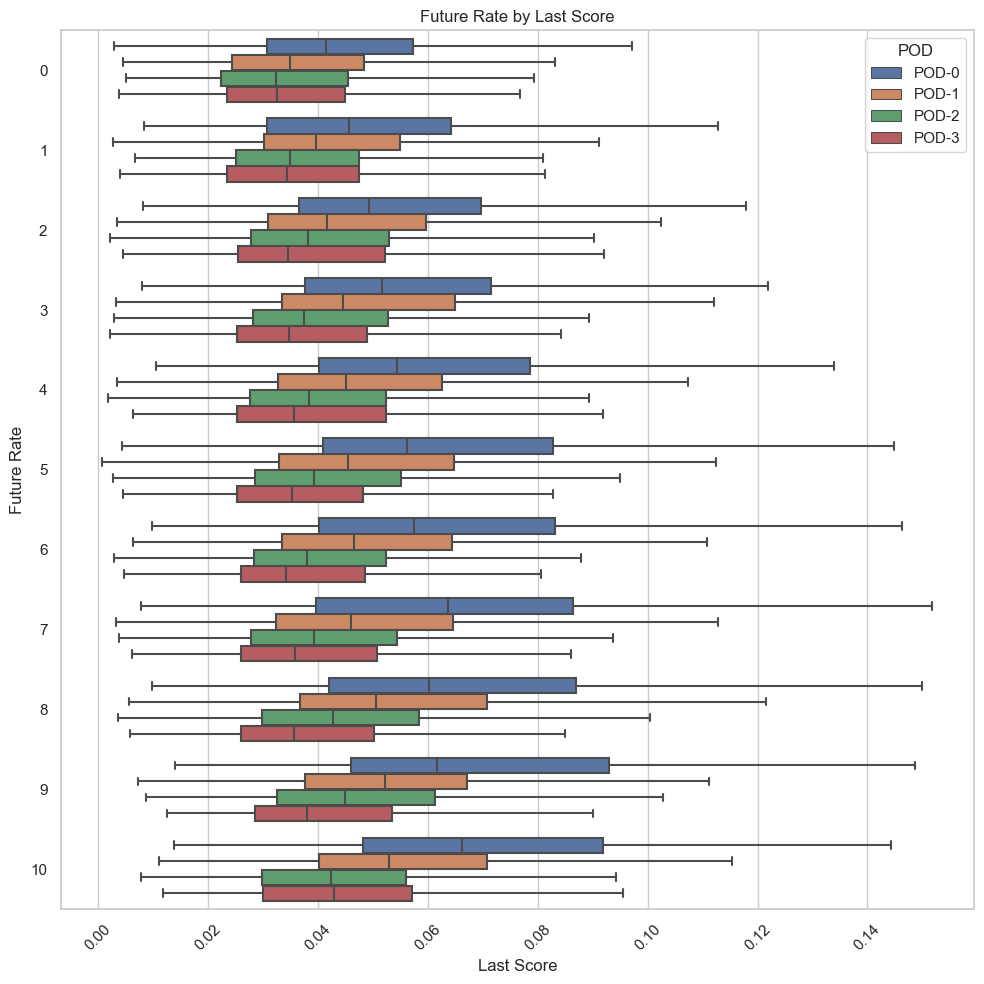

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.boxplot(data=df, y='LAST_SCORE', x='FUTURE_RATE',hue='POD', showfliers=False)
plt.title('Future Rate by Last Score')
plt.xlabel('Last Score')
plt.ylabel('Future Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


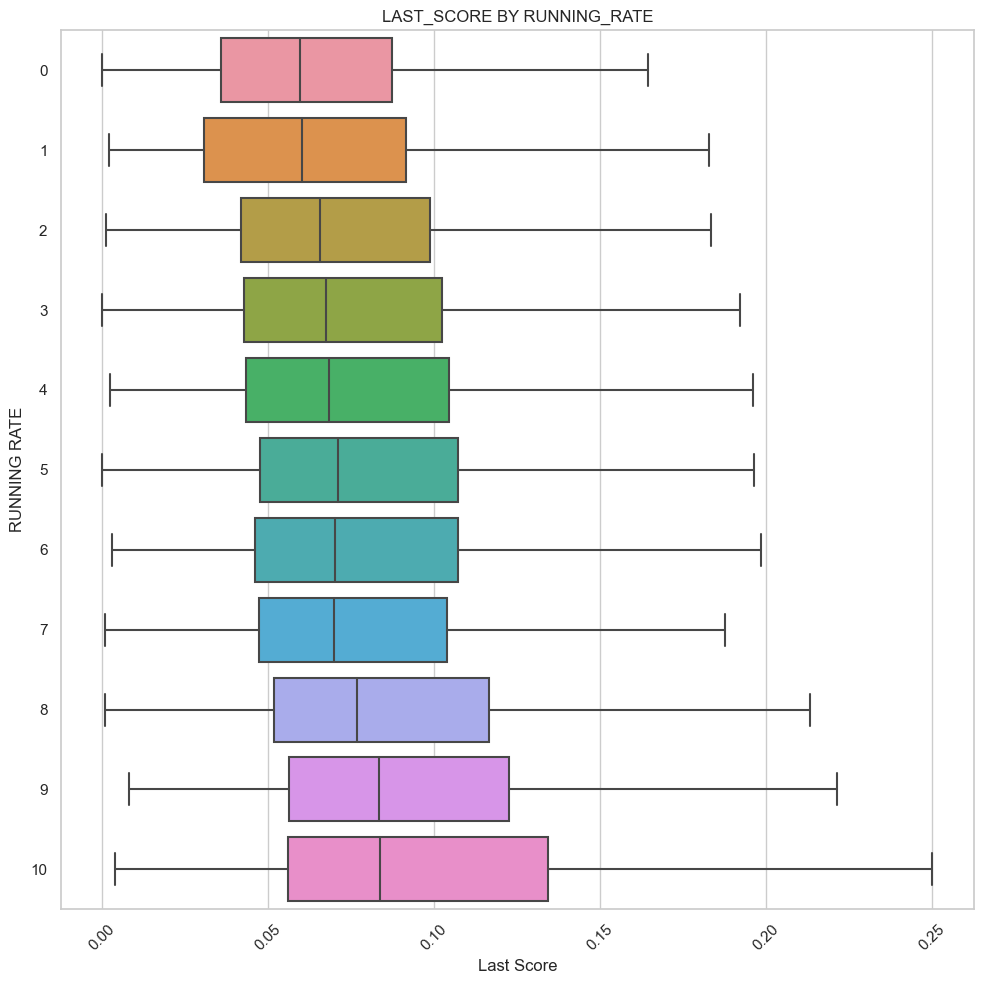

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.boxplot(data=df, y='LAST_SCORE', x='RUNNING_RATE', showfliers=False)
plt.title('LAST_SCORE BY RUNNING_RATE')
plt.xlabel('Last Score')
plt.ylabel('RUNNING RATE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           38806 non-null  int64   
 1   POH           38806 non-null  float64 
 2   FUTURE_RATE   38806 non-null  float64 
 3   LAST_SCORE    38806 non-null  category
 4   LAST_GRADE    38806 non-null  category
 5   RUNNING_RATE  38806 non-null  float64 
 6   GROUP         38806 non-null  object  
 7   TYPE          38806 non-null  object  
 8   YEAR          38806 non-null  int64   
 9   FAC           38806 non-null  object  
 10  SEX           38806 non-null  object  
 11  RACE          38806 non-null  object  
 12  AGE           38806 non-null  float64 
 13  BMI           38806 non-null  float64 
 14  HW            38806 non-null  float64 
 15  ASA           38806 non-null  int64   
 16  DSCPOH        38806 non-null  float64 
 17  POH_int       38806 non-null  int32   
 18  POD   

In [12]:
# Avoid divide-by-zero
df['RATE_RATIO'] = df.apply(
    lambda row: row['FUTURE_RATE'] / row['RUNNING_RATE'] if row['RUNNING_RATE'] != 0 else None,
    axis=1
)

# Boolean inflection flag
df['RATE_INFLECT'] = df['FUTURE_RATE'] > df['RUNNING_RATE']


In [13]:
import seaborn as sns

# Get sorted unique scores
scores = sorted(df['LAST_SCORE'].unique())

# Create a gradient palette from Reds or Blues
palette = sns.color_palette("Reds", n_colors=len(scores))  # or "Blues"
score_colors = dict(zip(scores, palette))


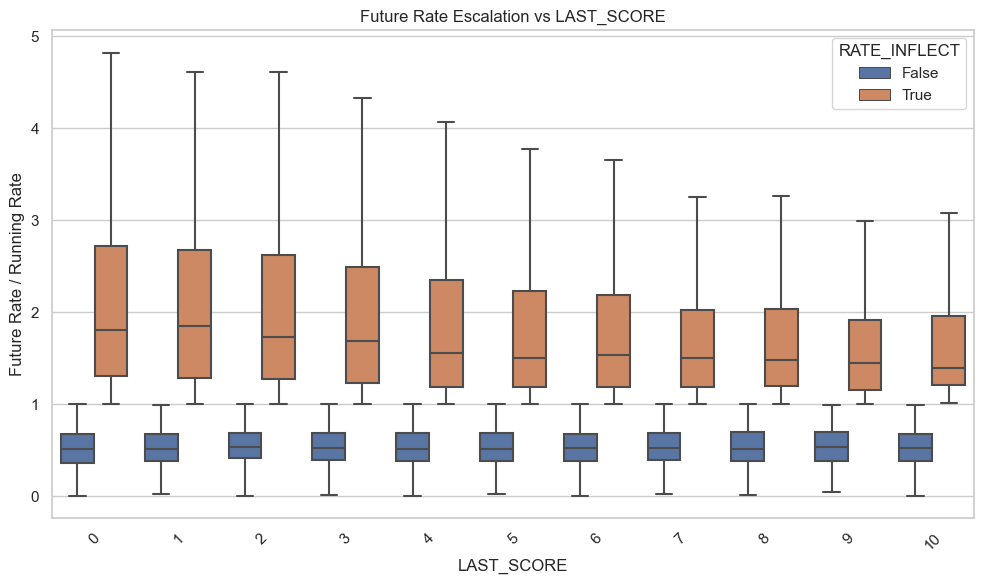

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='LAST_SCORE', y='RATE_RATIO',hue = 'RATE_INFLECT', showfliers=False)
plt.title('Future Rate Escalation vs LAST_SCORE')
plt.xlabel('LAST_SCORE')
plt.ylabel('Future Rate / Running Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


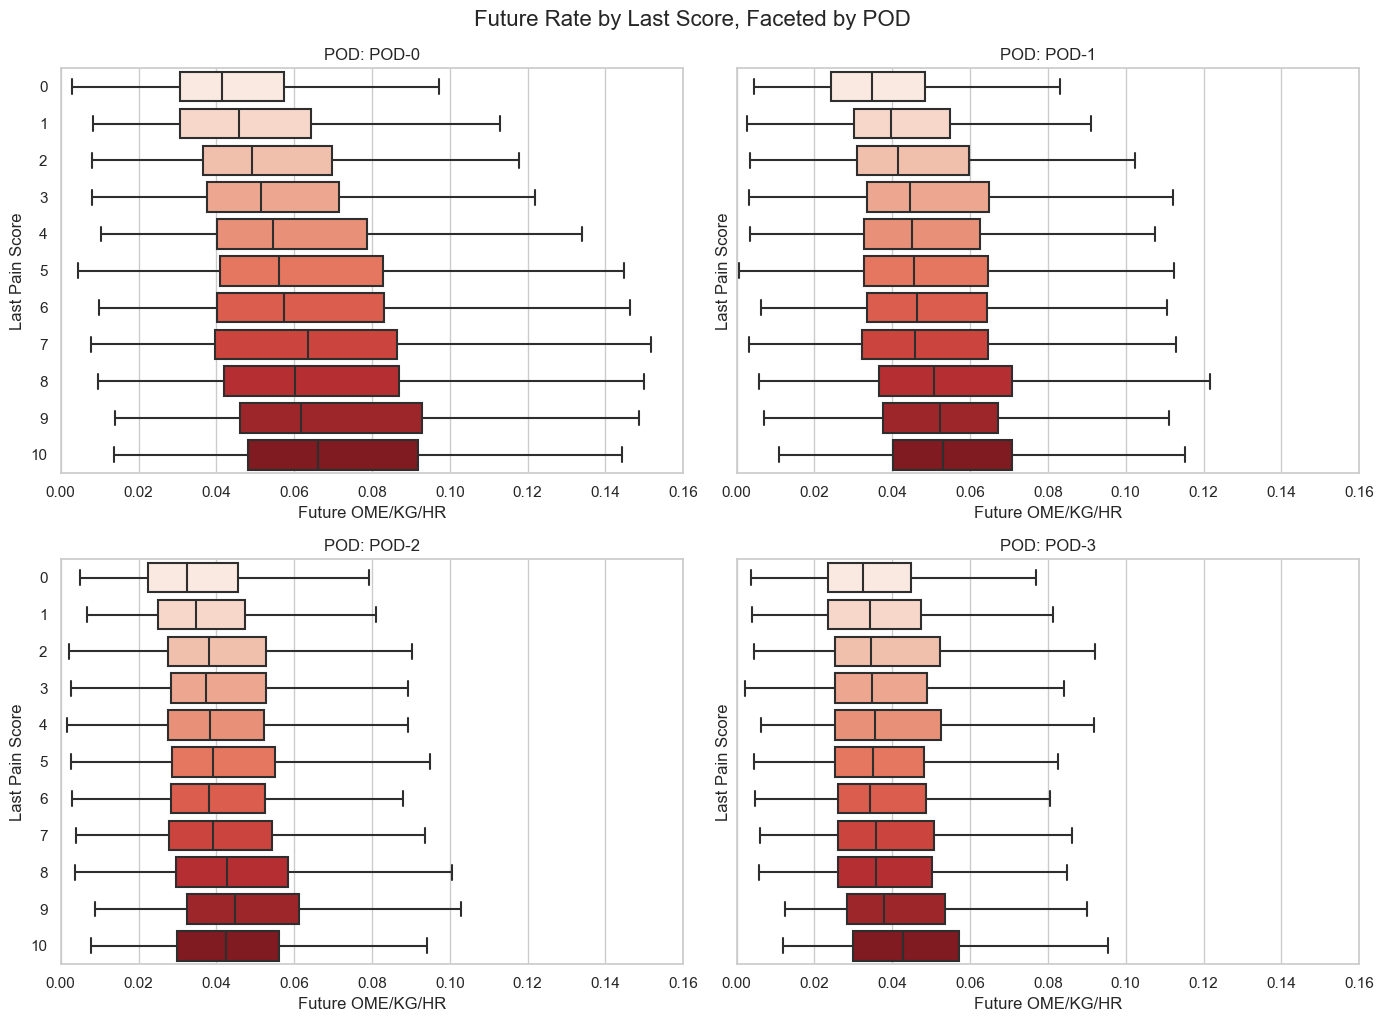

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique POD values
pods = df['POD'].unique()
n_pods = len(pods)

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

# Plot each POD
for i, pod in enumerate(pods):
    sns.boxplot(
        data=df[df['POD'] == pod],
        x='FUTURE_RATE',
        y='LAST_SCORE',
        showfliers=False,
        palette=score_colors,
        ax=axes[i]
    )
    axes[i].set_title(f'POD: {pod}')
    axes[i].set_xlabel('Future OME/KG/HR')
    axes[i].set_ylabel('Last Pain Score')
    axes[i].set_xlim(0, 0.16)

# Hide unused subplots if fewer than 4 PODs
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Future Rate by Last Score, Faceted by POD', fontsize=16, y=1.02)
plt.show()



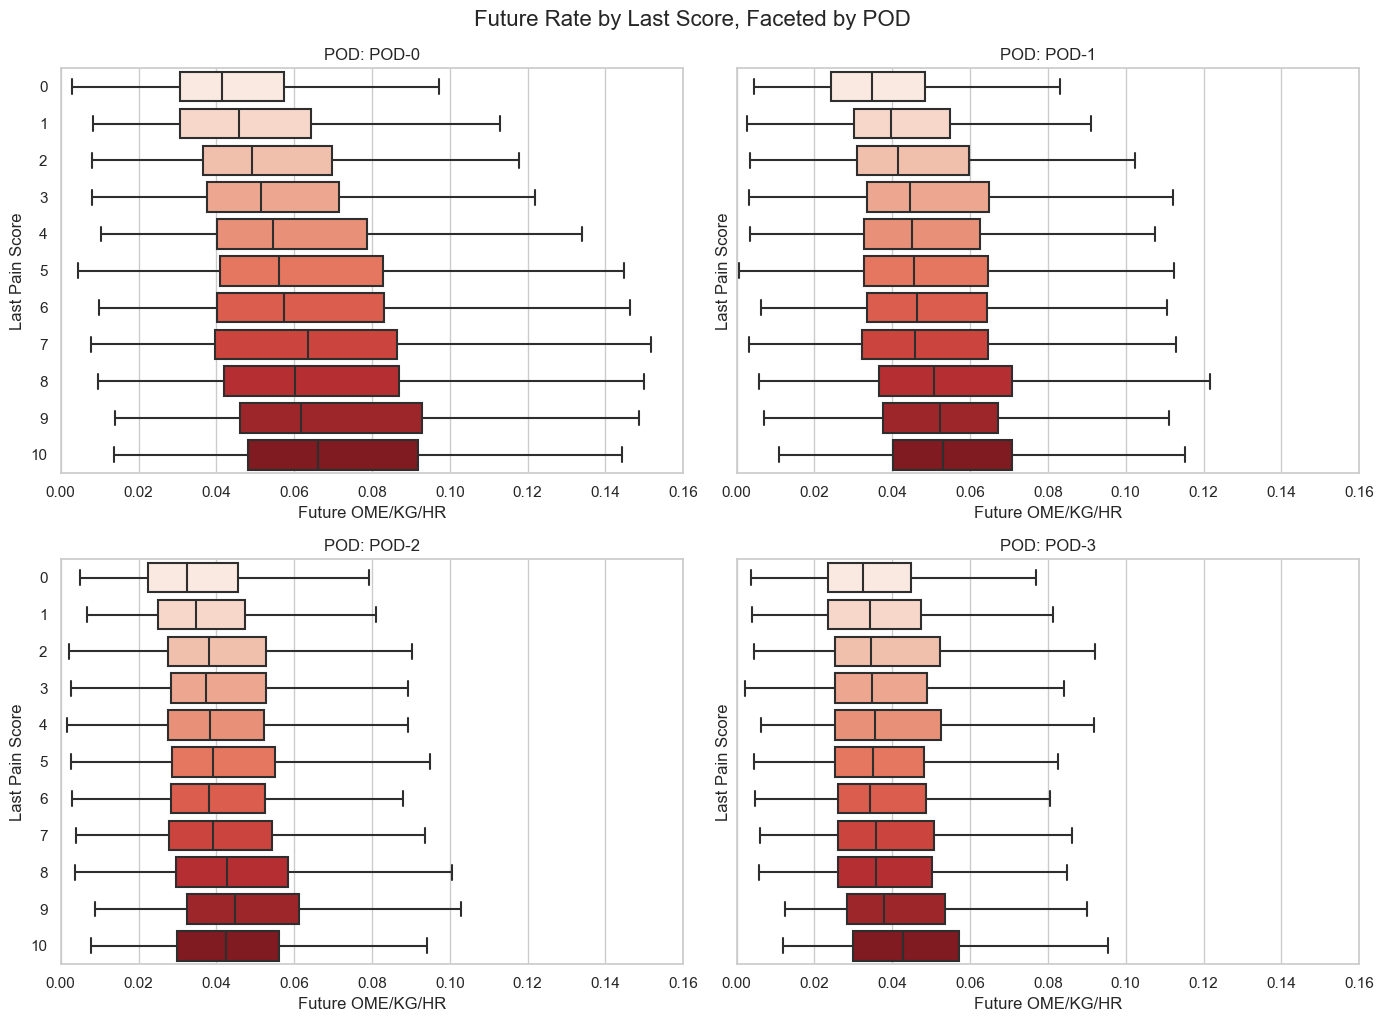

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique POD values
pods = df['POD'].unique()
n_pods = len(pods)

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

# Plot each POD
for i, pod in enumerate(pods):
    sns.boxplot(
        data=df[df['POD'] == pod],
        x='FUTURE_RATE',
        y='LAST_SCORE',
        showfliers=False,
        palette=score_colors,
        ax=axes[i]
    )
    axes[i].set_title(f'POD: {pod}')
    axes[i].set_xlabel('Future OME/KG/HR')
    axes[i].set_ylabel('Last Pain Score')
    axes[i].set_xlim(0, 0.16)

# Hide unused subplots if fewer than 4 PODs
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Future Rate by Last Score, Faceted by POD', fontsize=16, y=1.02)
plt.show()



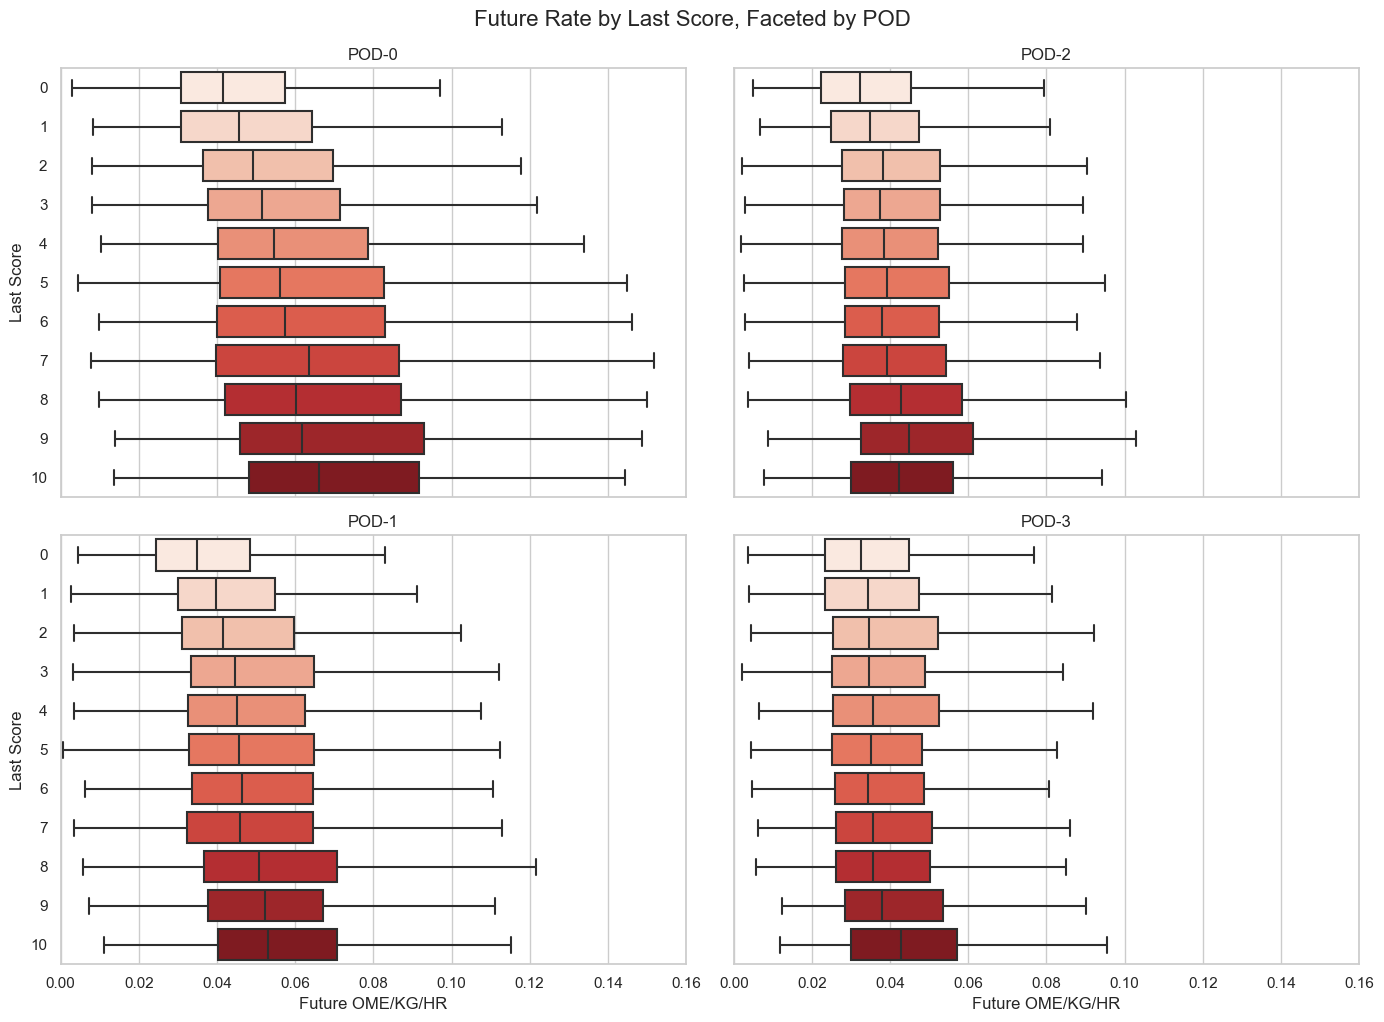

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort PODs and Last Scores
pods = sorted(df['POD'].unique())
scores = sorted(df['Last Score'].unique())

# Create gradient palette for Last Score
palette = sns.color_palette("Reds", n_colors=len(scores))
score_colors = dict(zip(scores, palette))

# Map PODs to column-first layout
layout = {
    0: (0, 0),  # POD-0
    1: (1, 0),  # POD-1
    2: (0, 1),  # POD-2
    3: (1, 1)   # POD-3
}

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# Plot each POD
for i, pod in enumerate(pods):
    r, c = layout[i]
    ax = axes[r][c]
    
    sns.boxplot(
        data=df[df['POD'] == pod],
        x='Future Rate',
        y='Last Score',
        showfliers=False,
        palette=score_colors,
        ax=ax
    )
    
    ax.set_title(f'{pod}')
    ax.set_xlim(0, 0.16)
    
    # Suppress y-axis in column 2
    if c == 1:
        ax.set_ylabel('')
        ax.tick_params(axis='y', left=False, labelleft=False)
    
    # Suppress x-ticks in row 1
    if r == 0:
        ax.set_xlabel('')
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
    else:
        ax.set_xlabel('Future OME/KG/HR')

plt.tight_layout()
plt.suptitle('Future Rate by Last Score, Faceted by POD', fontsize=16, y=1.02)
plt.show()


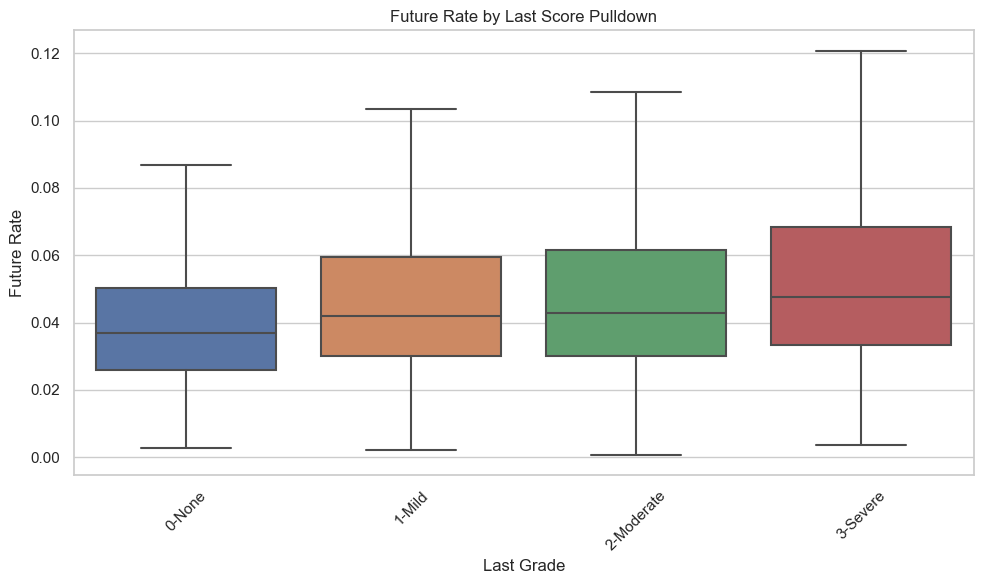

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Last Grade Pulldown', y='Future Rate',showfliers=False)
plt.title('Future Rate by Last Score Pulldown')
plt.xlabel('Last Grade')
plt.ylabel('Future Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


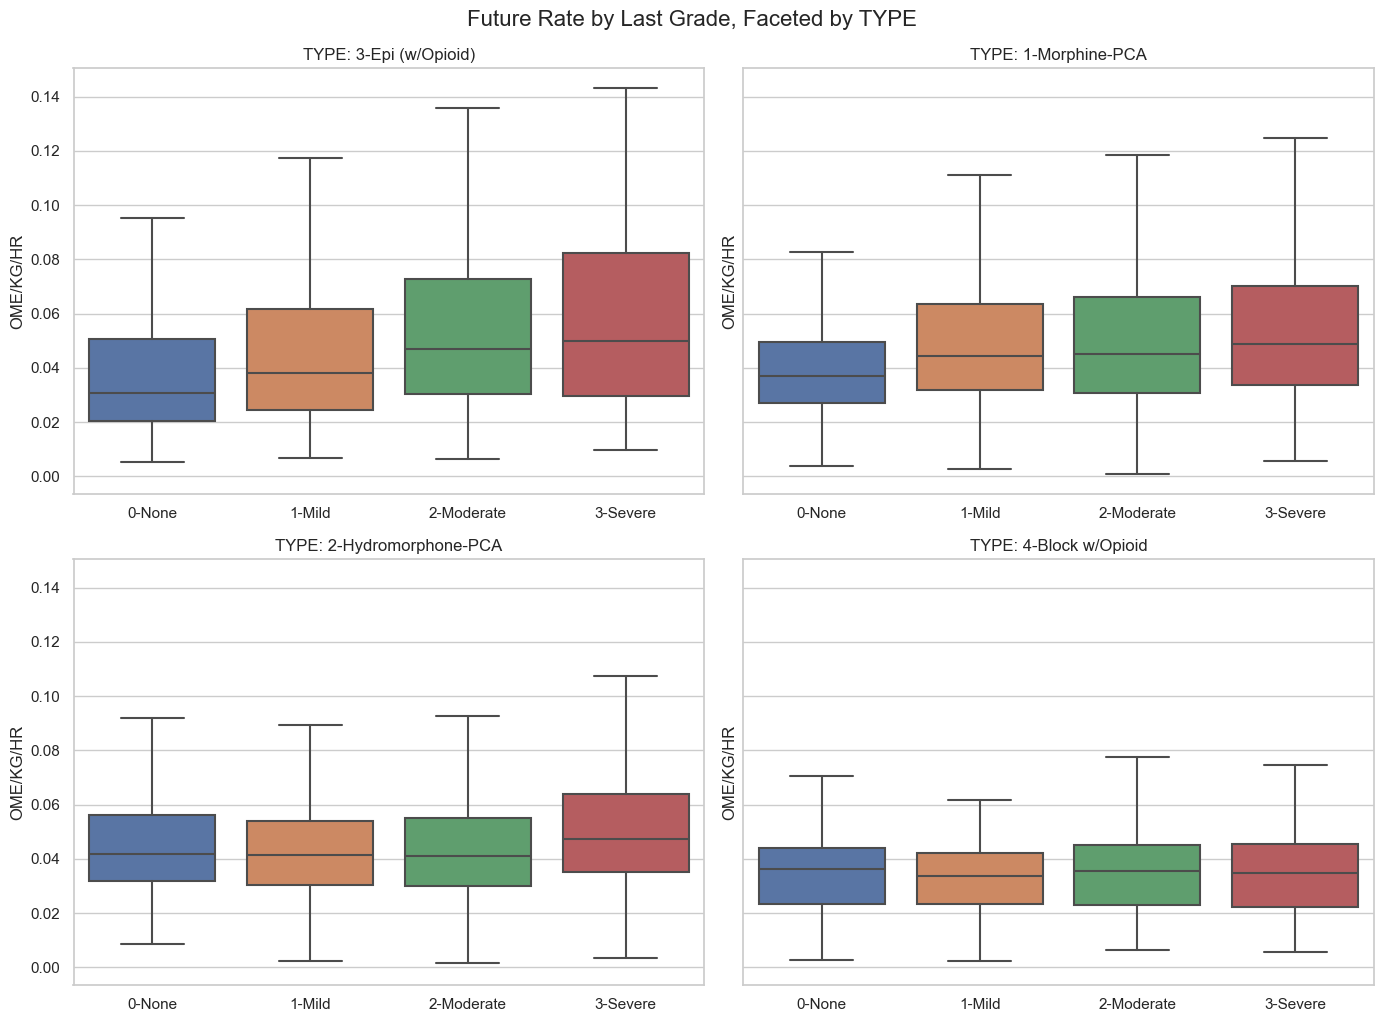

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the four unique TYPEs
types = df['TYPE'].unique()[:4]  # Adjust if more than 4

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

# Plot each TYPE
for i, t in enumerate(types):
    sns.boxplot(
        data=df[df['TYPE'] == t],
        x='Last Grade Pulldown',
        y='Future Rate',
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(f'TYPE: {t}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('OME/KG/HR')

plt.tight_layout()
plt.suptitle('Future Rate by Last Grade, Faceted by TYPE', fontsize=16, y=1.02)
plt.show()


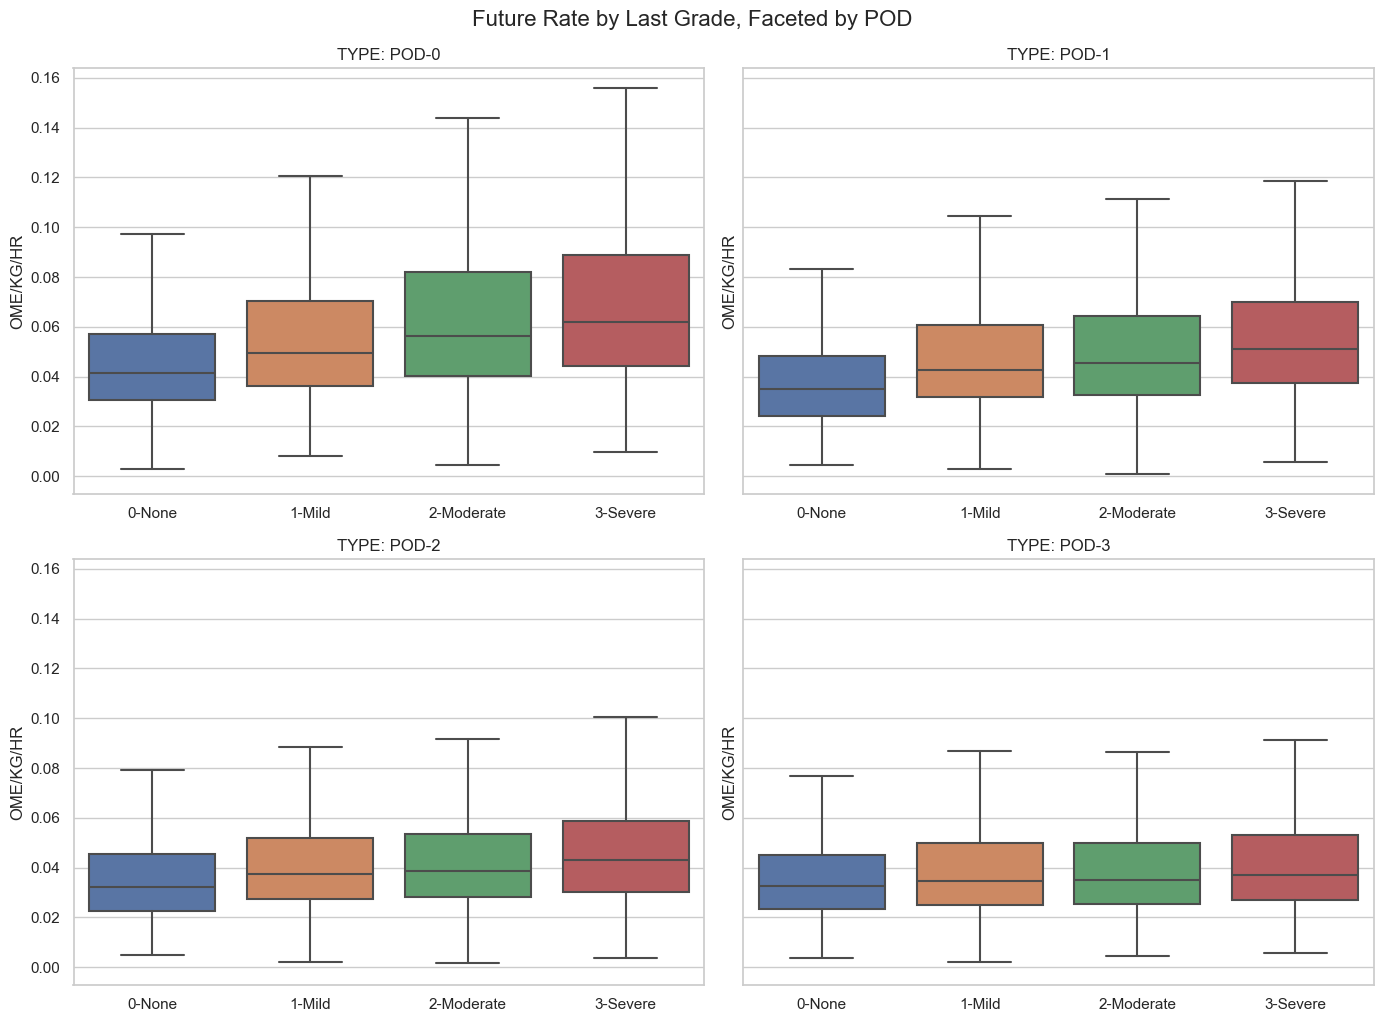

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the four unique TYPEs
types = df['POD'].unique()[:4]  # Adjust if more than 4

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

# Plot each TYPE
for i, t in enumerate(types):
    sns.boxplot(
        data=df[df['POD'] == t],
        x='Last Grade Pulldown',
        y='Future Rate',
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(f'TYPE: {t}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('OME/KG/HR')

plt.tight_layout()
plt.suptitle('Future Rate by Last Grade, Faceted by POD', fontsize=16, y=1.02)
plt.show()


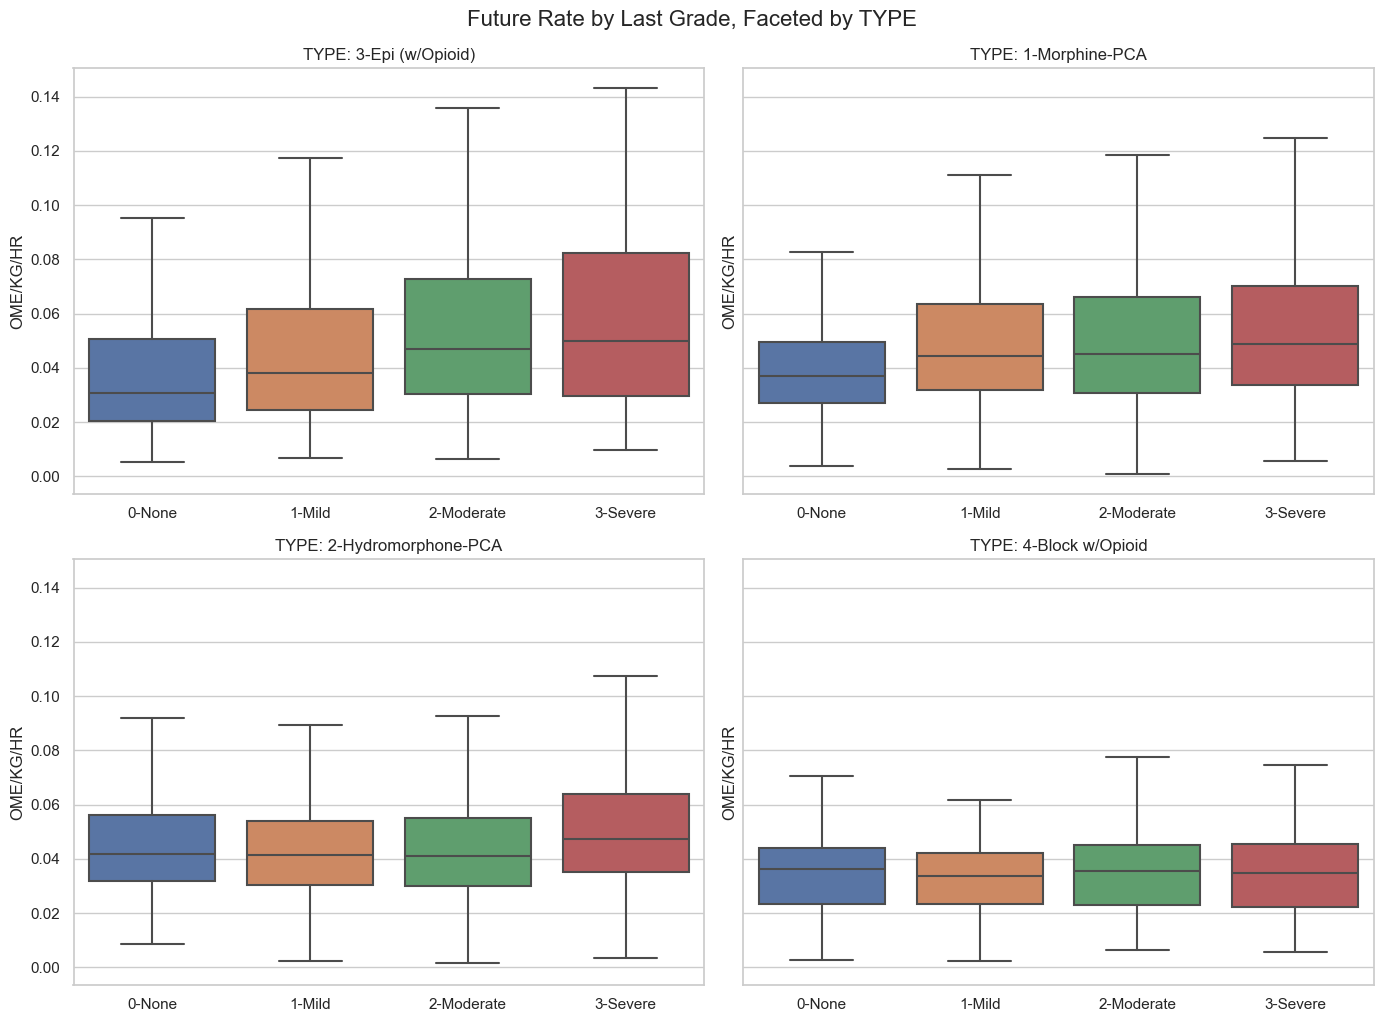

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the four unique TYPEs
types = df['TYPE'].unique()[:4]  # Adjust if more than 4

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

# Plot each TYPE
for i, t in enumerate(types):
    sns.boxplot(
        data=df[df['TYPE'] == t],
        x='Last Grade Pulldown',
        y='Future Rate',
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(f'TYPE: {t}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('OME/KG/HR')

plt.tight_layout()
plt.suptitle('Future Rate by Last Grade, Faceted by TYPE', fontsize=16, y=1.02)
plt.show()


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           38806 non-null  int64   
 1   POH           38806 non-null  float64 
 2   FUTURE_RATE   38806 non-null  float64 
 3   LAST_SCORE    38806 non-null  category
 4   LAST_GRADE    38806 non-null  category
 5   RUNNING_RATE  38806 non-null  float64 
 6   GROUP         38806 non-null  object  
 7   TYPE          38806 non-null  object  
 8   YEAR          38806 non-null  int64   
 9   FAC           38806 non-null  object  
 10  SEX           38806 non-null  object  
 11  RACE          38806 non-null  object  
 12  AGE           38806 non-null  float64 
 13  BMI           38806 non-null  float64 
 14  HW            38806 non-null  float64 
 15  ASA           38806 non-null  int64   
 16  DSCPOH        38806 non-null  float64 
 17  POH_int       38806 non-null  int32   
 18  POD   

In [16]:
df['FAC'].value_counts()

FAC
SPOKANE            5956
SHREVEPORT         5635
GREENVILLE         5524
ST. LOUIS          4096
PHILADELPHIA       3571
PORTLAND           3490
CHICAGO            3001
TAMPA              2731
SPRINGFIELD        1549
LEXINGTON          1329
NORTHERN CALIFO     892
HOUSTON             729
HONOLULU            303
Name: count, dtype: int64

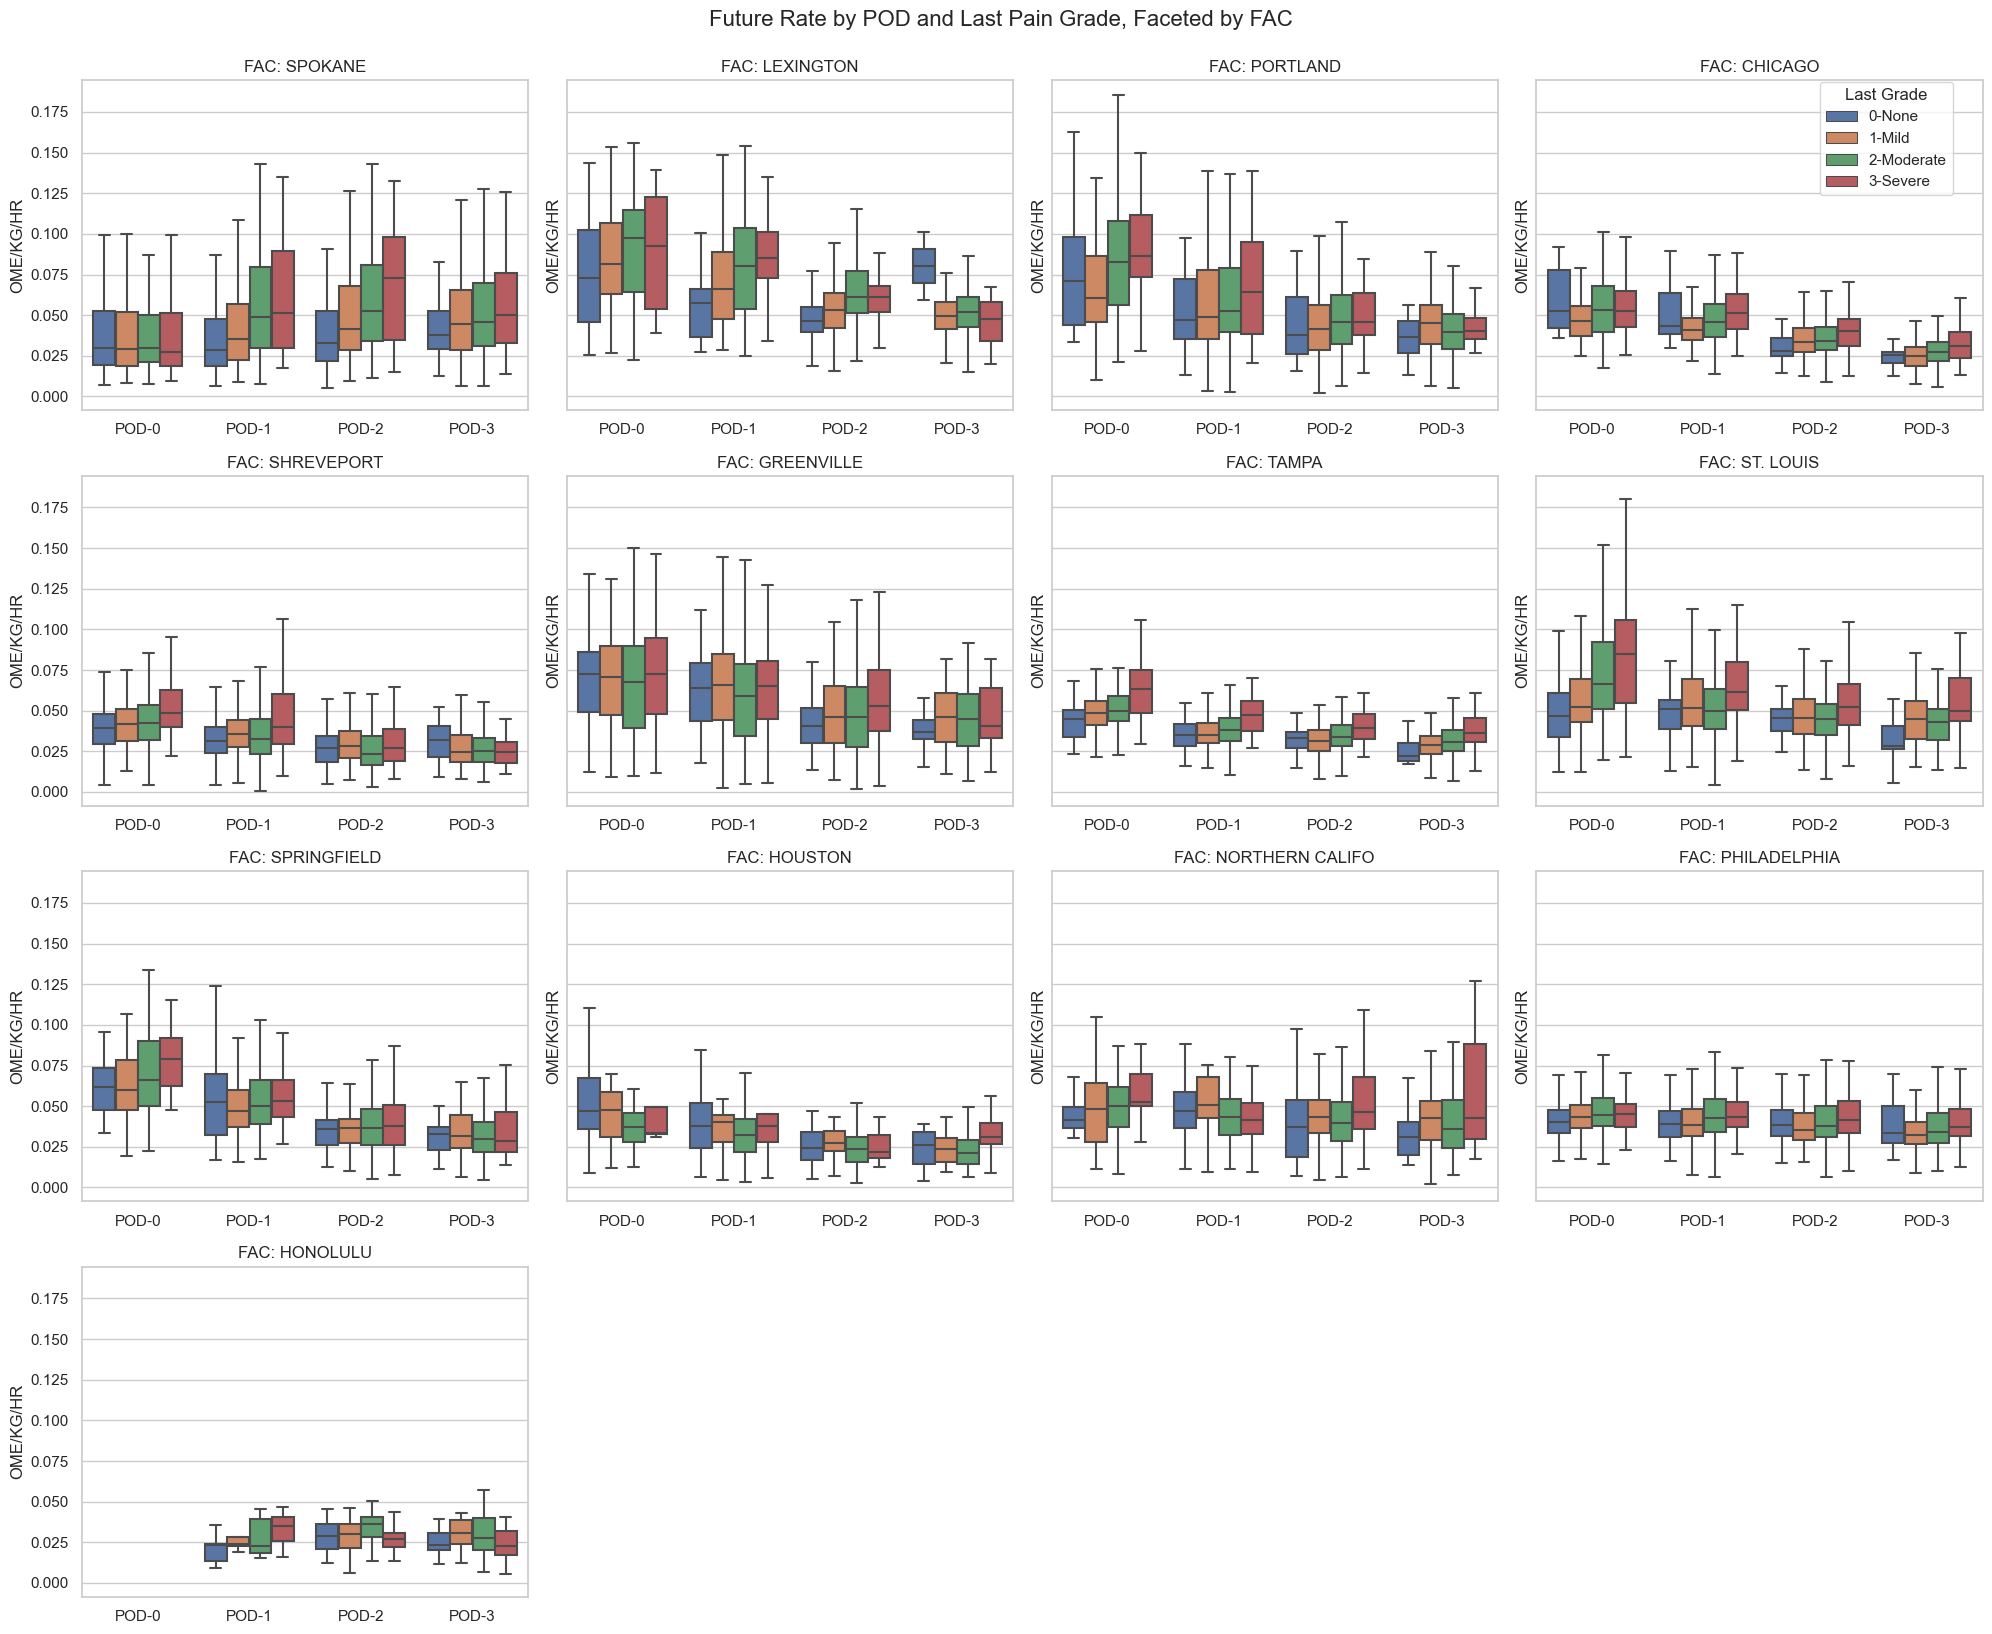

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get all unique FAC values
facilities = df['FAC'].unique()
n_fac = len(facilities)

# Determine subplot grid size
n_cols = 4
n_rows = (n_fac + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharey=True)
axes = axes.flatten()

# Store legend handles and labels from one plot
legend_handles, legend_labels = None, None

# Plot each FAC
for i, fac in enumerate(facilities):
    ax = axes[i]
    plot = sns.boxplot(
        data=df[df['FAC'] == fac],
        x='POD',
        y='FUTURE_RATE',
        showfliers=False,
        hue='LAST_GRADE',
        ax=ax
    )
    ax.set_title(f'FAC: {fac}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR')

    # Capture legend from first plot
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove legend from all subplots
    ax.legend_.remove()

# Hide unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add legend to upper right of figure
# Add legend to upper right inside the figure
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='Last Grade',
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98)  # Adjust this to fine-tune position
)



plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade, Faceted by FAC', fontsize=16, y=1.02)
plt.show()


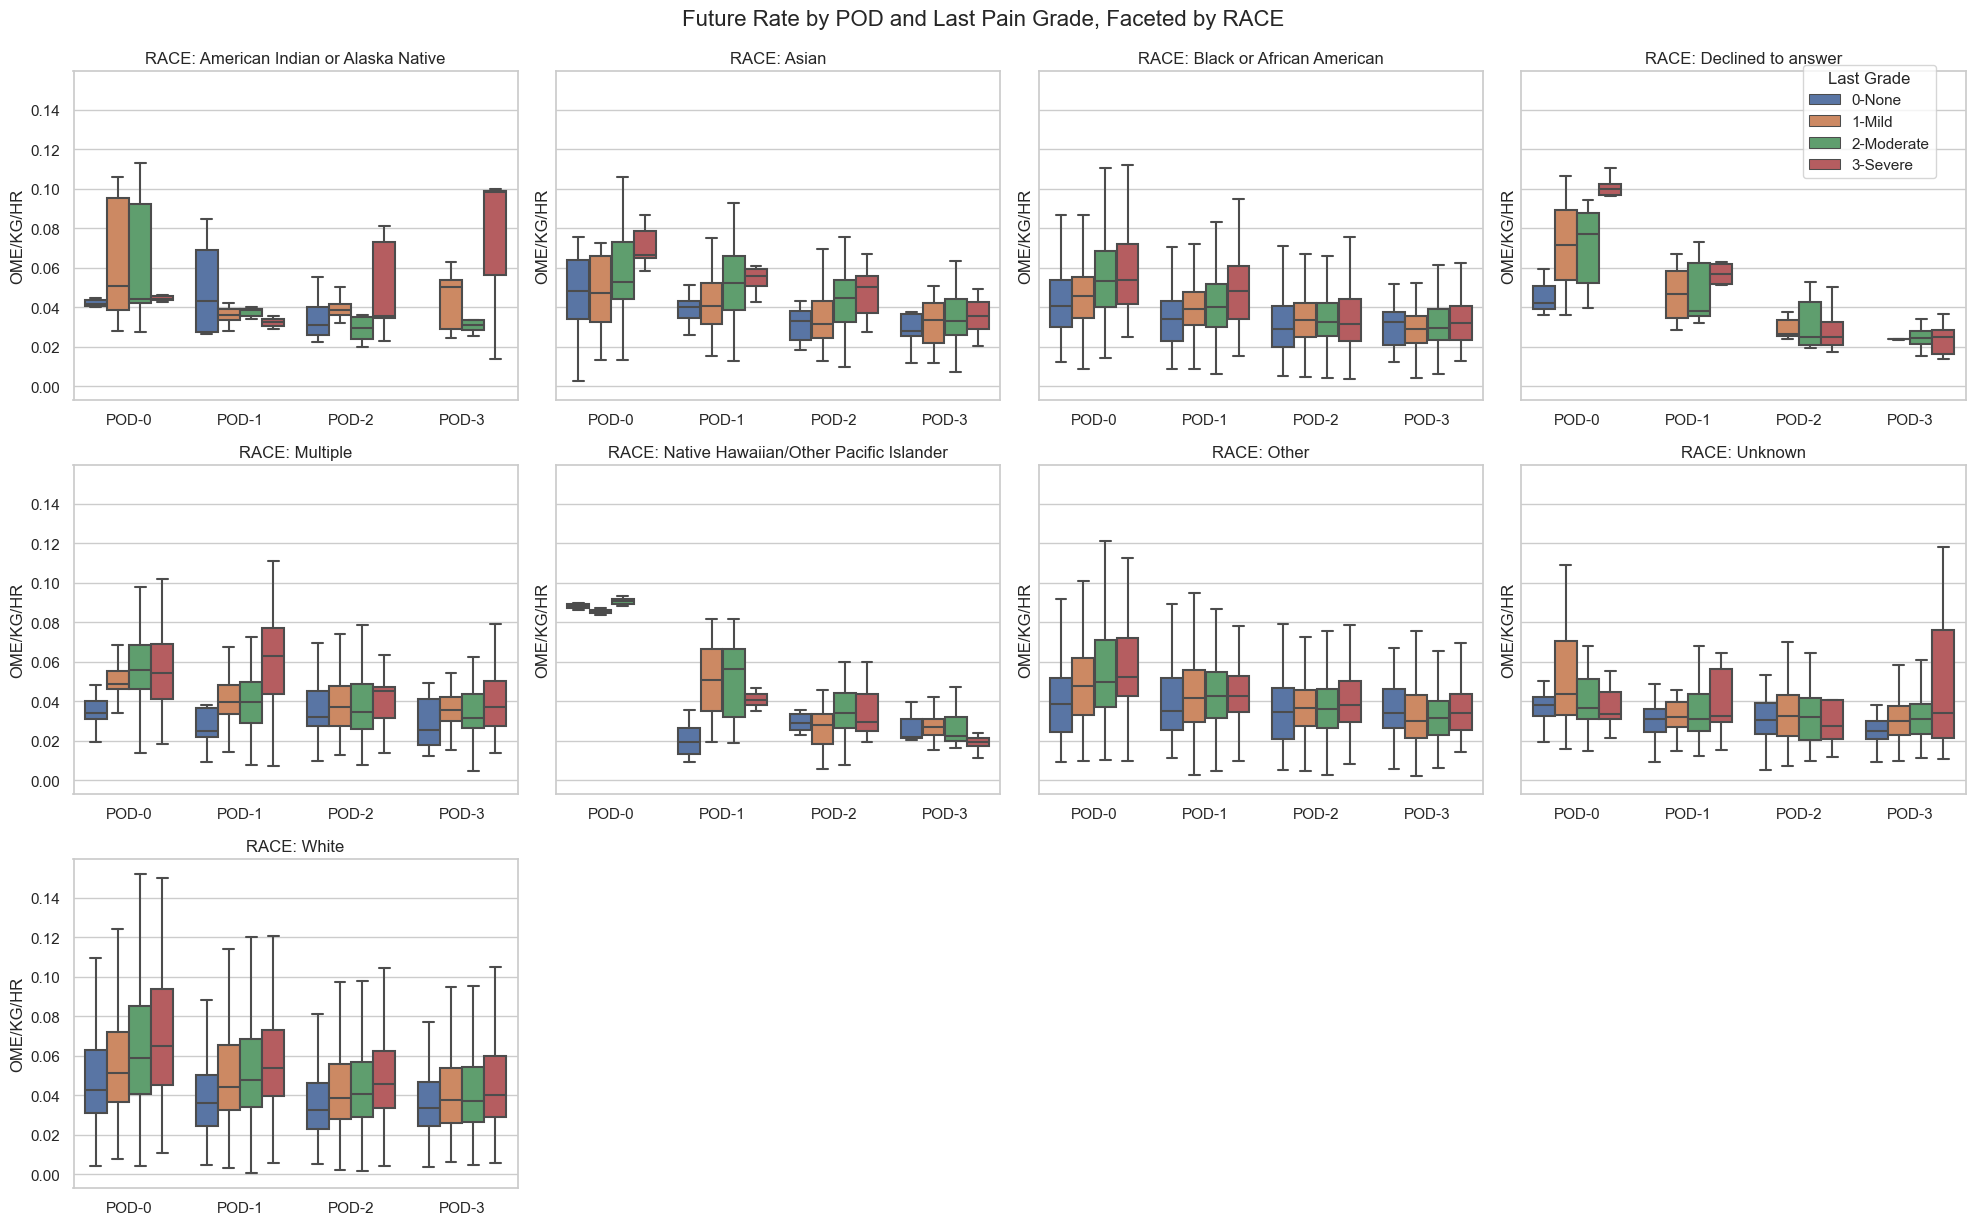

In [32]:

import seaborn as sns
import matplotlib.pyplot as plt

# Ensure RACE exists and is not all missing
if 'RACE' not in df.columns or df['RACE'].dropna().empty:
    raise ValueError("Column 'RACE' is missing or empty.")

# Get all unique RACE values (sorted for reproducibility)
races = sorted(df['RACE'].dropna().unique())
n_race = len(races)

# Determine subplot grid size
n_cols = 4
n_rows = (n_race + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharey=True)
axes = axes.flatten()

# Store legend handles and labels from one plot
legend_handles, legend_labels = None, None

# Plot each RACE
for i, race in enumerate(races):
    ax = axes[i]
    plot = sns.boxplot(
        data=df[df['RACE'] == race],
        x='POD',
        y='FUTURE_RATE',
        showfliers=False,
        hue='LAST_GRADE',
        ax=ax
    )
    ax.set_title(f'RACE: {race}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR')

    # Capture legend from first subplot that has a legend
    if legend_handles is None:
        h, l = ax.get_legend_handles_labels()
        if h and l:
            legend_handles, legend_labels = h, l

    # Remove legend from this subplot (guard if legend exists)
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a single legend to the figure (only if we captured handles)
if legend_handles and legend_labels:
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        title='Last Grade',
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98)
    )

plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade, Faceted by RACE', fontsize=16, y=1.02)
plt.show()


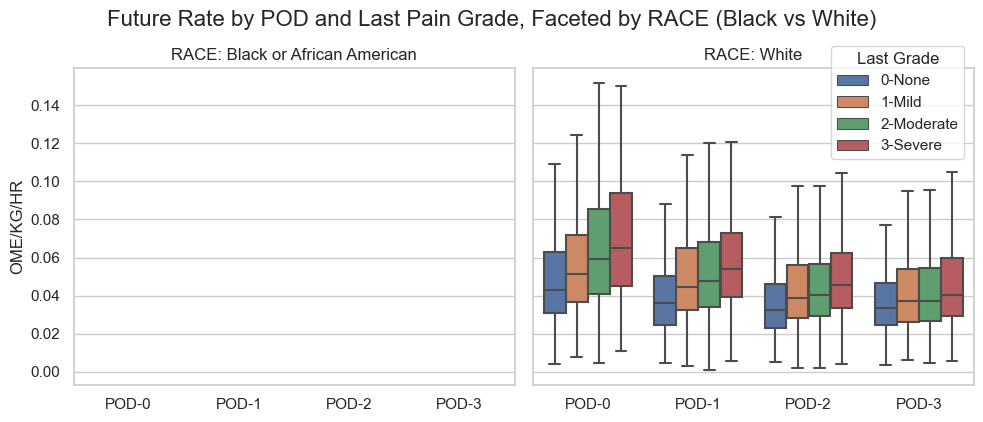

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Filter to just Black and White (robust to case/whitespace) ---
# Normalize a copy to avoid mutating your original df
df2 = df.copy()
df2['RACE'] = df2['RACE'].astype(str).str.strip().str.title()  # e.g., 'black' -> 'Black'
df_bw = df2[df2['RACE'].isin(['Black or African American', 'White'])].copy()

# Optional: ensure consistent order: [Black, White]
race_order = ['Black or African American', 'White']

# Fixed 1x2 grid
n_cols = 2
n_rows = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharey=True)

legend_handles, legend_labels = None, None

for i, race in enumerate(race_order):
    ax = axes[i]
    sns.boxplot(
        data=df_bw[df_bw['RACE'] == race],
        x='POD',
        y='FUTURE_RATE',
        hue='LAST_GRADE',
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'RACE: {race}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR' if i == 0 else '')  # y-label on left plot only for cleanliness

    # Capture legend from first subplot that has one
    if legend_handles is None:
        h, l = ax.get_legend_handles_labels()
        if h and l:
            legend_handles, legend_labels = h, l

    # Remove per-axis legend
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Add single figure-level legend (if captured)
if legend_handles and legend_labels:
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        title='Last Grade',
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98)
    )

plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade, Faceted by RACE (Black vs White)', fontsize=16, y=1.05)
plt.show()



In [29]:
df['RACE'].value_counts()

RACE
White                                     28753
Black or African American                  4313
Other                                      3345
Multiple                                    786
Unknown                                     780
Asian                                       472
Native Hawaiian/Other Pacific Islander      134
American Indian or Alaska Native            124
Declined to answer                           99
Name: count, dtype: int64

In [18]:

import pandas as pd

# Work on a copy to avoid mutating df
df2 = df.copy()

# Normalize strings
df2['RACE'] = (
    df2['RACE']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# Create a simplified race column
race_map = {
    'White': 'White',
    'Black or African American': 'Black',
}

df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# (Optional) sanity check counts
print(df2['RACE_SIMPLE'].value_counts())


RACE_SIMPLE
White            28753
Other/Unknown     5740
Black             4313
Name: count, dtype: int64


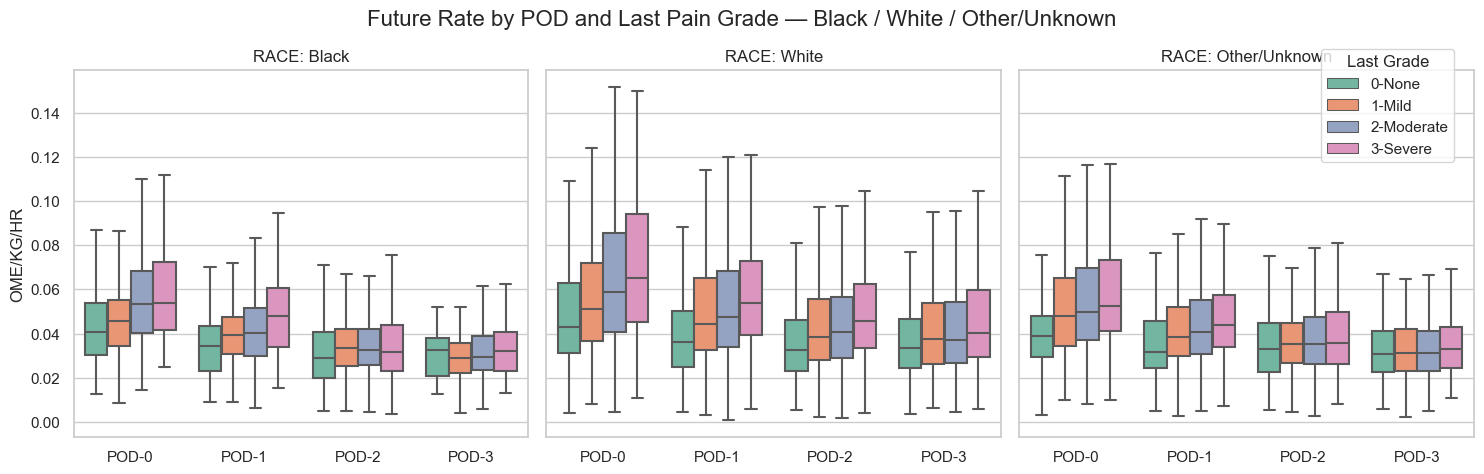

In [20]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) Recode RACE to three simplified labels ---
df2 = df.copy()
df2['RACE'] = (
    df2['RACE'].astype(str)
               .str.strip()
               .str.replace(r'\s+', ' ', regex=True)
)

race_map = {
    'White': 'White',
    'Black or African American': 'Black',
}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# --- 2) Normalize LAST_GRADE labels (strip whitespace) ---
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()

# (Optional) If your grades come in prefixed form (e.g., "1-Mild", "2-Moderate", "0-None"),
# you can standardize them with a mapping. Uncomment and adjust if helpful:
# grade_map = {
#     '0-None': 'None', 'None': 'None',
#     '1-Mild': 'Mild', 'Mild': 'Mild',
#     '2-Moderate': 'Moderate', 'Moderate': 'Moderate',
#     '3-Severe': 'Severe', 'Severe': 'Severe'
# }
# df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# --- 3) Build a palette from the actual hue levels present ---
# Limit to the three facet groups to ensure palette matches what you'll plot
mask = df2['RACE_SIMPLE'].isin(['Black', 'White', 'Other/Unknown'])
grade_levels = sorted(df2.loc[mask, 'LAST_GRADE'].dropna().unique())

# Create distinct colors (Set2 is nice for categorical)
colors = sns.color_palette('Set2', n_colors=len(grade_levels))
palette = dict(zip(grade_levels, colors))

# Fix a consistent hue order across all panels for repeatability
hue_order = grade_levels

# --- 4) Plot 1 × 3 grid with shared legend ---
race_order = ['Black', 'White', 'Other/Unknown']  # left → right order
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

legend_handles, legend_labels = None, None

for i, race in enumerate(race_order):
    ax = axes[i]
    sns.boxplot(
        data=df2[df2['RACE_SIMPLE'] == race],
        x='POD',
        y='FUTURE_RATE',
        hue='LAST_GRADE',
        hue_order=hue_order,
        showfliers=False,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'RACE: {race}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR' if i == 0 else '')

    # Capture legend once
    h, l = ax.get_legend_handles_labels()
    if legend_handles is None and h and l:
        legend_handles, legend_labels = h, l

    # Remove axis-level legend to avoid duplicates
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Figure-level legend
if legend_handles and legend_labels:
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        title='Last Grade',
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98)
    )

plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade — Black / White / Other/Unknown', fontsize=16, y=1.05)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\2819338036.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


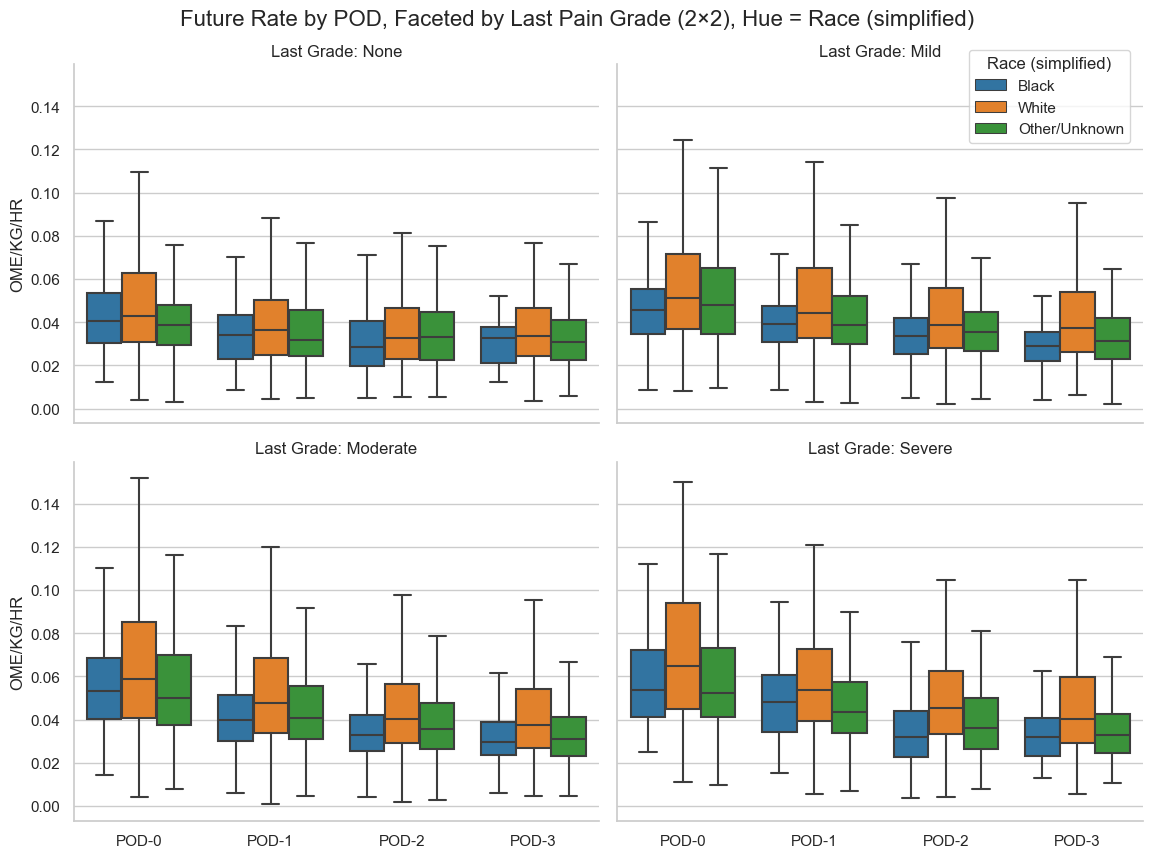

In [21]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prep ---
df2 = df.copy()

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {
    'White': 'White',
    'Black or African American': 'Black',
}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE (strip whitespace; optionally map "0-None" -> "None")
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None',
    '1-Mild': 'Mild',
    '2-Moderate': 'Moderate',
    '3-Severe': 'Severe',
    # If your labels are already clean, this mapping will just pass-through
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Define panel order (ensures a neat 2x2 grid in severity order)
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]

# Define hue order (consistent across all facets)
race_order = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette for RACE_SIMPLE (distinct, colorblind-friendly)
race_palette = {
    'Black': '#1f77b4',          # blue
    'White': '#ff7f0e',          # orange
    'Other/Unknown': '#2ca02c'   # green
}

# Optional: order POD if categorical (keeps x-axis consistent)
# Example if POD values are 'POD0', 'POD1', 'POD2', ...
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
# OR if POD is numeric days:
# order_pod = sorted(df2['POD'].unique())
order_pod = None  # set to a list if you want explicit ordering

# --- Plot with catplot (kind='box') ---
g = sns.catplot(
    data=df2,
    x='POD',
    y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE',
    col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,           # -> 2 columns; with up to 4 grades gives a 2x2
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod       # pass if you set order_pod above
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template="Last Grade: {col_name}")

# Legend formatting (keeps figure-level legend outside by default)
if g._legend is not None:
    g._legend.set_title('Race (simplified)')

# If you prefer the legend inside the figure in the top-right:
handles, labels = g.axes[0].get_legend_handles_labels()
g._legend.remove()
g.fig.legend(handles, labels, title='Race (simplified)', loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
g.fig.suptitle('Future Rate by POD, Faceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


In [54]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   GEO_ID       8155 non-null   object
 1   B19013_E001  8155 non-null   object
 2   B19013_M001  8155 non-null   object
dtypes: object(3)
memory usage: 191.3+ KB


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\1175037565.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


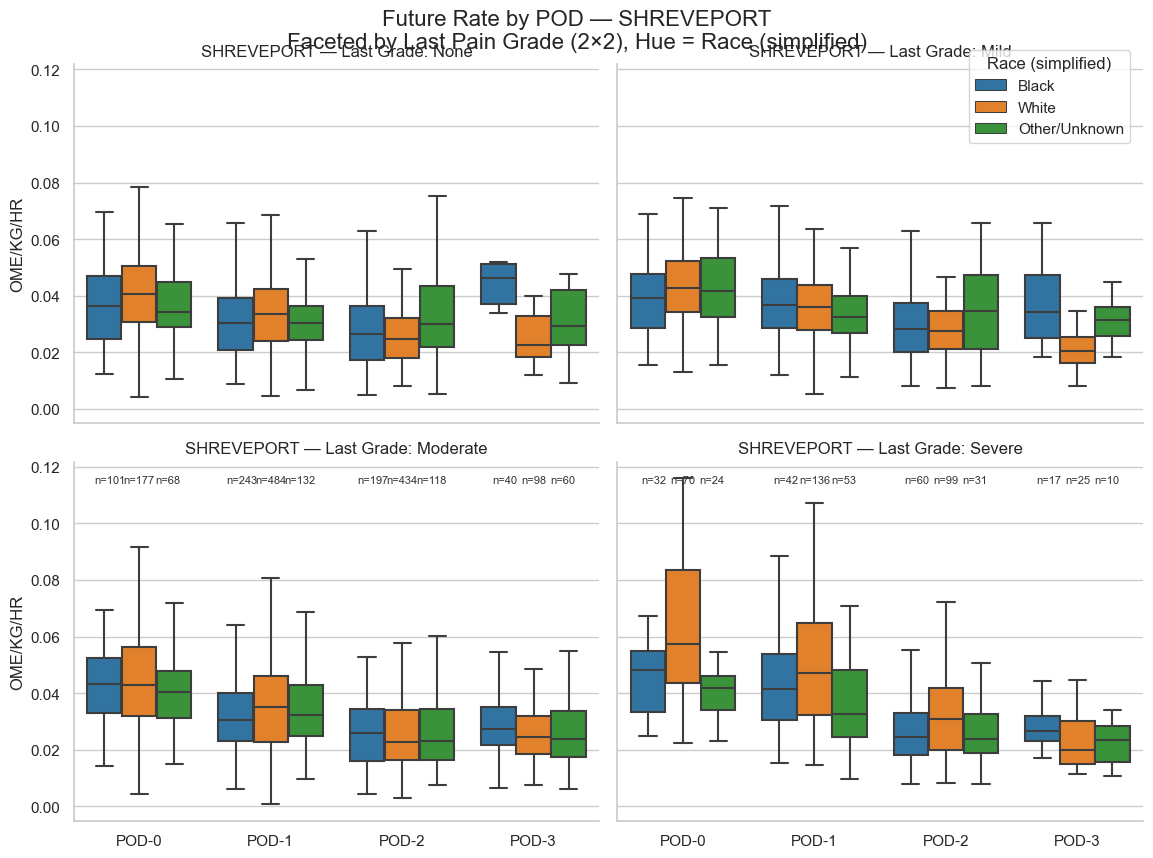

In [22]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SITE = "SHREVEPORT"

# --- Prep: start from your original df and normalize like before ---
df2 = df.copy()

# Filter to the target site first (reduces work downstream)
df2 = df2[df2['FAC'].astype(str).str.strip().str.upper() == SITE.upper()].copy()
if df2.empty:
    raise ValueError(f"No rows found for FAC == {SITE}. Check spelling or case in df['FAC'].")

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {'White': 'White', 'Black or African American': 'Black'}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Facet order and hue order
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# Optional: consistent POD tick order
# If POD values look like 'POD0','POD1', etc., uncomment next 2 lines:
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template=f"{SITE} — Last Grade: {{col_name}}")

# Legend: move inside (top-right of the figure)
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
# Build counts
n_df = (
    df2.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
       .size().reset_index(name='n')
)

# Hue offsets to place n labels above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.0, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle(f'Future Rate by POD — {SITE}\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\3397717535.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


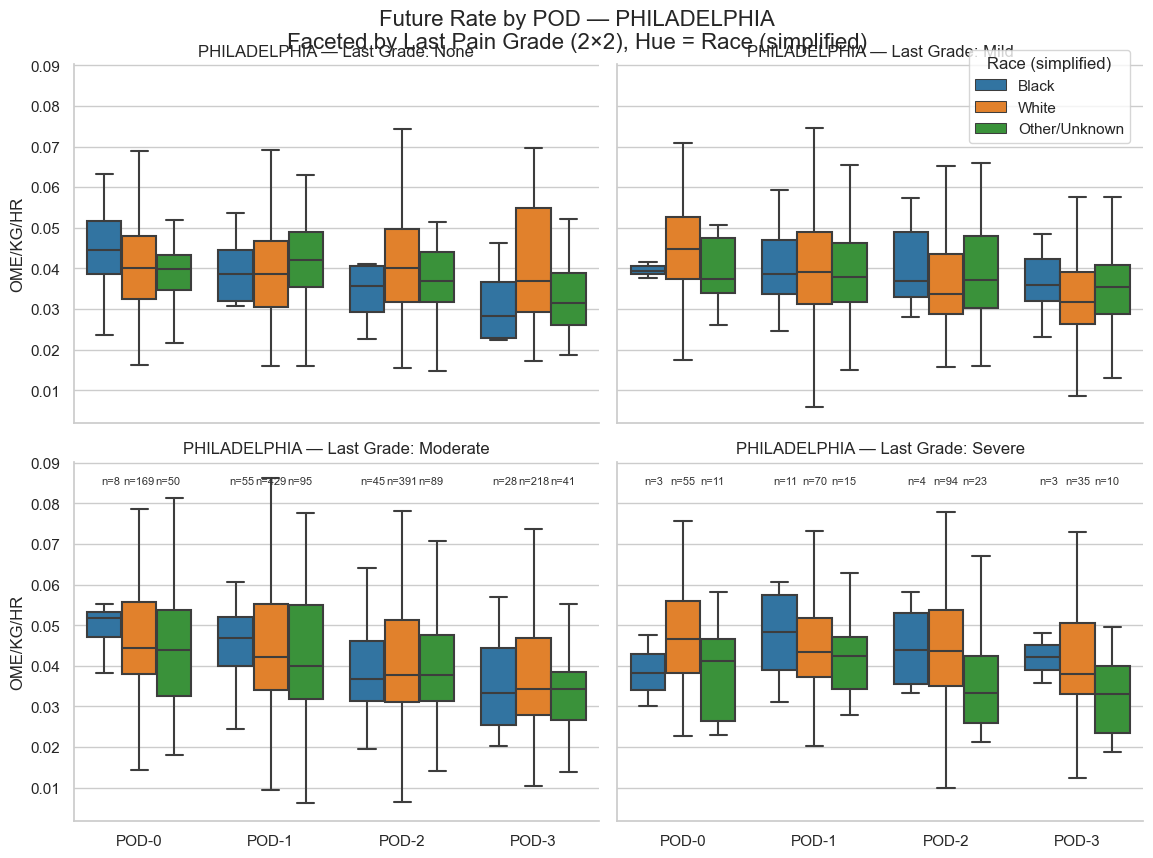

In [24]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SITE = "PHILADELPHIA"

# --- Prep: start from your original df and normalize like before ---
df2 = df.copy()

# Filter to the target site first (reduces work downstream)
df2 = df2[df2['FAC'].astype(str).str.strip().str.upper() == SITE.upper()].copy()
if df2.empty:
    raise ValueError(f"No rows found for FAC == {SITE}. Check spelling or case in df['FAC'].")

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {'White': 'White', 'Black or African American': 'Black'}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Facet order and hue order
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# Optional: consistent POD tick order
# If POD values look like 'POD0','POD1', etc., uncomment next 2 lines:
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template=f"{SITE} — Last Grade: {{col_name}}")

# Legend: move inside (top-right of the figure)
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
# Build counts
n_df = (
    df2.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
       .size().reset_index(name='n')
)

# Hue offsets to place n labels above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.0, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle(f'Future Rate by POD — {SITE}\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\2366900123.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


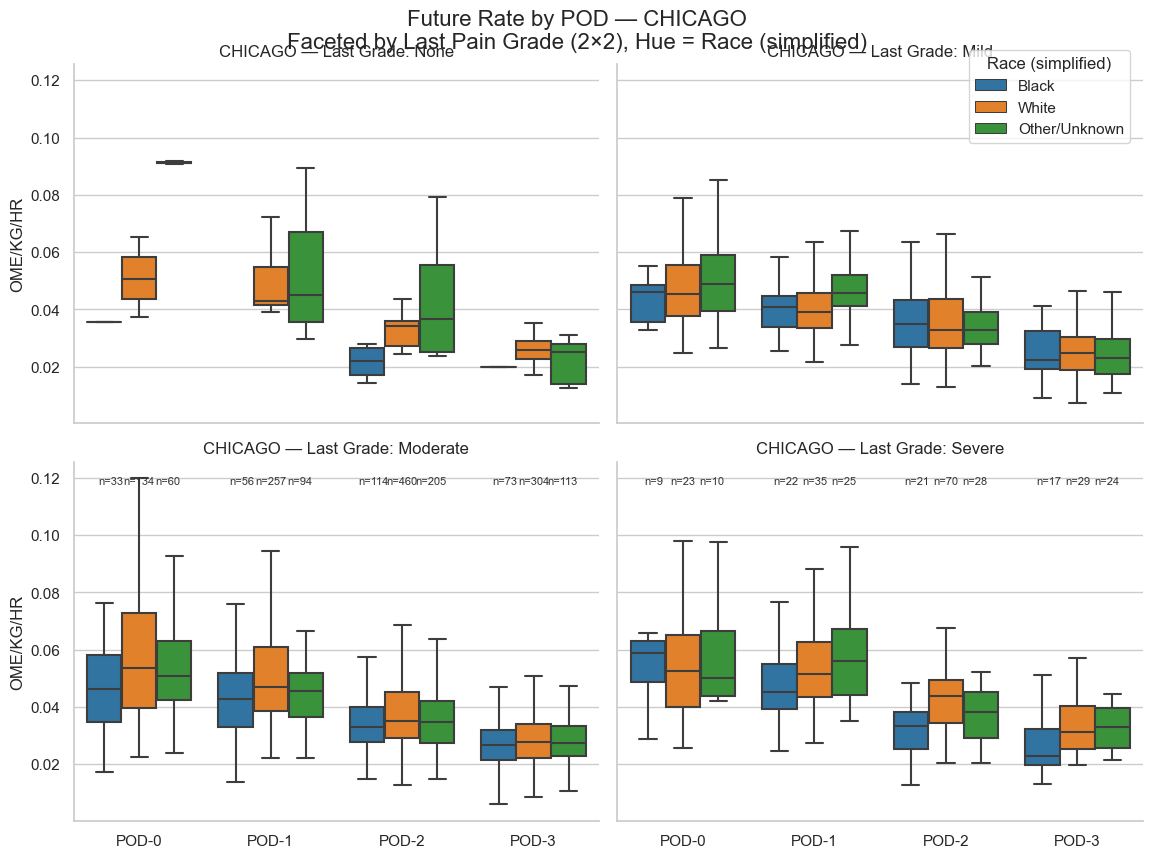

In [25]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SITE = "CHICAGO"

# --- Prep: start from your original df and normalize like before ---
df2 = df.copy()

# Filter to the target site first (reduces work downstream)
df2 = df2[df2['FAC'].astype(str).str.strip().str.upper() == SITE.upper()].copy()
if df2.empty:
    raise ValueError(f"No rows found for FAC == {SITE}. Check spelling or case in df['FAC'].")

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {'White': 'White', 'Black or African American': 'Black'}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Facet order and hue order
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# Optional: consistent POD tick order
# If POD values look like 'POD0','POD1', etc., uncomment next 2 lines:
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template=f"{SITE} — Last Grade: {{col_name}}")

# Legend: move inside (top-right of the figure)
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
# Build counts
n_df = (
    df2.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
       .size().reset_index(name='n')
)

# Hue offsets to place n labels above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.0, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle(f'Future Rate by POD — {SITE}\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\1613766663.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


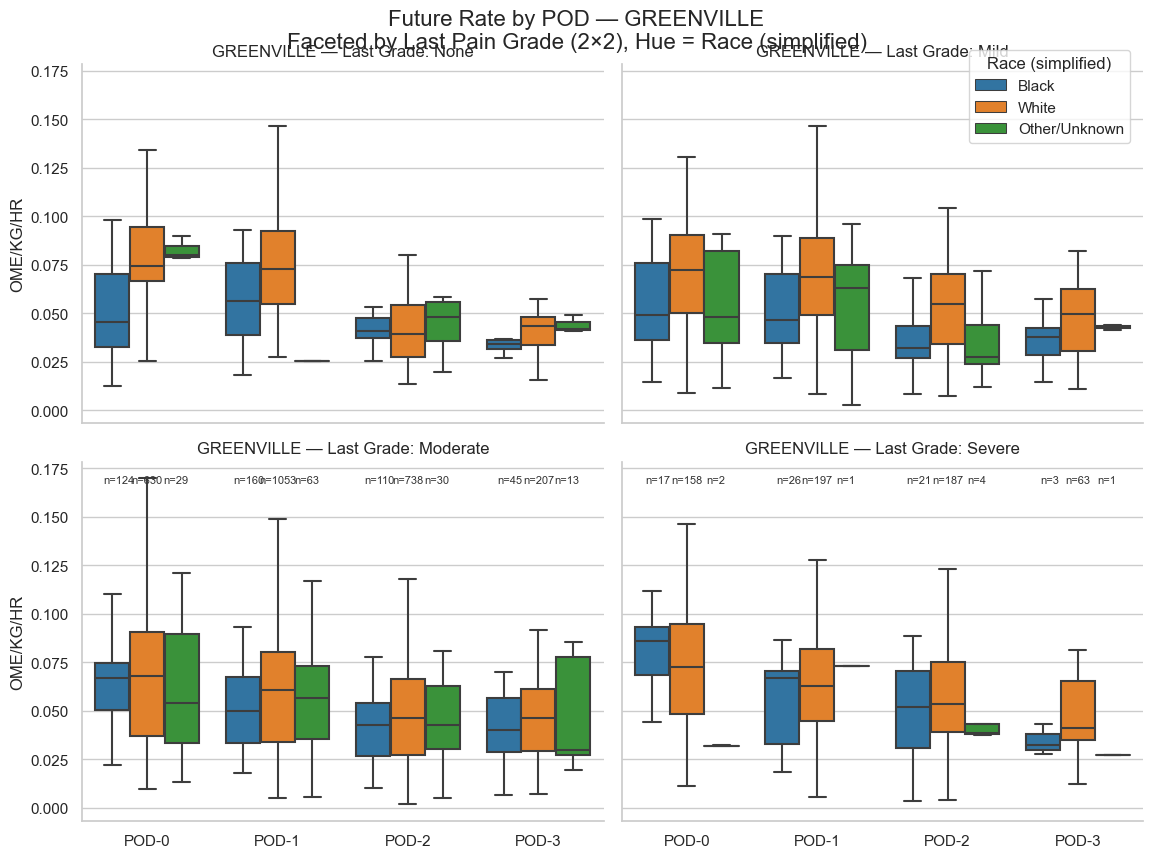

In [26]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SITE = "GREENVILLE"

# --- Prep: start from your original df and normalize like before ---
df2 = df.copy()

# Filter to the target site first (reduces work downstream)
df2 = df2[df2['FAC'].astype(str).str.strip().str.upper() == SITE.upper()].copy()
if df2.empty:
    raise ValueError(f"No rows found for FAC == {SITE}. Check spelling or case in df['FAC'].")

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {'White': 'White', 'Black or African American': 'Black'}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Facet order and hue order
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# Optional: consistent POD tick order
# If POD values look like 'POD0','POD1', etc., uncomment next 2 lines:
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template=f"{SITE} — Last Grade: {{col_name}}")

# Legend: move inside (top-right of the figure)
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
# Build counts
n_df = (
    df2.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
       .size().reset_index(name='n')
)

# Hue offsets to place n labels above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.0, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle(f'Future Rate by POD — {SITE}\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\1455362122.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


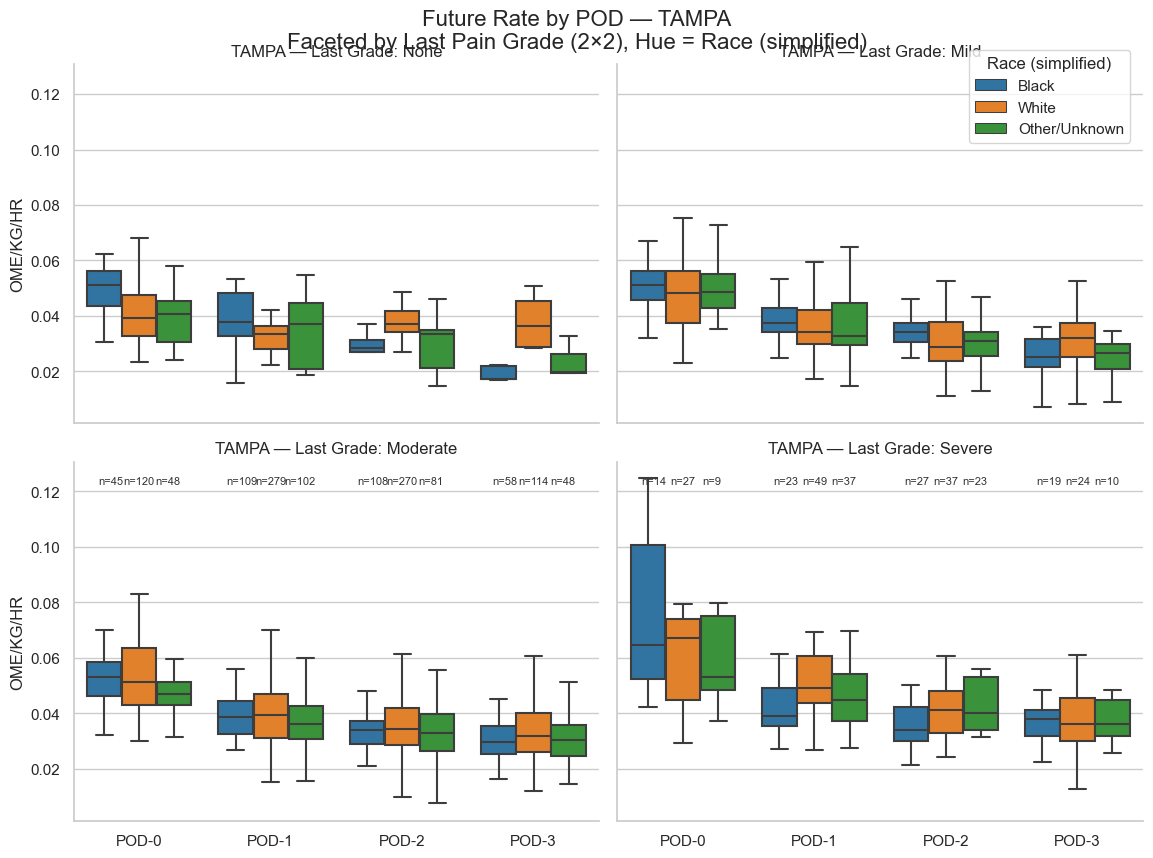

In [27]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SITE = "TAMPA"

# --- Prep: start from your original df and normalize like before ---
df2 = df.copy()

# Filter to the target site first (reduces work downstream)
df2 = df2[df2['FAC'].astype(str).str.strip().str.upper() == SITE.upper()].copy()
if df2.empty:
    raise ValueError(f"No rows found for FAC == {SITE}. Check spelling or case in df['FAC'].")

# Normalize RACE and make RACE_SIMPLE
df2['RACE'] = (df2['RACE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))
race_map = {'White': 'White', 'Black or African American': 'Black'}
df2['RACE_SIMPLE'] = df2['RACE'].map(race_map).fillna('Other/Unknown')

# Normalize LAST_GRADE
df2['LAST_GRADE'] = df2['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df2['LAST_GRADE'] = df2['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# Facet order and hue order
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# Palette
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# Optional: consistent POD tick order
# If POD values look like 'POD0','POD1', etc., uncomment next 2 lines:
# order_pod = sorted(df2['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template=f"{SITE} — Last Grade: {{col_name}}")

# Legend: move inside (top-right of the figure)
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
# Build counts
n_df = (
    df2.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
       .size().reset_index(name='n')
)

# Hue offsets to place n labels above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.0, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle(f'Future Rate by POD — {SITE}\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_22248\1997126130.py:104: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


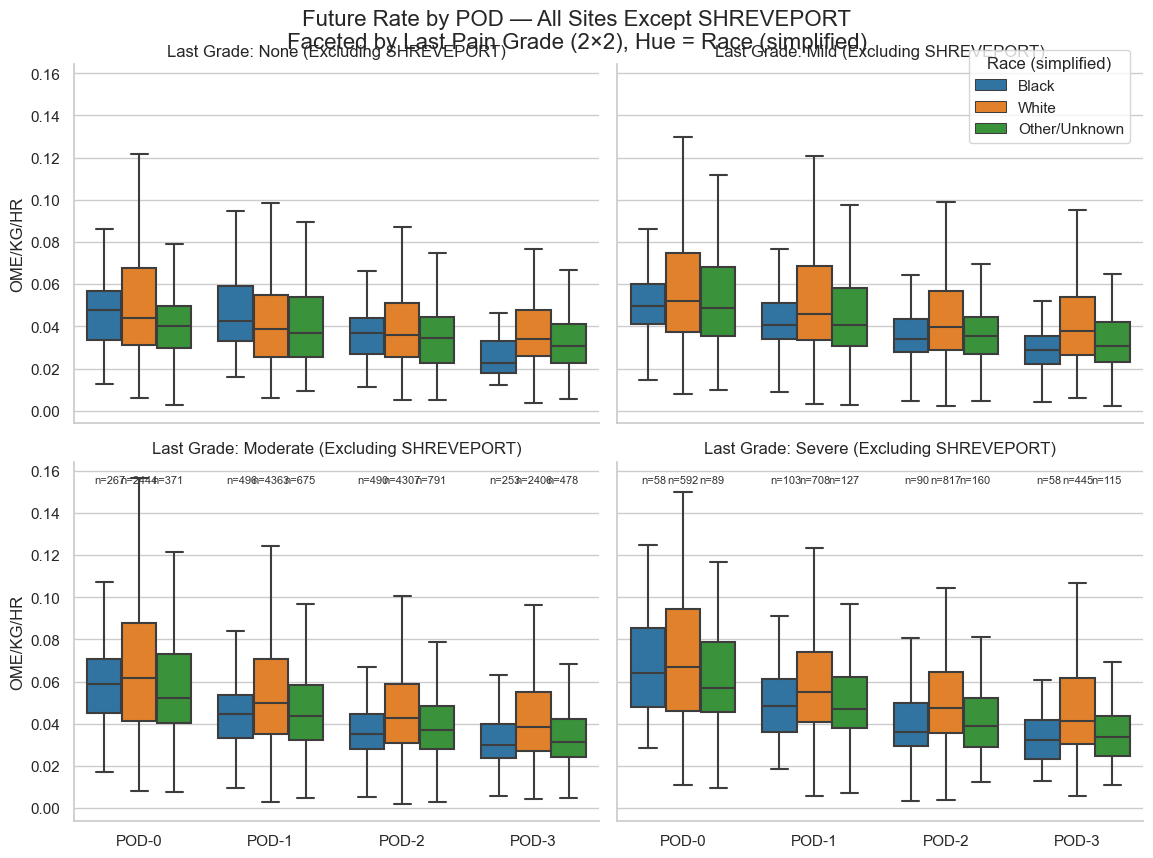

In [23]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

EXCLUDE_SITE = "SHREVEPORT"

# --- Start from original df and exclude SHREVEPORT ---
df2 = df.copy()
df2['FAC'] = df2['FAC'].astype(str).str.strip()
df_excl = df2[df2['FAC'].str.upper() != EXCLUDE_SITE.upper()].copy()

if df_excl.empty:
    raise ValueError(f"After excluding {EXCLUDE_SITE}, no rows remain. Check df['FAC'] values.")

# --- Normalize RACE and make RACE_SIMPLE ---
df_excl['RACE'] = (
    df_excl['RACE'].astype(str)
                    .str.strip()
                    .str.replace(r'\s+', ' ', regex=True)
)
race_map = {
    'White': 'White',
    'Black or African American': 'Black',
}
df_excl['RACE_SIMPLE'] = df_excl['RACE'].map(race_map).fillna('Other/Unknown')

# --- Normalize LAST_GRADE ---
df_excl['LAST_GRADE'] = df_excl['LAST_GRADE'].astype(str).str.strip()
grade_map = {
    '0-None': 'None', '1-Mild': 'Mild', '2-Moderate': 'Moderate', '3-Severe': 'Severe',
    'None': 'None', 'Mild': 'Mild', 'Moderate': 'Moderate', 'Severe': 'Severe'
}
df_excl['LAST_GRADE'] = df_excl['LAST_GRADE'].map(lambda g: grade_map.get(g, g))

# --- Facet & hue order ---
grade_order = [g for g in ['None', 'Mild', 'Moderate', 'Severe'] if g in df_excl['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black', 'White', 'Other/Unknown'] if r in df_excl['RACE_SIMPLE'].unique()]

# --- Palette ---
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# --- Optional: consistent POD tick order ---
# If POD values look like 'POD0','POD1', etc., uncomment the next two lines:
# order_pod = sorted(df_excl['POD'].astype(str).unique(), key=lambda s: int(str(s).replace('POD','').strip()))
order_pod = None  # set to a list if you want explicit ordering

# --- Draw the faceted plot (2×2) ---
sns.set_style('whitegrid')
g = sns.catplot(
    data=df_excl,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE', col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2,
    order=order_pod
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template="Last Grade: {col_name} (Excluding SHREVEPORT)")

# Legend: inside top-right of the figure
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True
)

# --- Optional: annotate sample sizes per POD × race in each panel ---
n_df = (
    df_excl.groupby(['LAST_GRADE', 'POD', 'RACE_SIMPLE'], dropna=False)
           .size().reset_index(name='n')
)

# Hue offsets so labels sit above each box (tweak if needed)
hue_offsets = {'Black': -0.22, 'White': 0.00, 'Other/Unknown': 0.22}

def annotate_counts(ax, panel_grade):
    sub = n_df[n_df['LAST_GRADE'] == panel_grade]
    # map POD categorical positions to x-coordinates
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    pod_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    ymax = ax.get_ylim()[1]
    for _, row in sub.iterrows():
        pod_label = str(row['POD'])
        if pod_label not in pod_to_x:
            continue
        x = pod_to_x[pod_label] + hue_offsets.get(row['RACE_SIMPLE'], 0.0)
        ax.text(x, ymax*0.96, f"n={row['n']}", ha='center', va='top', fontsize=8, color='#333')

for ax, grade in zip(g.axes.flat, g.col_names):
    annotate_counts(ax, grade)

plt.tight_layout()
g.fig.suptitle('Future Rate by POD — All Sites Except SHREVEPORT\nFaceted by Last Pain Grade (2×2), Hue = Race (simplified)', fontsize=16, y=1.02)
plt.show()


In [37]:

from scipy.stats import kruskal, mannwhitneyu
import itertools
import statsmodels.stats.multitest as smm

def panel_tests(grade):
    sub = df2[df2['LAST_GRADE'] == grade]
    groups = [sub[sub['RACE_SIMPLE'] == r]['FUTURE_RATE'].dropna() for r in race_order]
    # Global test
    H, p = kruskal(*groups)
    print(f"[{grade}] Kruskal–Wallis: H={H:.2f}, p={p:.3g}")
    # Pairwise
    pairs = list(itertools.combinations(race_order, 2))
    pvals = []
    for a, b in pairs:
        va = sub[sub['RACE_SIMPLE'] == a]['FUTURE_RATE'].dropna()
        vb = sub[sub['RACE_SIMPLE'] == b]['FUTURE_RATE'].dropna()
        stat, p12 = mannwhitneyu(va, vb, alternative='two-sided')
        pvals.append(p12)
    _, p_adj, _, _ = smm.multipletests(pvals, alpha=0.05, method='fdr_bh')
    for (a, b), pa in zip(pairs, p_adj):
        print(f"  {a} vs {b}: FDR p={pa:.3g}")

# Run per grade:
for grade in ['None','Mild','Moderate','Severe']:
    if grade in df2['LAST_GRADE'].unique():
        panel_tests(grade)



[None] Kruskal–Wallis: H=39.57, p=2.55e-09
  Black vs White: FDR p=9.33e-05
  Black vs Other/Unknown: FDR p=0.248
  White vs Other/Unknown: FDR p=8.23e-08
[Mild] Kruskal–Wallis: H=178.02, p=2.21e-39
  Black vs White: FDR p=3.69e-21
  Black vs Other/Unknown: FDR p=0.872
  White vs Other/Unknown: FDR p=9.07e-26
[Moderate] Kruskal–Wallis: H=426.14, p=2.92e-93
  Black vs White: FDR p=3.69e-56
  Black vs Other/Unknown: FDR p=0.171
  White vs Other/Unknown: FDR p=1.2e-52
[Severe] Kruskal–Wallis: H=147.58, p=9e-33
  Black vs White: FDR p=4.63e-18
  Black vs Other/Unknown: FDR p=0.941
  White vs Other/Unknown: FDR p=7.92e-22


In [39]:

# %% [code] Styled publication table of race differentials per LAST_GRADE
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- helpers ---
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0; lt = 0
    for ai in a:
        gt += np.sum(ai > b)
        lt += np.sum(ai < b)
    n = len(a) * len(b)
    return (gt - lt) / n

def hodges_lehmann(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    diffs = a[:, None] - b[None, :]
    return float(np.median(diffs))

# --- configuration ---
grade_order = [g for g in ['None','Mild','Moderate','Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black','White','Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# --- compute stats per grade ---
rows = []
for grade in grade_order:
    sub = df2[df2['LAST_GRADE'] == grade]

    # group vectors by race
    v_black = sub[sub['RACE_SIMPLE'] == 'Black']['FUTURE_RATE'].values
    v_white = sub[sub['RACE_SIMPLE'] == 'White']['FUTURE_RATE'].values
    v_other = sub[sub['RACE_SIMPLE'] == 'Other/Unknown']['FUTURE_RATE'].values

    # Global Kruskal–Wallis across available race groups (at least 2 non-empty)
    groups = [v for v in [v_black, v_white, v_other] if len(v)]
    if sum(len(v) > 0 for v in [v_black, v_white, v_other]) >= 2:
        H, p_kw = kruskal(*groups)
    else:
        H, p_kw = np.nan, np.nan

    # Pairwise Mann–Whitney (two-sided) raw p-values
    pairs = []
    if len(v_black) and len(v_white):
        stat, p_bw = mannwhitneyu(v_black, v_white, alternative='two-sided'); pairs.append(('Black vs White', p_bw))
    else:
        pairs.append(('Black vs White', np.nan))

    if len(v_black) and len(v_other):
        stat, p_bo = mannwhitneyu(v_black, v_other, alternative='two-sided'); pairs.append(('Black vs Other/Unknown', p_bo))
    else:
        pairs.append(('Black vs Other/Unknown', np.nan))

    if len(v_white) and len(v_other):
        stat, p_wo = mannwhitneyu(v_white, v_other, alternative='two-sided'); pairs.append(('White vs Other/Unknown', p_wo))
    else:
        pairs.append(('White vs Other/Unknown', np.nan))

    # FDR within this grade
    raw = np.array([p for _, p in pairs], dtype=float)
    valid = ~np.isnan(raw)
    p_fdr = np.array([np.nan]*len(raw))
    if valid.sum():
        _, p_adj, _, _ = multipletests(raw[valid], alpha=0.05, method='fdr_bh')
        p_fdr[valid] = p_adj

    # Medians per race
    med_black = np.nanmedian(v_black) if len(v_black) else np.nan
    med_white = np.nanmedian(v_white) if len(v_white) else np.nan
    med_other = np.nanmedian(v_other) if len(v_other) else np.nan

    # Effect size (White vs Black)
    delta_wb = cliffs_delta(v_white, v_black) if len(v_white) and len(v_black) else np.nan
    hl_wb    = hodges_lehmann(v_white, v_black) if len(v_white) and len(v_black) else np.nan

    # Interpretation logic
    sig_bw = (not np.isnan(p_fdr[0])) and (p_fdr[0] < 0.05)
    sig_bo = (not np.isnan(p_fdr[1])) and (p_fdr[1] < 0.05)
    sig_wo = (not np.isnan(p_fdr[2])) and (p_fdr[2] < 0.05)

    direction = None
    if sig_bw and not np.isnan(hl_wb):
        direction = "White > Black" if hl_wb > 0 else "Black > White"
    elif not sig_bw and not np.isnan(med_white) and not np.isnan(med_black):
        direction = "White ≈ Black"

    # Build concise interpretation string
    interp_parts = []
    if direction:
        interp_parts.append(direction)
    if sig_wo:
        interp_parts.append("White ≠ Other/Unknown")
    else:
        interp_parts.append("White ≈ Other/Unknown")
    if sig_bo:
        interp_parts.append("Black ≠ Other/Unknown")
    else:
        interp_parts.append("Black ≈ Other/Unknown")

    interpretation = "; ".join(interp_parts) + " (OME/kg/hr)"

    rows.append({
        "Last Grade": grade,
        "n (Black)": len(v_black),
        "Median (Black)": med_black,
        "n (White)": len(v_white),
        "Median (White)": med_white,
        "n (Other/Unknown)": len(v_other),
        "Median (Other/Unknown)": med_other,
        "Kruskal–Wallis H": H,
        "Kruskal–Wallis p": p_kw,
        "Black vs White (FDR p)": p_fdr[0],
        "White vs Other/Unknown (FDR p)": p_fdr[2],
        "Black vs Other/Unknown (FDR p)": p_fdr[1],
        "Cliff's δ (White−Black)": delta_wb,
        "HL diff (White−Black)": hl_wb,
        "Interpretation": interpretation
    })

tbl = pd.DataFrame(rows)

# --- formatting helpers for style ---
def fmt_p(p):
    if pd.isna(p):
        return "—"
    if p < 1e-3:
        return f"{p:.2e}"
    return f"{p:.3f}"

def fmt_num(x):
    return "—" if pd.isna(x) else f"{x:.3f}"

def highlight_sig(val):
    if pd.isna(val):
        return ""
    return "background-color: #ffe6e6;" if val < 0.05 else ""

def highlight_effect(val):
    if pd.isna(val):


SyntaxError: incomplete input (707384484.py, line 146)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kryan\AppData\Local\Temp\ipykernel_15280\3607341827.py:134: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


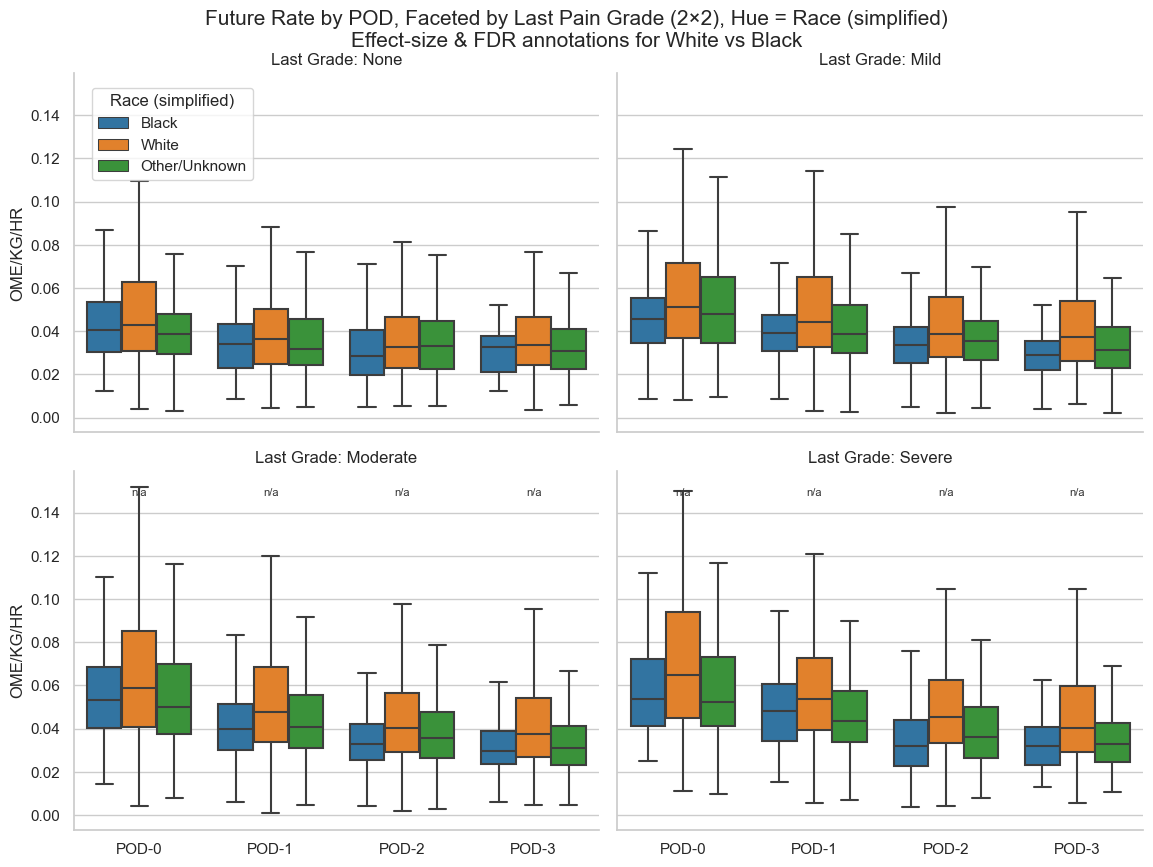

In [38]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

# ---------- helpers ----------
def cliffs_delta(a, b):
    """Cliff's delta for two 1D arrays (drops NaNs)."""
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    # Count pairwise comparisons
    gt = 0; lt = 0
    for ai in a:
        gt += np.sum(ai > b)
        lt += np.sum(ai < b)
    n = len(a) * len(b)
    return (gt - lt) / n

def hodges_lehmann(a, b):
    """Hodges–Lehmann estimator (median of all pairwise differences)."""
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    diffs = a[:, None] - b[None, :]
    return np.median(diffs)

# Optional: consistent POD order
order_pod = [f'POD-{i}' for i in range(4) if f'POD-{i}' in df2['POD'].astype(str).unique()]
if order_pod:
    df2['POD'] = pd.Categorical(df2['POD'].astype(str), categories=order_pod, ordered=True)

grade_order = [g for g in ['None','Mild','Moderate','Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black','White','Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]
race_palette = {'Black': '#1f77b4', 'White': '#ff7f0e', 'Other/Unknown': '#2ca02c'}

# ---------- compute p-values once per (grade, POD) for White vs Black ----------
rows = []
for grade in grade_order:
    sub_g = df2[df2['LAST_GRADE'] == grade]
    for pod in (order_pod if order_pod else sorted(sub_g['POD'].astype(str).unique())):
        gb = sub_g[sub_g['POD'].astype(str) == pod]
        a = gb[gb['RACE_SIMPLE'] == 'White']['FUTURE_RATE'].values
        b = gb[gb['RACE_SIMPLE'] == 'Black']['FUTURE_RATE'].values
        if len(a) and len(b):
            stat, p = mannwhitneyu(a, b, alternative='two-sided')
            delta = cliffs_delta(a, b)
            hl    = hodges_lehmann(a, b)
            rows.append({'LAST_GRADE': grade, 'POD': pod, 'p_raw': p, 'delta': delta, 'HL_diff': hl,
                         'n_white': len(a), 'n_black': len(b)})
        else:
            rows.append({'LAST_GRADE': grade, 'POD': pod, 'p_raw': np.nan,
                         'delta': np.nan, 'HL_diff': np.nan, 'n_white': len(a), 'n_black': len(b)})

eff = pd.DataFrame(rows)

# FDR correction **within each grade** across its PODs
eff['p_fdr'] = np.nan
for grade in grade_order:
    mask = eff['LAST_GRADE'] == grade
    pvals = eff.loc[mask, 'p_raw'].values
    # Only correct non-NaN p-values
    valid = ~np.isnan(pvals)
    if valid.sum():
        _, p_adj, _, _ = multipletests(pvals[valid], alpha=0.05, method='fdr_bh')
        eff.loc[mask].loc[valid, 'p_fdr'] = p_adj

# ---------- build figure and annotate ----------
sns.set_style('whitegrid')
g = sns.catplot(
    data=df2,
    x='POD', y='FUTURE_RATE',
    hue='RACE_SIMPLE',
    col='LAST_GRADE',
    col_order=grade_order,
    kind='box',
    showfliers=False,
    hue_order=race_order,
    palette=race_palette,
    col_wrap=2,
    sharey=True,
    height=4.2,
    aspect=1.2
)

g.set_axis_labels("", "OME/KG/HR")
g.set_titles(col_template="Last Grade: {col_name}")

# Move legend to upper-left of upper-left subplot
handles, labels = g.axes[0].get_legend_handles_labels()
if g._legend is not None:
    g._legend.remove()
g.fig.legend(
    handles, labels, title='Race (simplified)',
    loc='upper left', bbox_to_anchor=(0.02, 0.98),
    bbox_transform=g.axes[0].transAxes, frameon=True
)

# Annotate per (grade, POD): p_fdr and direction using HL_diff sign
for ax, grade in zip(g.axes.flat, g.col_names):
    # Map x tick labels to positions
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    lab_to_x = {lab: xticks[i] for i, lab in enumerate(xlabels)}
    # Place annotations just above the boxes
    ymax = ax.get_ylim()[1]
    # annotate for each POD in this grade
    sub = eff[eff['LAST_GRADE'] == grade]
    for _, r in sub.iterrows():
        lab = str(r['POD'])
        if lab not in lab_to_x: 
            continue
        x = lab_to_x[lab]
        p = r['p_fdr']
        hl = r['HL_diff']
        if np.isnan(p):
            txt = "n/a"
        else:
            star = "∗" if p < 0.05 else ""
            # Direction arrow: HL_diff > 0 means White > Black
            arrow = "↑ White" if (not np.isnan(hl) and hl > 0) else ("↑ Black" if (not np.isnan(hl) and hl < 0) else "")
            txt = f"{star} p={p:.2g} {arrow}"
        ax.text(x, ymax*0.95, txt, ha='center', va='top', fontsize=8, color='#333')

plt.tight_layout()
g.fig.suptitle('Future Rate by POD, Faceted by Last Pain Grade (2×2), Hue = Race (simplified)\nEffect-size & FDR annotations for White vs Black', fontsize=15, y=1.03)

# Optional: save the effect size table
# eff.to_csv('race_effect_sizes_by_grade_pod.csv', index=False)

plt.show()


In [42]:

# Styled publication table: race differentials by LAST_GRADE
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- helpers ----------
def cliffs_delta(a, b):
    """Cliff's delta (directional, nonparametric)."""
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0; lt = 0
    for ai in a:
        gt += np.sum(ai > b)
        lt += np.sum(ai < b)
    n = len(a) * len(b)
    return (gt - lt) / n

def hodges_lehmann(a, b):
    """Hodges–Lehmann median difference (robust)."""
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    diffs = a[:, None] - b[None, :]
    return float(np.median(diffs))

def fmt_p(p):
    if pd.isna(p):
        return "-"
    return f"{p:.2e}" if p < 1e-3 else f"{p:.3f}"

def fmt_num(x):
    return "-" if pd.isna(x) else f"{x:.3f}"

def highlight_sig(val):
    """Shade significant p-values (FDR < 0.05)."""
    if pd.isna(val):
        return ""
    return "background-color: #ffe6e6;" if val < 0.05 else ""

def highlight_effect(val):
    """Shade Cliff's delta by magnitude."""
    if pd.isna(val):
        return ""
    mag = abs(val)
    if mag >= 0.474:   # large
        return "background-color: #d1ffd1;"
    elif mag >= 0.330: # medium
        return "background-color: #e9ffe9;"
    elif mag >= 0.147: # small
        return "background-color: #f5fff5;"
    else:
        return ""

# ---------- configuration ----------
grade_order = [g for g in ['None','Mild','Moderate','Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black','White','Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# ---------- compute stats per grade ----------
rows = []
for grade in grade_order:
    sub = df2[df2['LAST_GRADE'] == grade]

    v_black = sub[sub['RACE_SIMPLE'] == 'Black']['FUTURE_RATE'].astype(float).values
    v_white = sub[sub['RACE_SIMPLE'] == 'White']['FUTURE_RATE'].astype(float).values
    v_other = sub[sub['RACE_SIMPLE'] == 'Other/Unknown']['FUTURE_RATE'].astype(float).values

    # Global Kruskal–Wallis
    groups = [v for v in [v_black, v_white, v_other] if len(v)]
    H, p_kw = (kruskal(*groups) if sum(len(v) > 0 for v in [v_black, v_white, v_other]) >= 2 else (np.nan, np.nan))

    # Pairwise p-values
    pairs = [
        ('Black vs White', mannwhitneyu(v_black, v_white, alternative='two-sided').pvalue if len(v_black) and len(v_white) else np.nan),
        ('Black vs Other/Unknown', mannwhitneyu(v_black, v_other, alternative='two-sided').pvalue if len(v_black) and len(v_other) else np.nan),
        ('White vs Other/Unknown', mannwhitneyu(v_white, v_other, alternative='two-sided').pvalue if len(v_white) and len(v_other) else np.nan),
    ]
    raw = np.array([p for _, p in pairs], dtype=float)
    valid = ~np.isnan(raw)
    p_fdr = np.array([np.nan]*len(raw))
    if valid.sum():
        _, p_adj, _, _ = multipletests(raw[valid], alpha=0.05, method='fdr_bh')
        p_fdr[valid] = p_adj

    # Medians
    med_black = np.nanmedian(v_black) if len(v_black) else np.nan
    med_white = np.nanmedian(v_white) if len(v_white) else np.nan
    med_other = np.nanmedian(v_other) if len(v_other) else np.nan

    # Effect size & robust difference (White − Black)
    delta_wb = cliffs_delta(v_white, v_black) if len(v_white) and len(v_black) else np.nan
    hl_wb    = hodges_lehmann(v_white, v_black) if len(v_white) and len(v_black) else np.nan

    # Interpretation
    sig_bw = (not pd.isna(p_fdr[0])) and (p_fdr[0] < 0.05)
    sig_bo = (not pd.isna(p_fdr[1])) and (p_fdr[1] < 0.05)
    sig_wo = (not pd.isna(p_fdr[2])) and (p_fdr[2] < 0.05)
    if sig_bw and not pd.isna(hl_wb):
        dir_str = "White > Black" if hl_wb > 0 else "Black > White"
    elif not sig_bw and not pd.isna(med_white) and not pd.isna(med_black):
        dir_str = "White ≈ Black"
    else:
        dir_str = "White vs Black: n/a"

    interpretation = (
        f"{dir_str}; "
        f"{'White ≠ Other/Unknown' if sig_wo else 'White ≈ Other/Unknown'}; "
        f"{'Black ≠ Other/Unknown' if sig_bo else 'Black ≈ Other/Unknown'} "
        "(OME/kg/hr)"
    )

    rows.append({
        "Last Grade": grade,
        "n (Black)": len(v_black),
        "Median (Black)": med_black,
        "n (White)": len(v_white),
        "Median (White)": med_white,
        "n (Other/Unknown)": len(v_other),
        "Median (Other/Unknown)": med_other,
        "Kruskal–Wallis H": H,
        "Kruskal–Wallis p": p_kw,
        "FDR p (Black vs White)": p_fdr[0],
        "FDR p (Black vs Other/Unknown)": p_fdr[1],
        "FDR p (White vs Other/Unknown)": p_fdr[2],
        "Cliff's δ (White−Black)": delta_wb,
        "HL diff (White−Black)": hl_wb,
        "Interpretation": interpretation
    })

tbl = pd.DataFrame(rows)

# ---------- style ----------
styled = (
    tbl
    .rename(columns={
        "Median (Black)": "Median Black",
        "Median (White)": "Median White",
        "Median (Other/Unknown)": "Median Other/Unknown",
        "Kruskal–Wallis p": "KW p",
    })
    .style
    .format({
        "Median Black": fmt_num,
        "Median White": fmt_num,
        "Median Other/Unknown": fmt_num,
        "Kruskal–Wallis H": fmt_num,
        "KW p": fmt_p,
        "FDR p (Black vs White)": fmt_p,
        "FDR p (Black vs Other/Unknown)": fmt_p,
        "FDR p (White vs Other/Unknown)": fmt_p,
        "Cliff's δ (White−Black)": fmt_num,
        "HL diff (White−Black)": fmt_num
    })
    .applymap(highlight_sig, subset=[
        "KW p",
        "FDR p (Black vs White)",
        "FDR p (Black vs Other/Unknown)",
        "FDR p (White vs Other/Unknown)"
    ])
    .applymap(highlight_effect, subset=["Cliff's δ (White−Black)"])
    .set_properties(subset=["Interpretation"], **{"font-style": "italic"})
    .set_caption(
        "Race differences in FUTURE_RATE by Last Pain Grade (OME/kg/hr). "
        "Significant p-values (FDR < 0.05) highlighted; Cliff’s δ shading reflects effect magnitude for White vs Black."
    )
)

styled  # display in notebook

# Optional: export to HTML for publication
# html = styled.to_html()
# with open("race_differentials_by_grade.html", "w", encoding="utf-8") as f:
#     f.write(html)



,Last Grade,n (Black),Median Black,n (White),Median White,n (Other/Unknown),Median Other/Unknown,Kruskal–Wallis H,KW p,FDR p (Black vs White),FDR p (Black vs Other/Unknown),FDR p (White vs Other/Unknown),Cliff's δ (White−Black),HL diff (White−Black),Interpretation
0,None,757,0.035,3124,0.038,835,0.034,39.571,2.55e-09,9.33e-05,0.248,8.23e-08,0.094,0.003,White > Black; White ≠ Other/Unknown; Black ≈ Other/Unknown (OME/kg/hr)
1,Mild,1009,0.038,8024,0.044,1603,0.037,178.016,2.21e-39,3.69e-21,0.872,9.07e-26,0.183,0.006,White > Black; White ≠ Other/Unknown; Black ≈ Other/Unknown (OME/kg/hr)
2,Moderate,2087,0.037,14713,0.045,2693,0.038,426.138,2.92e-93,3.69e-56,0.171,1.20e-52,0.214,0.008,White > Black; White ≠ Other/Unknown; Black ≈ Other/Unknown (OME/kg/hr)
3,Severe,460,0.039,2892,0.051,609,0.041,147.576,9.00e-33,4.63e-18,0.941,7.92e-22,0.252,0.010,White > Black; White ≠ Other/Unknown; Black ≈ Other/Unknown (OME/kg/hr)


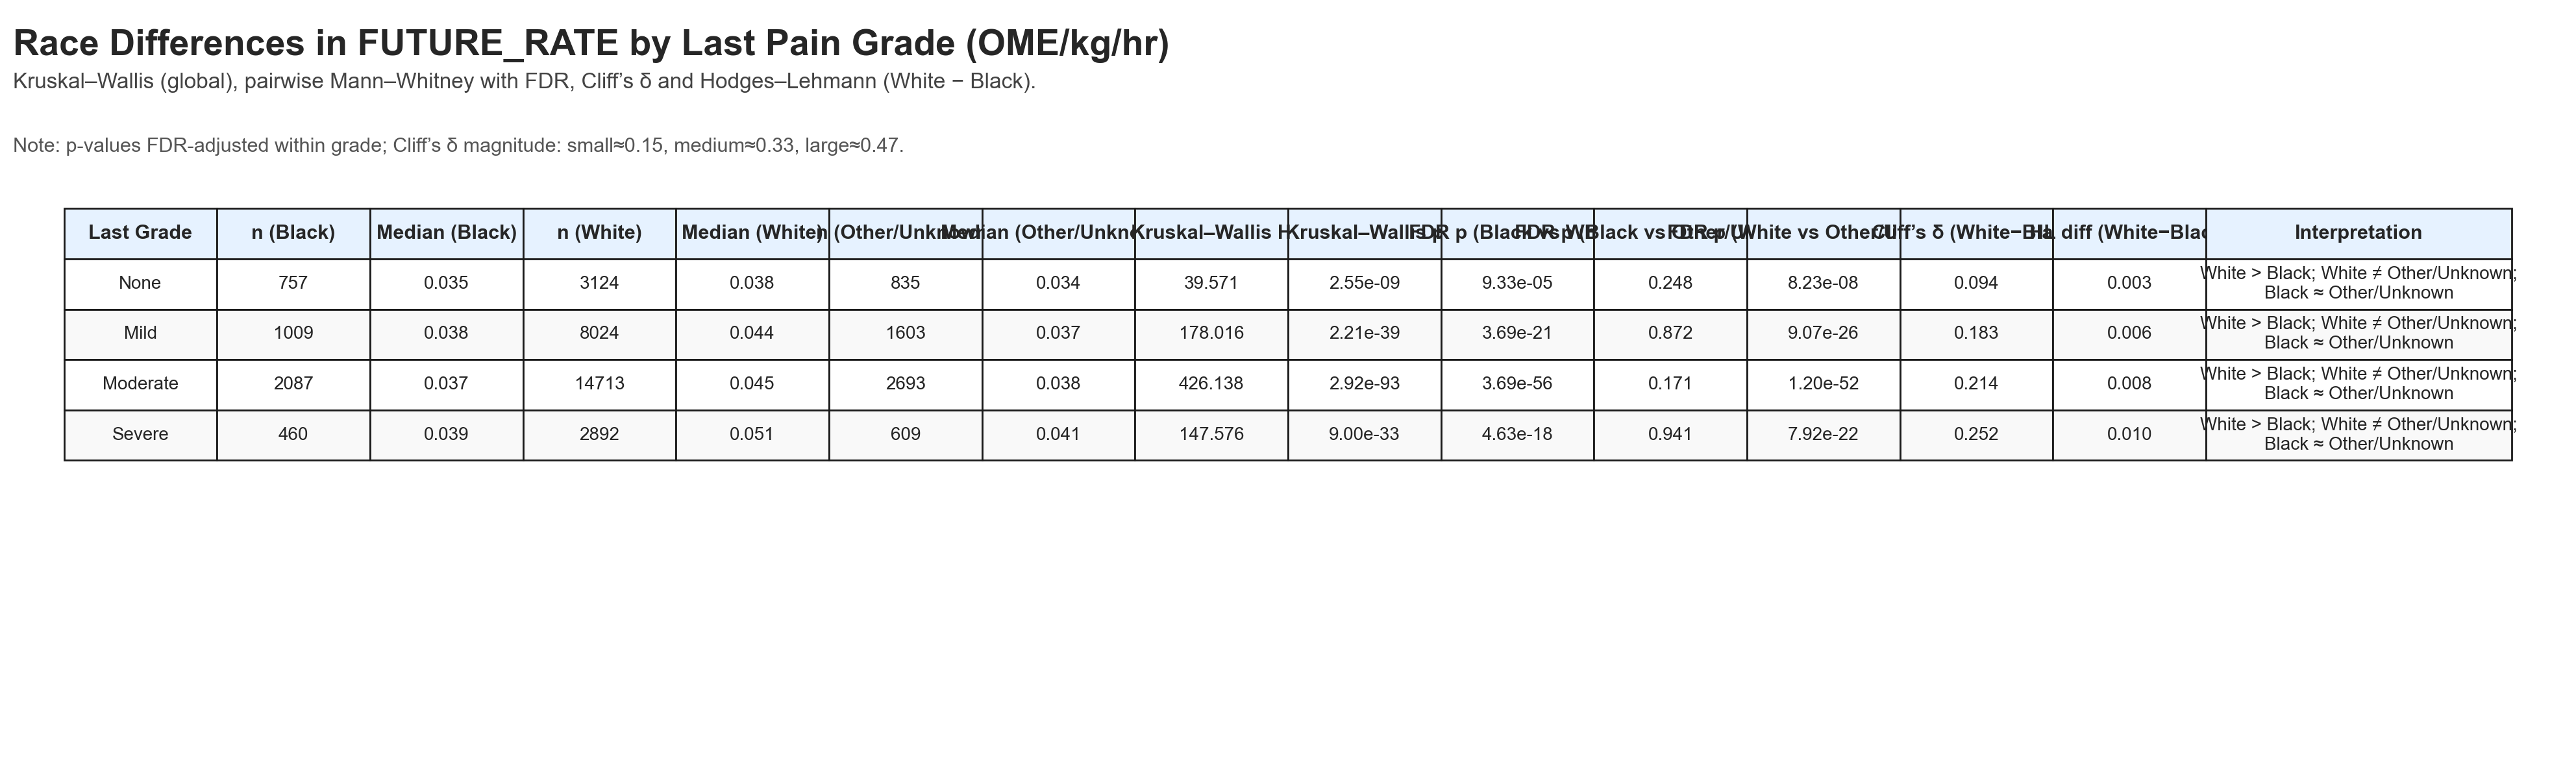

Saved print-ready table image to: race_differentials_by_grade.png


In [43]:


# %% [code] Build a publication table and export as a PNG image (print-ready)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import textwrap

# ---------- helpers ----------
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0: return np.nan
    gt = 0; lt = 0
    for ai in a:
        gt += np.sum(ai > b)
        lt += np.sum(ai < b)
    n = len(a) * len(b)
    return (gt - lt) / n

def hodges_lehmann(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0: return np.nan
    diffs = a[:, None] - b[None, :]
    return float(np.median(diffs))

def fmt_p(p):
    if pd.isna(p): return "-"
    return f"{p:.2e}" if p < 1e-3 else f"{p:.3f}"

def fmt_num(x, nd=3):
    return "-" if pd.isna(x) else f"{x:.{nd}f}"

# ---------- configuration ----------
title_text = "Race Differences in FUTURE_RATE by Last Pain Grade (OME/kg/hr)"
subtitle_text = "Kruskal–Wallis (global), pairwise Mann–Whitney with FDR, Cliff’s δ and Hodges–Lehmann (White − Black)."
outfile = "race_differentials_by_grade.png"

grade_order = [g for g in ['None','Mild','Moderate','Severe'] if g in df2['LAST_GRADE'].unique()]
race_order  = [r for r in ['Black','White','Other/Unknown'] if r in df2['RACE_SIMPLE'].unique()]

# ---------- compute stats per grade ----------
rows = []
for grade in grade_order:
    sub = df2[df2['LAST_GRADE'] == grade]

    v_black = sub[sub['RACE_SIMPLE'] == 'Black']['FUTURE_RATE'].astype(float).values
    v_white = sub[sub['RACE_SIMPLE'] == 'White']['FUTURE_RATE'].astype(float).values
    v_other = sub[sub['RACE_SIMPLE'] == 'Other/Unknown']['FUTURE_RATE'].astype(float).values

    # Global Kruskal–Wallis
    groups = [v for v in [v_black, v_white, v_other] if len(v)]
    H, p_kw = (kruskal(*groups) if sum(len(v) > 0 for v in [v_black, v_white, v_other]) >= 2 else (np.nan, np.nan))

    # Pairwise raw p-values
    p_bw = mannwhitneyu(v_black, v_white, alternative='two-sided').pvalue if len(v_black) and len(v_white) else np.nan
    p_bo = mannwhitneyu(v_black, v_other, alternative='two-sided').pvalue if len(v_black) and len(v_other) else np.nan
    p_wo = mannwhitneyu(v_white, v_other, alternative='two-sided').pvalue if len(v_white) and len(v_other) else np.nan

    # FDR within grade
    raw = np.array([p_bw, p_bo, p_wo], dtype=float)
    valid = ~np.isnan(raw)
    p_fdr = np.array([np.nan]*len(raw))
    if valid.sum():
        _, p_adj, _, _ = multipletests(raw[valid], alpha=0.05, method='fdr_bh')
        p_fdr[valid] = p_adj

    # Medians
    med_black = np.nanmedian(v_black) if len(v_black) else np.nan
    med_white = np.nanmedian(v_white) if len(v_white) else np.nan
    med_other = np.nanmedian(v_other) if len(v_other) else np.nan

    # Effect sizes (White − Black)
    delta_wb = cliffs_delta(v_white, v_black) if len(v_white) and len(v_black) else np.nan
    hl_wb    = hodges_lehmann(v_white, v_black) if len(v_white) and len(v_black) else np.nan

    # Interpretation (compact)
    sig_bw = (not pd.isna(p_fdr[0])) and (p_fdr[0] < 0.05)
    sig_bo = (not pd.isna(p_fdr[1])) and (p_fdr[1] < 0.05)
    sig_wo = (not pd.isna(p_fdr[2])) and (p_fdr[2] < 0.05)
    if sig_bw and not pd.isna(hl_wb):
        dir_str = "White > Black" if hl_wb > 0 else "Black > White"
    elif not sig_bw and not pd.isna(med_white) and not pd.isna(med_black):
        dir_str = "White ≈ Black"
    else:
        dir_str = "White vs Black: n/a"
    interpretation = (
        f"{dir_str}; "
        f"{'White ≠ Other/Unknown' if sig_wo else 'White ≈ Other/Unknown'}; "
        f"{'Black ≠ Other/Unknown' if sig_bo else 'Black ≈ Other/Unknown'}"
    )

    rows.append({
        "Last Grade": grade,
        "n (Black)": len(v_black),
        "Median (Black)": med_black,
        "n (White)": len(v_white),
        "Median (White)": med_white,
        "n (Other/Unknown)": len(v_other),
        "Median (Other/Unknown)": med_other,
        "Kruskal–Wallis H": H,
        "Kruskal–Wallis p": p_kw,
        "FDR p (Black vs White)": p_fdr[0],
        "FDR p (Black vs Other/Unknown)": p_fdr[1],
        "FDR p (White vs Other/Unknown)": p_fdr[2],
        "Cliff’s δ (White−Black)": delta_wb,
        "HL diff (White−Black)": hl_wb,
        "Interpretation": interpretation
    })

tbl = pd.DataFrame(rows)

# ---------- format strings for rendering ----------
tbl_fmt = tbl.copy()
for c in ["Median (Black)", "Median (White)", "Median (Other/Unknown)",
          "Kruskal–Wallis H", "Cliff’s δ (White−Black)", "HL diff (White−Black)"]:
    tbl_fmt[c] = tbl_fmt[c].apply(lambda x: fmt_num(x, nd=3))

tbl_fmt["Kruskal–Wallis p"] = tbl_fmt["Kruskal–Wallis p"].apply(fmt_p)
for c in ["FDR p (Black vs White)", "FDR p (Black vs Other/Unknown)", "FDR p (White vs Other/Unknown)"]:
    tbl_fmt[c] = tbl_fmt[c].apply(fmt_p)

# Wrap interpretation lines for better fit
wrap_width = 38  # adjust if you want wider/narrower text
tbl_fmt["Interpretation"] = tbl_fmt["Interpretation"].apply(lambda s: "\n".join(textwrap.wrap(s, width=wrap_width)))

# ---------- render to image with matplotlib ----------
# Grid: title + subtitle + table
n_rows = tbl_fmt.shape[0]
n_cols = tbl_fmt.shape[1]
col_labels = list(tbl_fmt.columns)
cell_text = tbl_fmt.values.tolist()

fig_h = 0.6 * (n_rows + 6)    # dynamic height
fig_w = 20                    # wide page for print
fig = plt.figure(figsize=(fig_w, fig_h), dpi=200)
gs = gridspec.GridSpec(3, 1, height_ratios=[0.12, 0.08, 0.80])

# Title
ax_title = fig.add_subplot(gs[0])
ax_title.axis("off")
ax_title.text(0.0, 0.6, title_text, fontsize=20, weight='bold', ha='left', va='center')
ax_title.text(0.0, 0.15, subtitle_text, fontsize=12, color="#444", ha='left', va='center')

# Subtitle line
ax_subline = fig.add_subplot(gs[1])
ax_subline.axis("off")
ax_subline.text(0.0, 0.5, "Note: p-values FDR-adjusted within grade; Cliff’s δ magnitude: small≈0.15, medium≈0.33, large≈0.47.",
                fontsize=11, color="#555", ha='left', va='center')

# Table
ax_tbl = fig.add_subplot(gs[2])
ax_tbl.axis("off")

# Column widths (make interpretation column wider)
base_w = 1.0 / n_cols
col_widths = [base_w]*n_cols
if "Interpretation" in col_labels:
    idx_int = col_labels.index("Interpretation")
    for i in range(n_cols):
        col_widths[i] = 0.9*base_w
    col_widths[idx_int] = 1.8*base_w  # wider for wrapped text

# Create table
the_table = ax_tbl.table(cellText=cell_text,
                         colLabels=col_labels,
                         colWidths=col_widths,
                         cellLoc='center',
                         loc='upper left')

# Styling: header
for j in range(n_cols):
    cell = the_table[0, j]
    cell.set_facecolor("#e6f2ff")   # light blue header
    cell.set_text_props(weight='bold', fontsize=11)

# Styling: body rows with alternating shading
for i in range(1, n_rows+1):
    for j in range(n_cols):
        cell = the_table[i, j]
        # Alternate row color for readability
        cell.set_facecolor("#ffffff" if i % 2 == 1 else "#f9f9f9")
        cell.set_text_props(fontsize=10)

# Auto row heights
the_table.auto_set_font_size(False)
the_table.scale(1, 1.8)  # increase row height

# Tight layout and save
plt.tight_layout()
#plt.savefig(outfile, dpi=300)
#plt.close(fig)
plt.show()

print(f"Saved print-ready table image to: {outfile}")



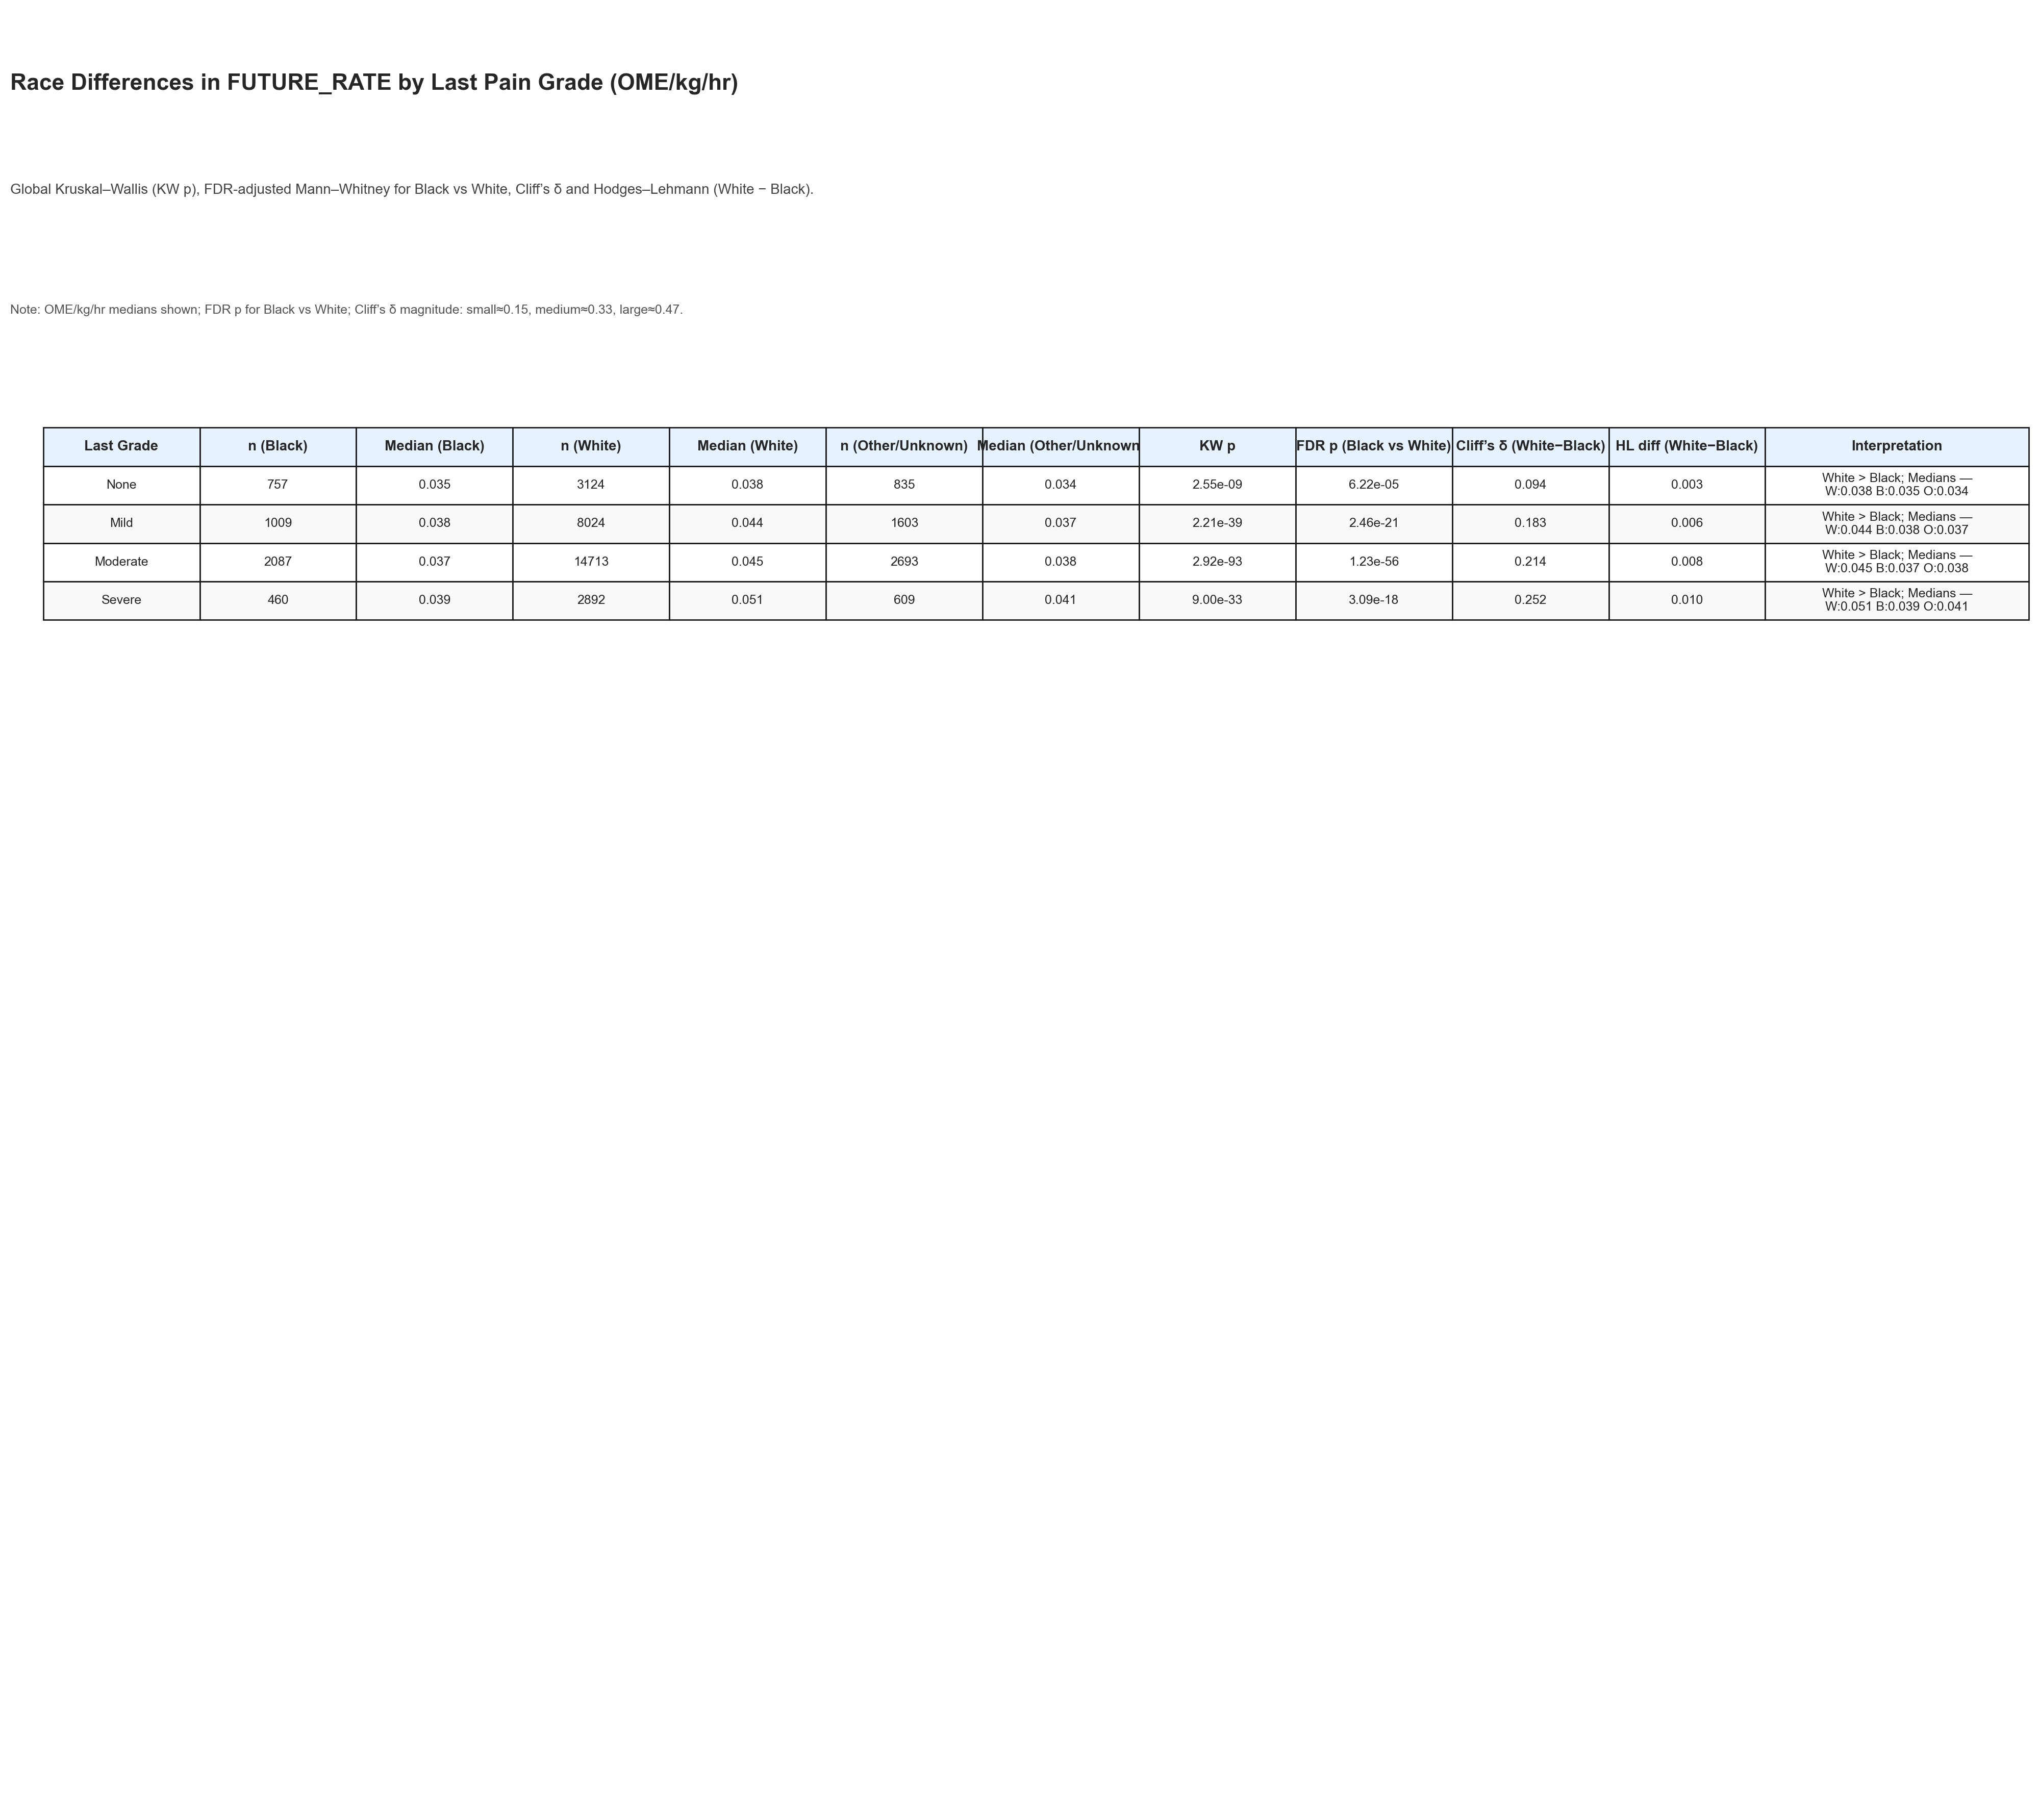

Saved slimmer print-ready table image to: race_differentials_by_grade_SLIM.png


In [48]:

# %% [code] Slim publication table -> portrait PNG (narrower)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import textwrap

# ---------- helpers ----------
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0: return np.nan
    gt = 0; lt = 0
    for ai in a:
        gt += np.sum(ai > b)
        lt += np.sum(ai < b)
    n = len(a) * len(b)
    return (gt - lt) / n

def hodges_lehmann(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0: return np.nan
    diffs = a[:, None] - b[None, :]
    return float(np.median(diffs))

def fmt_p(p):
    if pd.isna(p): return "-"
    return f"{p:.2e}" if p < 1e-3 else f"{p:.3f}"

def fmt_num(x, nd=3):
    return "-" if pd.isna(x) else f"{x:.{nd}f}"

# ---------- configuration ----------
title_text = "Race Differences in FUTURE_RATE by Last Pain Grade (OME/kg/hr)"
subtitle_text = "Global Kruskal–Wallis (KW p), FDR-adjusted Mann–Whitney for Black vs White, Cliff’s δ and Hodges–Lehmann (White − Black)."
outfile = "race_differentials_by_grade_SLIM.png"

grade_order = [g for g in ['None','Mild','Moderate','Severe'] if g in df2['LAST_GRADE'].unique()]

# ---------- compute stats per grade ----------
rows = []
for grade in grade_order:
    sub = df2[df2['LAST_GRADE'] == grade]

    v_black = sub[sub['RACE_SIMPLE'] == 'Black']['FUTURE_RATE'].astype(float).values
    v_white = sub[sub['RACE_SIMPLE'] == 'White']['FUTURE_RATE'].astype(float).values
    v_other = sub[sub['RACE_SIMPLE'] == 'Other/Unknown']['FUTURE_RATE'].astype(float).values

    # Global KW
    groups = [v for v in [v_black, v_white, v_other] if len(v)]
    H, p_kw = (kruskal(*groups) if sum(len(v) > 0 for v in [v_black, v_white, v_other]) >= 2 else (np.nan, np.nan))

    # Pairwise: Black vs White
    p_bw = mannwhitneyu(v_black, v_white, alternative='two-sided').pvalue if len(v_black) and len(v_white) else np.nan
    # FDR within grade (only one test retained here, so same value; kept for consistency if you add more pairs)
    p_fdr_bw = p_bw  # with one comparison, FDR == raw p

    # Medians
    med_black = np.nanmedian(v_black) if len(v_black) else np.nan
    med_white = np.nanmedian(v_white) if len(v_white) else np.nan
    med_other = np.nanmedian(v_other) if len(v_other) else np.nan

    # Effect sizes (White − Black)
    delta_wb = cliffs_delta(v_white, v_black) if len(v_white) and len(v_black) else np.nan
    hl_wb    = hodges_lehmann(v_white, v_black) if len(v_white) and len(v_black) else np.nan

    # Interpretation (compact, focusing on Black vs White; we can append Other/Unknown medians)
    if not pd.isna(p_fdr_bw) and p_fdr_bw < 0.05 and not pd.isna(hl_wb):
        dir_str = "White > Black" if hl_wb > 0 else "Black > White"
    elif not pd.isna(med_white) and not pd.isna(med_black):
        dir_str = "White ≈ Black"
    else:
        dir_str = "White vs Black: n/a"

    interpretation = f"{dir_str}; Medians — W:{fmt_num(med_white)} B:{fmt_num(med_black)} O:{fmt_num(med_other)}"

    rows.append({
        "Last Grade": grade,
        "n (Black)": len(v_black),
        "Median (Black)": med_black,
        "n (White)": len(v_white),
        "Median (White)": med_white,
        "n (Other/Unknown)": len(v_other),
        "Median (Other/Unknown)": med_other,
        "KW p": p_kw,
        "FDR p (Black vs White)": p_fdr_bw,
        "Cliff’s δ (White−Black)": delta_wb,
        "HL diff (White−Black)": hl_wb,
        "Interpretation": interpretation
    })

tbl = pd.DataFrame(rows)

# ---------- choose a slim set of columns ----------
keep_cols = [
    "Last Grade",
    "n (Black)", "Median (Black)",
    "n (White)", "Median (White)",
    "n (Other/Unknown)", "Median (Other/Unknown)",
    "KW p",
    "FDR p (Black vs White)",
    "Cliff’s δ (White−Black)",
    "HL diff (White−Black)",
    "Interpretation"
]
tbl = tbl[keep_cols]

# ---------- format strings for rendering ----------
tbl_fmt = tbl.copy()
for c in ["Median (Black)", "Median (White)", "Median (Other/Unknown)",
          "Cliff’s δ (White−Black)", "HL diff (White−Black)"]:
    tbl_fmt[c] = tbl_fmt[c].apply(lambda x: fmt_num(x, nd=3))

tbl_fmt["KW p"] = tbl_fmt["KW p"].apply(fmt_p)
tbl_fmt["FDR p (Black vs White)"] = tbl_fmt["FDR p (Black vs White)"].apply(fmt_p)

# Wrap interpretation for narrow width
wrap_width = 30
tbl_fmt["Interpretation"] = tbl_fmt["Interpretation"].apply(lambda s: "\n".join(textwrap.wrap(s, width=wrap_width)))

# ---------- render to image with matplotlib (portrait) ----------
n_rows = tbl_fmt.shape[0]
n_cols = tbl_fmt.shape[1]
col_labels = list(tbl_fmt.columns)
cell_text = tbl_fmt.values.tolist()

# Portrait page: narrow width, tall height
fig_w = 20
fig_h = 1.5 * (n_rows + 8)
fig = plt.figure(figsize=(fig_w, fig_h), dpi=200)
gs = gridspec.GridSpec(3, 1, height_ratios=[0.12, 0.08, 0.80])

# Title area
ax_title = fig.add_subplot(gs[0]); ax_title.axis("off")
ax_title.text(0.0, 0.65, title_text, fontsize=16, weight='bold', ha='left', va='center')
ax_title.text(0.0, 0.15, subtitle_text, fontsize=10, color="#444", ha='left', va='center')

# Note line
ax_note = fig.add_subplot(gs[1]); ax_note.axis("off")
ax_note.text(0.0, 0.5, "Note: OME/kg/hr medians shown; FDR p for Black vs White; Cliff’s δ magnitude: small≈0.15, medium≈0.33, large≈0.47.",
             fontsize=9, color="#555", ha='left', va='center')

# Table
ax_tbl = fig.add_subplot(gs[2]); ax_tbl.axis("off")

# Column widths (give Interpretation extra width)
base_w = 1.2 / n_cols
col_widths = [base_w]*n_cols
if "Interpretation" in col_labels:
    idx_int = col_labels.index("Interpretation")
    for i in range(n_cols):
        col_widths[i] = 0.95*base_w
    col_widths[idx_int] = 1.6*base_w

the_table = ax_tbl.table(cellText=cell_text,
                         colLabels=col_labels,
                         colWidths=col_widths,
                         cellLoc='center',
                         loc='upper left')

# Header style
for j in range(n_cols):
    cell = the_table[0, j]
    cell.set_facecolor("#e6f2ff")
    cell.set_text_props(weight='bold', fontsize=10)

# Body rows, alternating shading
for i in range(1, n_rows+1):
    for j in range(n_cols):
        cell = the_table[i, j]
        cell.set_facecolor("#ffffff" if i % 2 == 1 else "#f9f9f9")
        cell.set_text_props(fontsize=9)

the_table.auto_set_font_size(False)
the_table.scale(1, 1.6)  # increase row height a bit

plt.tight_layout()
plt.savefig(outfile, dpi=300)
plt.show()

print(f"Saved slimmer print-ready table image to: {outfile}")


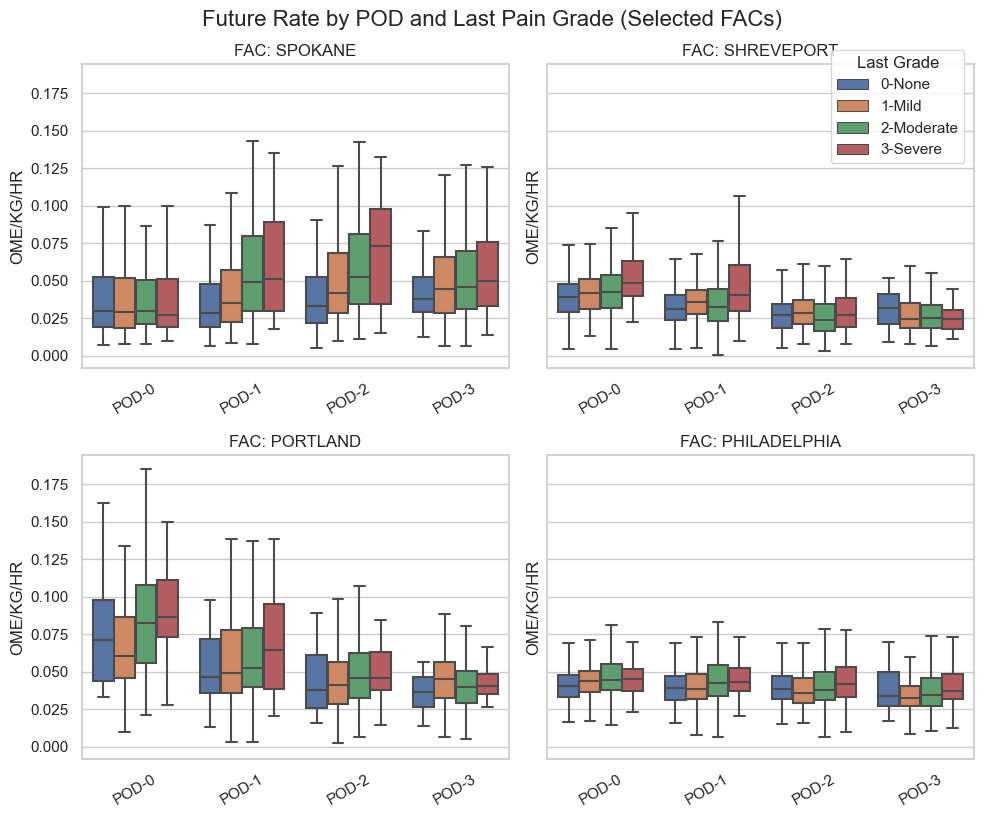

In [22]:

import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the four requested facilities
facilities_to_plot = ["SPOKANE", "SHREVEPORT", "PORTLAND", "PHILADELPHIA"]
df_filtered = df[df['FAC'].isin(facilities_to_plot)]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

legend_handles, legend_labels = None, None

# Plot each FAC
for i, fac in enumerate(facilities_to_plot):
    ax = axes[i]
    sub_df = df_filtered[df_filtered['FAC'] == fac]
    sns.boxplot(
        data=sub_df,
        x='POD',
        y='FUTURE_RATE',
        hue='LAST_GRADE',
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'FAC: {fac}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR')
    ax.tick_params(axis='x', rotation=30)

    # Capture legend from first plot
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove subplot legend
    if ax.get_legend():
        ax.get_legend().remove()

# Remove any unused axes (not needed here since we have exactly 4)
# Add consolidated legend
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='Last Grade',
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade (Selected FACs)', fontsize=16, y=1.02)

# Optional: Save figure
plt.savefig('future_rate_facets_2x2.png', dpi=300, bbox_inches='tight')
plt.show()


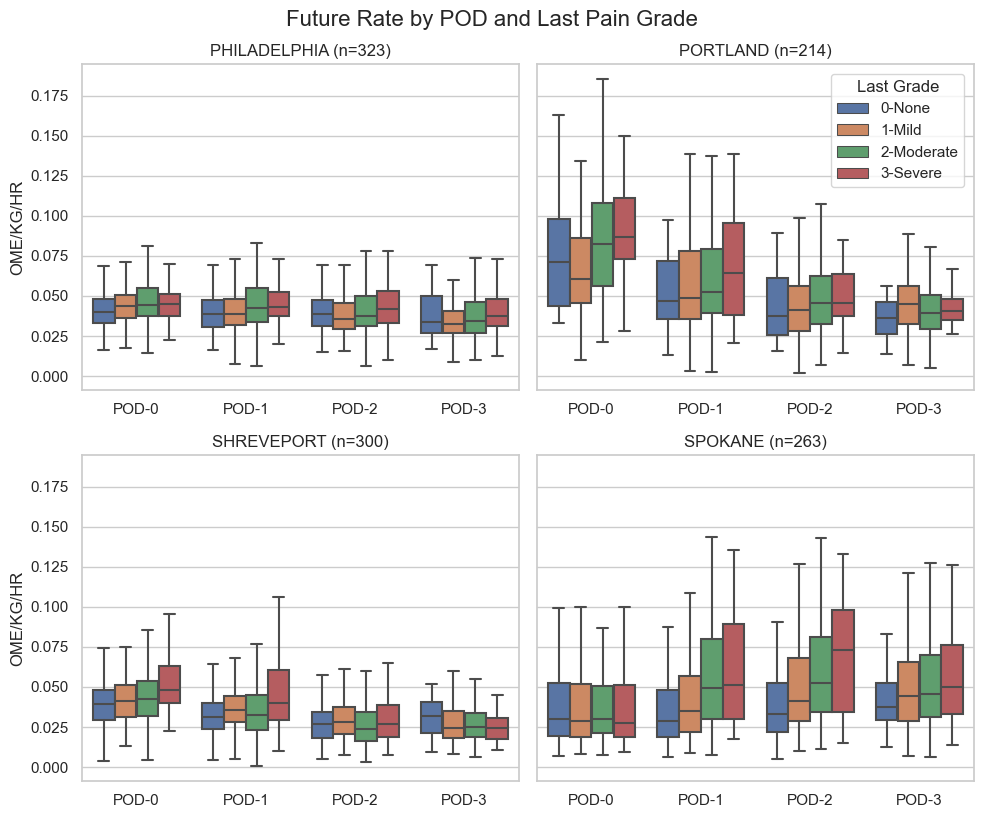

In [34]:

import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the four requested facilities
facilities_to_plot = ["PHILADELPHIA","PORTLAND","SHREVEPORT","SPOKANE"]


case_counts = {
   
    "PHILADELPHIA": 323,
    "PORTLAND": 214,
    "SHREVEPORT": 300,
    "SPOKANE": 263
}

df_filtered = df[df['FAC'].isin(facilities_to_plot)]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

legend_handles, legend_labels = None, None

# Plot each FAC
for i, fac in enumerate(facilities_to_plot):
    ax = axes[i]
    sub_df = df_filtered[df_filtered['FAC'] == fac]
    sns.boxplot(
        data=sub_df,
        x='POD',
        y='FUTURE_RATE',
        hue='LAST_GRADE',
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'{fac} (n={case_counts[fac]})')
    ax.set_xlabel('')
    
    if i in (1, 3):
        ax.set_ylabel('')
    else:
        ax.set_ylabel('OME/KG/HR')

    ax.tick_params(axis='x', rotation=0)

    # Capture legend from first plot
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove subplot legend
    if ax.get_legend():
        ax.get_legend().remove()

# Remove any unused axes (not needed here since we have exactly 4)
# Add consolidated legend
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='Last Grade',
    loc='upper right',
    bbox_to_anchor=(0.98, 0.95)
)

plt.tight_layout()
plt.suptitle('Future Rate by POD and Last Pain Grade', fontsize=16, y=1.02)

# Optional: Save figure
plt.savefig('future_rate_facets_2x2.png', dpi=300, bbox_inches='tight')
plt.show()


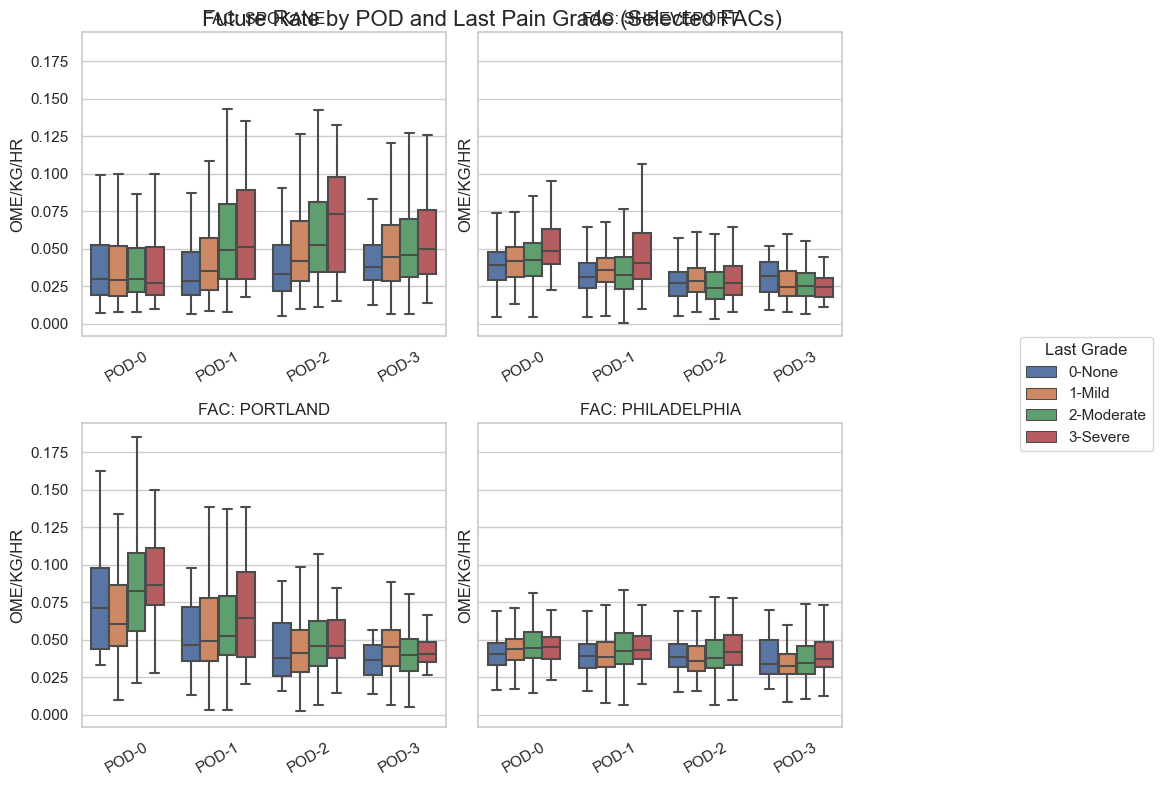

In [23]:

import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the four requested facilities
facilities_to_plot = ["SPOKANE", "SHREVEPORT", "PORTLAND", "PHILADELPHIA"]
df_filtered = df[df['FAC'].isin(facilities_to_plot)]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

legend_handles, legend_labels = None, None

# Plot each FAC
for i, fac in enumerate(facilities_to_plot):
    ax = axes[i]
    sub_df = df_filtered[df_filtered['FAC'] == fac]
    sns.boxplot(
        data=sub_df,
        x='POD',
        y='FUTURE_RATE',
        hue='LAST_GRADE',
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'FAC: {fac}')
    ax.set_xlabel('')
    ax.set_ylabel('OME/KG/HR')
    ax.tick_params(axis='x', rotation=30)

    # Capture legend from first plot
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove subplot legend
    if ax.get_legend():
        ax.get_legend().remove()

# Remove any unused axes (not needed here since we have exactly 4)
# Consolidated legend OUTSIDE on the right
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='Last Grade',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),   # to the right of the figure, vertically centered
    frameon=True
)

# Make room on the right for the legend
plt.tight_layout()
plt.subplots_adjust(right=0.85)   # reduce to create more right margin
fig.suptitle('Future Rate by POD and Last Pain Grade (Selected FACs)', fontsize=16, y=0.98)
# Optional: Save figure
plt.savefig('future_rate_facets_2x2.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:

# ... your plotting loop above ...

# Consolidated legend OUTSIDE on the right
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='Last Grade',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),   # to the right of the figure, vertically centered
    frameon=True
)

# Make room on the right for the legend
plt.tight_layout()
plt.subplots_adjust(right=0.85)   # reduce to create more right margin
fig.suptitle('Future Rate by POD and Last Pain Grade (Selected FACs)', fontsize=16, y=0.98)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           38806 non-null  int64   
 1   POH           38806 non-null  float64 
 2   FUTURE_RATE   38806 non-null  float64 
 3   LAST_SCORE    38806 non-null  category
 4   LAST_GRADE    38806 non-null  category
 5   RUNNING_RATE  38806 non-null  float64 
 6   GROUP         38806 non-null  object  
 7   TYPE          38806 non-null  object  
 8   YEAR          38806 non-null  int64   
 9   FAC           38806 non-null  object  
 10  SEX           38806 non-null  object  
 11  RACE          38806 non-null  object  
 12  AGE           38806 non-null  float64 
 13  BMI           38806 non-null  float64 
 14  HW            38806 non-null  float64 
 15  ASA           38806 non-null  int64   
 16  DSCPOH        38806 non-null  float64 
 17  POH_int       38806 non-null  int32   
 18  POD   

In [25]:
# Step 1: Identify PCA type per row (assuming 'GROUP' indicates PCA drug)
# You may need to adjust this if PCA drug is stored elsewhere
df['PCA_drug'] = df['TYPE'].str.lower().str.extract(r'(morphine|hydromorphone)')

# Step 2: Determine PCA type per facility
fac_pca_map = (
    df.dropna(subset=['PCA_drug'])  # exclude rows without PCA drug info
      .groupby('FAC')['PCA_drug']
      .agg(lambda x: 'mixed' if set(x) == {'morphine', 'hydromorphone'} else x.iloc[0])
)

# Step 3: Map back to full DataFrame
df['FAC_PCA_TYPE'] = df['FAC'].map(fac_pca_map)


In [26]:
df['FAC_PCA_TYPE'].value_counts()

FAC_PCA_TYPE
mixed            23019
morphine          5635
hydromorphone     3893
Name: count, dtype: int64

In [27]:
df['TYPE'].value_counts()

TYPE
1-Morphine-PCA         18470
2-Hydromorphone-PCA    13600
3-Epi (w/Opioid)        5956
4-Block w/Opioid         780
Name: count, dtype: int64

In [28]:
# Define PCA-only subset
pca_df = df[~df['TYPE'].str.contains('epidural|block', case=False, na=False)]


In [30]:
# Drop rows with missing PCA drug or FAC_PCA_TYPE
pca_df_clean = pca_df.dropna(subset=['PCA_drug', 'FAC_PCA_TYPE'])

# Check value counts for FAC_PCA_TYPE
print(pca_df_clean['FAC_PCA_TYPE'].value_counts())


FAC_PCA_TYPE
mixed            23019
morphine          5635
hydromorphone     3416
Name: count, dtype: int64


In [31]:
pca_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32070 entries, 24 to 38805
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           32070 non-null  int64   
 1   POH           32070 non-null  float64 
 2   FUTURE_RATE   32070 non-null  float64 
 3   LAST_SCORE    32070 non-null  category
 4   LAST_GRADE    32070 non-null  category
 5   RUNNING_RATE  32070 non-null  float64 
 6   GROUP         32070 non-null  object  
 7   TYPE          32070 non-null  object  
 8   YEAR          32070 non-null  int64   
 9   FAC           32070 non-null  object  
 10  SEX           32070 non-null  object  
 11  RACE          32070 non-null  object  
 12  AGE           32070 non-null  float64 
 13  BMI           32070 non-null  float64 
 14  HW            32070 non-null  float64 
 15  ASA           32070 non-null  int64   
 16  DSCPOH        32070 non-null  float64 
 17  POH_int       32070 non-null  int32   
 18  POD       

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   EID                  38806 non-null  int64   
 1   POH                  38806 non-null  float64 
 2   Future Rate          38806 non-null  float64 
 3   Last Score Pulldown  38806 non-null  int64   
 4   Last Grade Pulldown  38806 non-null  category
 5   GROUP                38806 non-null  object  
 6   TYPE                 38806 non-null  object  
 7   YEAR                 38806 non-null  int64   
 8   FAC                  38806 non-null  object  
 9   SEX                  38806 non-null  object  
 10  RACE                 38806 non-null  object  
 11  AGE                  38806 non-null  float64 
 12  BMI                  38806 non-null  float64 
 13  HW                   38806 non-null  float64 
 14  ASA                  38806 non-null  int64   
 15  DSCPOH             

In [32]:
print(pca_df_clean['TYPE'].value_counts())

TYPE
1-Morphine-PCA         18470
2-Hydromorphone-PCA    13600
Name: count, dtype: int64


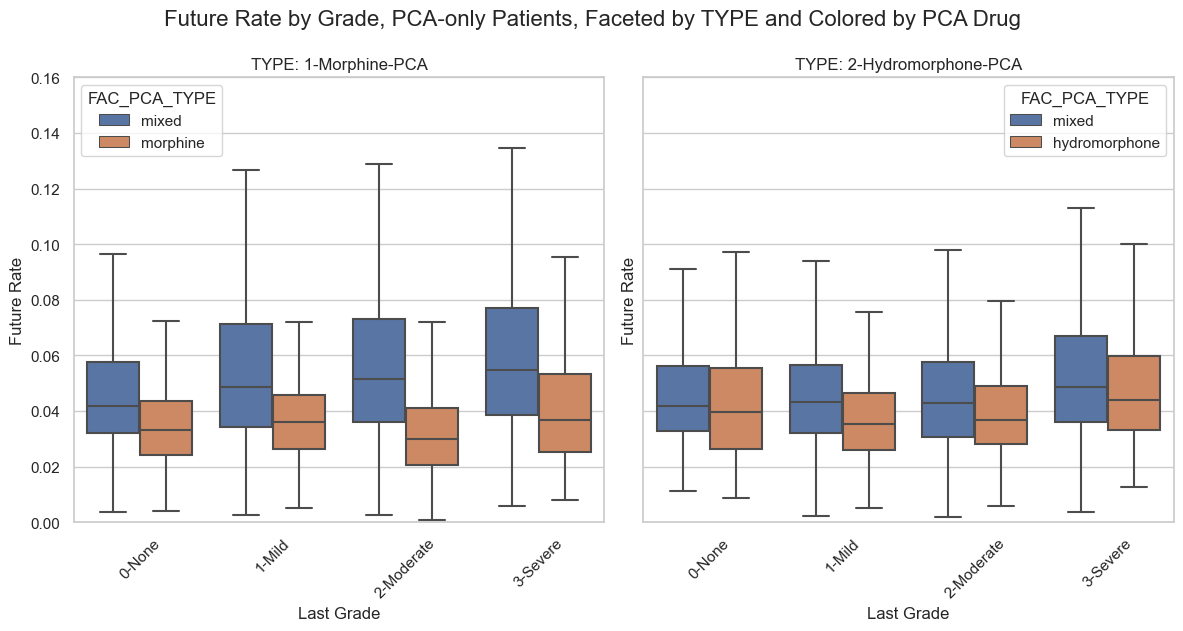

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use cleaned PCA-only data
types = pca_df_clean['TYPE'].unique()

# Set up subplot grid
fig, axes = plt.subplots(1, len(types), figsize=(6 * len(types), 6), sharey=True)

# Ensure axes is iterable
if len(types) == 1:
    axes = [axes]

# Plot each TYPE
for i, t in enumerate(types):
    subset = pca_df_clean[pca_df_clean['TYPE'] == t]
    if subset.empty:
        continue

    ax = axes[i]
    sns.boxplot(
        data=subset,
        x='LAST_GRADE',
        y='FUTURE_RATE',
        hue='FAC_PCA_TYPE',
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'TYPE: {t}')
    ax.set_xlabel('Last Grade')
    ax.set_ylabel('Future Rate')
    ax.set_ylim(0, 0.16)
    ax.tick_params(axis='x', rotation=45)

    # ✅ Keep subplot legend — do NOT remove it

# ❌ Remove global legend — comment out or delete this line
# fig.legend(...)

plt.tight_layout()
plt.suptitle('Future Rate by Grade, PCA-only Patients, Faceted by TYPE and Colored by PCA Drug', fontsize=16, y=1.05)
plt.show()


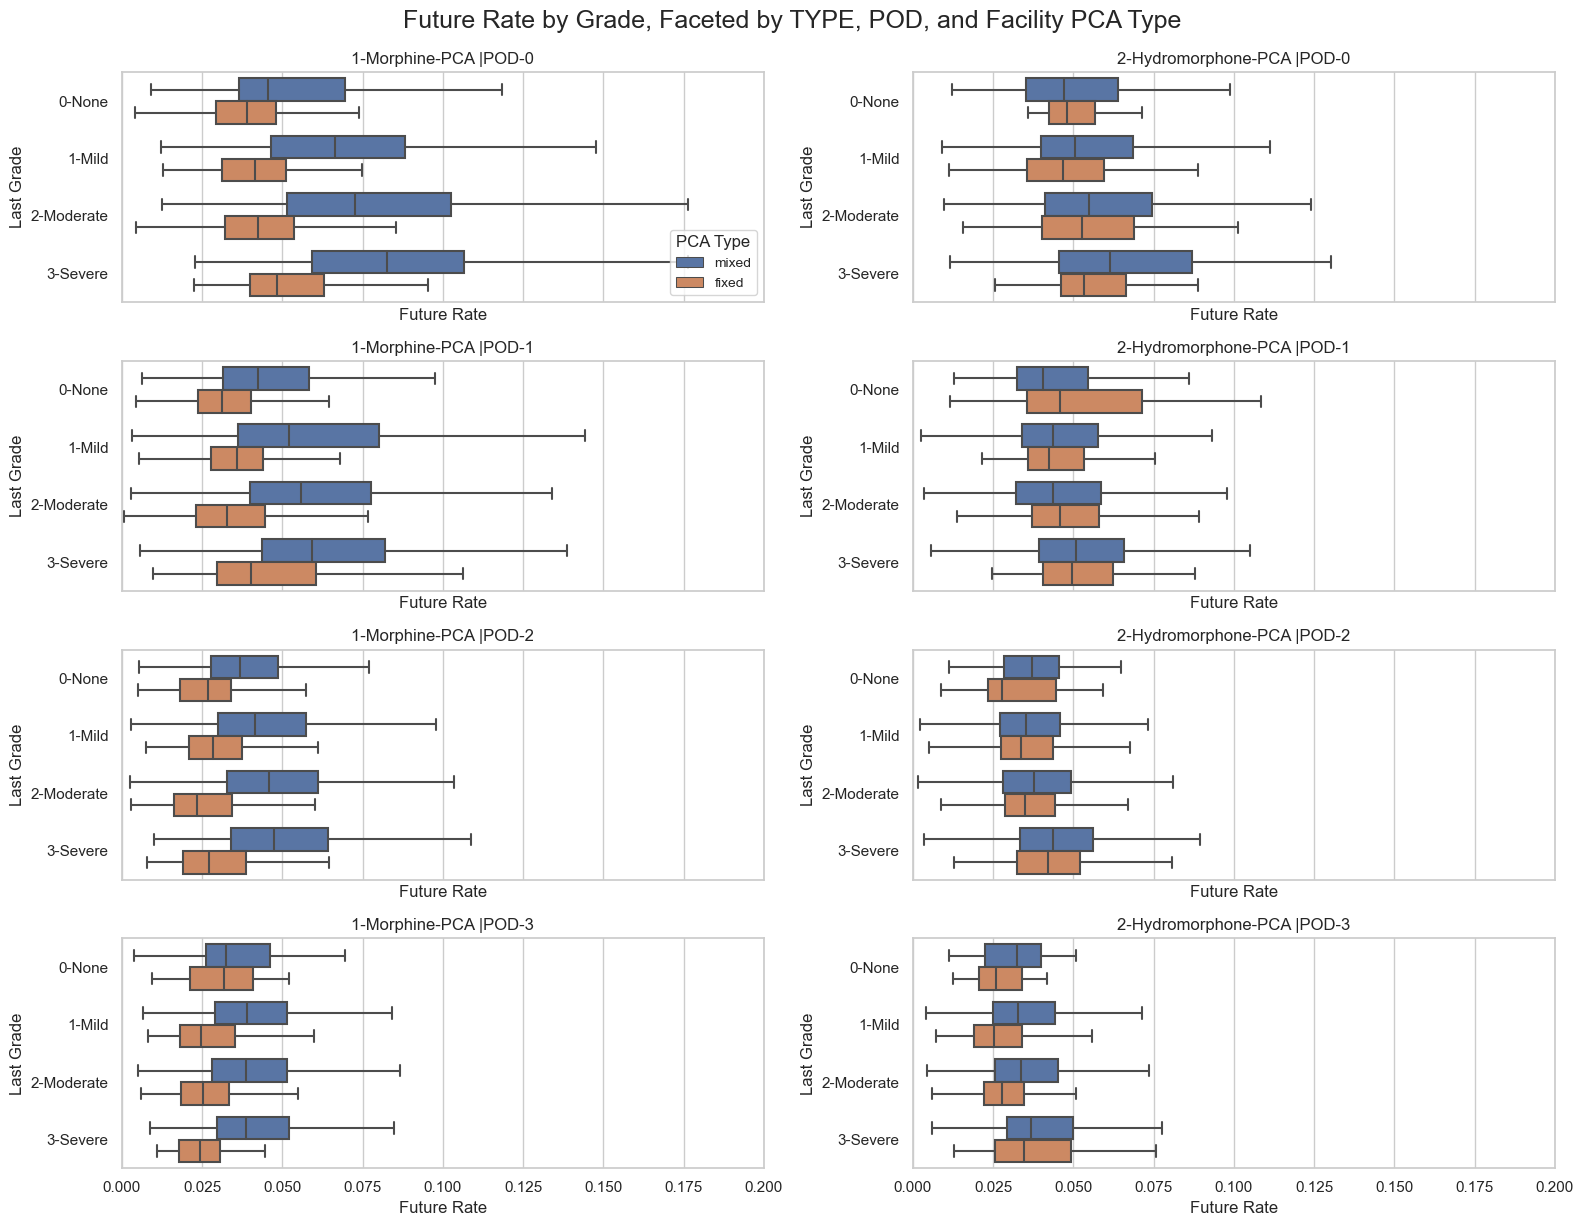

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define types and sorted PODs
types = ['1-Morphine-PCA', '2-Hydromorphone-PCA']
pods = sorted(pca_df_clean['POD'].unique())

# Set up 4 rows × 2 columns
fig, axes = plt.subplots(len(pods), len(types), figsize=(16, 12), sharex=True)

# Plot each POD × TYPE
# Plot each POD × TYPE
for row_idx, pod in enumerate(pods):
    for col_idx, t in enumerate(types):
        subset = pca_df_clean[(pca_df_clean['TYPE'] == t) & (pca_df_clean['POD'] == pod)]
        ax = axes[row_idx, col_idx]

        if subset.empty:
            ax.set_visible(False)
            continue

        sns.boxplot(
            data=subset,
            y='LAST_GRADE',
            x='FUTURE_RATE',
            hue='FAC_PCA_TYPE',
            showfliers=False,
            ax=ax
        )
        ax.set_title(f'{t} |{pod}')
        ax.set_xlabel('Future Rate')
        ax.set_ylabel('Last Grade')
        ax.set_xlim(0, 0.2)
        ax.tick_params(axis='y', rotation=0)

        # ✅ Show legend only in upper-left subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='lower right', fontsize='small', title='PCA Type')
        else:
            ax.legend_.remove()

plt.tight_layout()
plt.suptitle('Future Rate by Grade, Faceted by TYPE, POD, and Facility PCA Type', fontsize=18, y=1.02)
plt.show()


In [39]:
# Recode FAC_PCA_TYPE to 'fixed' or 'mixed'
pca_df_clean['FAC_PCA_TYPE'] = pca_df_clean['FAC_PCA_TYPE'].replace({
    'morphine': 'fixed',
    'hydromorphone': 'fixed'
})


C:\Users\kryan\AppData\Local\Temp\ipykernel_50124\1031752380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_df_clean['FAC_PCA_TYPE'] = pca_df_clean['FAC_PCA_TYPE'].replace({


In [10]:
import numpy as np

df['POH_INT'] = np.where(df['POH'] == 88, 87, np.floor(df['POH']).astype(int))


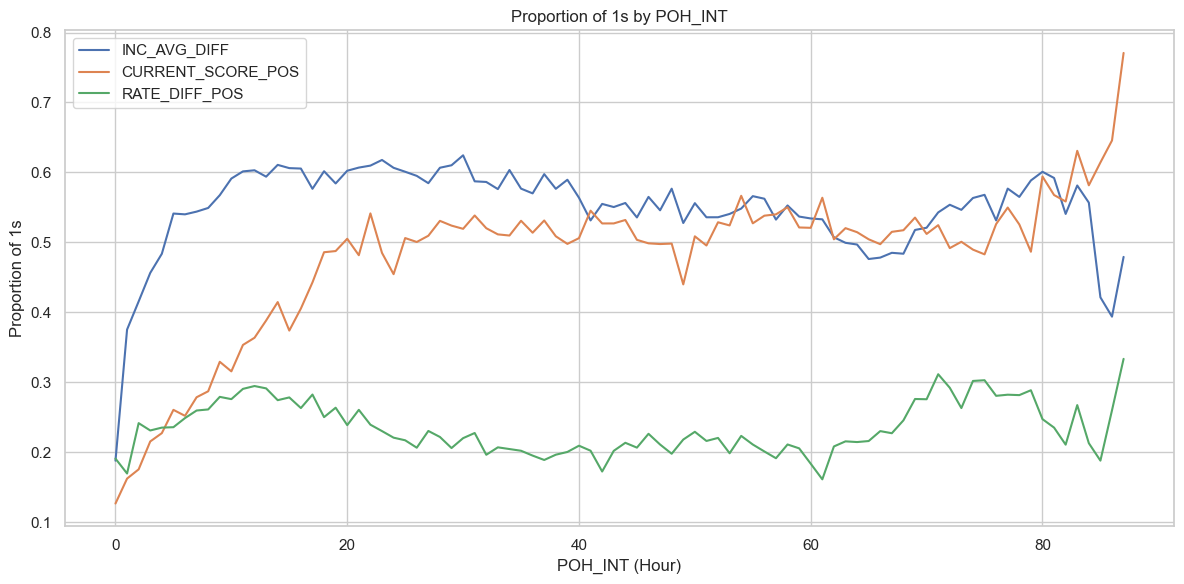

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by POH_INT and calculate mean (proportion of 1s)
prop_df = df.groupby('POH_INT')[['INC_AVG_DIFF', 'CURRENT_SCORE_POS', 'RATE_DIFF_POS']].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=prop_df, x='POH_INT', y='INC_AVG_DIFF', label='INC_AVG_DIFF')
sns.lineplot(data=prop_df, x='POH_INT', y='CURRENT_SCORE_POS', label='CURRENT_SCORE_POS')
sns.lineplot(data=prop_df, x='POH_INT', y='RATE_DIFF_POS', label='RATE_DIFF_POS')

plt.title('Proportion of 1s by POH_INT')
plt.xlabel('POH_INT (Hour)')
plt.ylabel('Proportion of 1s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


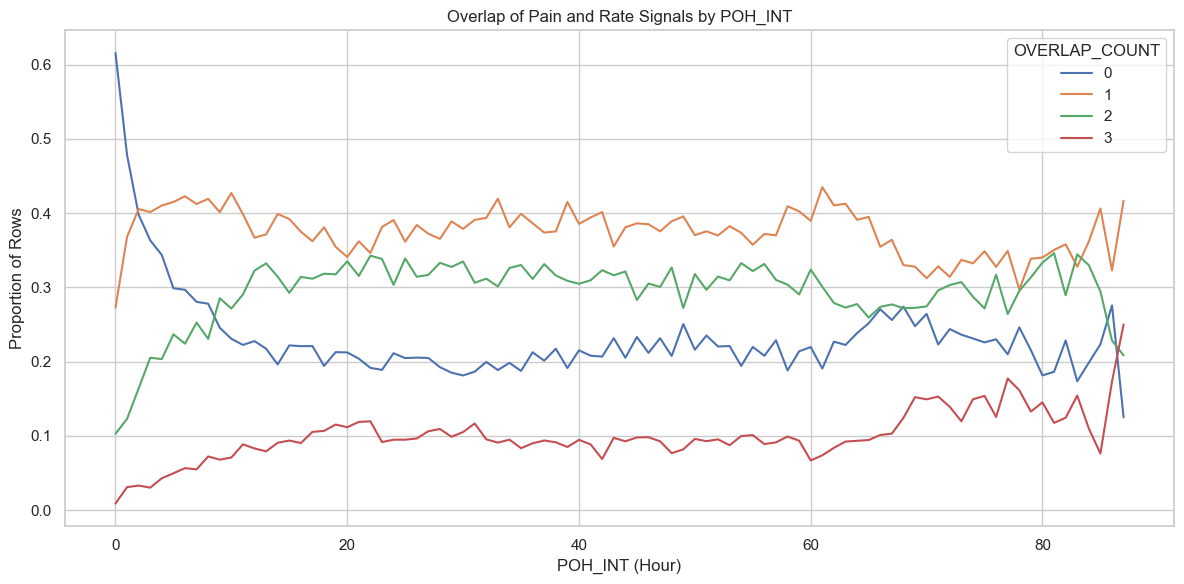

In [13]:
df['OVERLAP_COUNT'] = df[['INC_AVG_DIFF', 'CURRENT_SCORE_POS', 'RATE_DIFF_POS']].sum(axis=1)
overlap_df = df.groupby(['POH_INT', 'OVERLAP_COUNT']).size().unstack(fill_value=0)
overlap_prop = overlap_df.div(overlap_df.sum(axis=1), axis=0)
overlap_prop.plot(kind='line', figsize=(12, 6), title='Overlap of Pain and Rate Signals by POH_INT')
plt.xlabel('POH_INT (Hour)')
plt.ylabel('Proportion of Rows')
plt.grid(True)
plt.tight_layout()
plt.show()



In [14]:
df['OVERLAP_COUNT'] = df[['INC_AVG_DIFF', 'CURRENT_SCORE_POS', 'RATE_DIFF_POS']].sum(axis=1)

grouped = df.groupby(['TYPE', 'POH_INT', 'OVERLAP_COUNT']).size().reset_index(name='count')

total_counts = grouped.groupby(['TYPE', 'POH_INT'])['count'].transform('sum')
grouped['proportion'] = grouped['count'] / total_counts





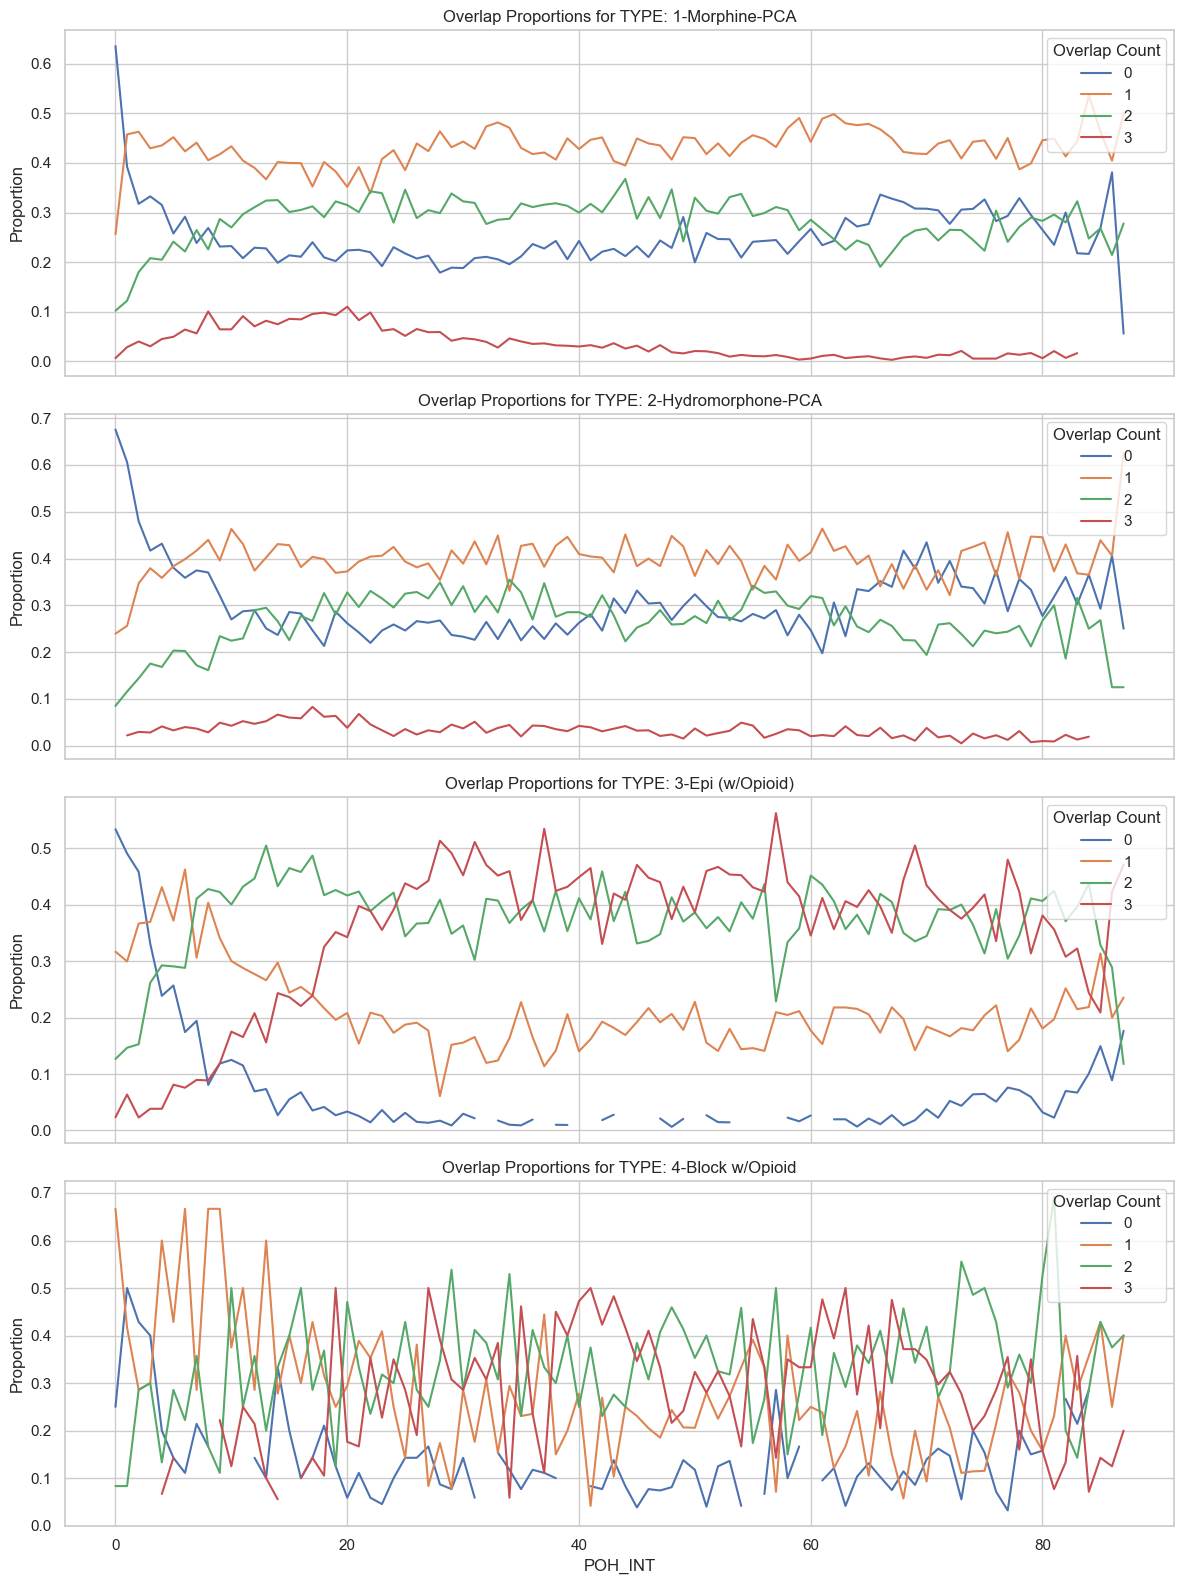

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create OVERLAP_COUNT
df['OVERLAP_COUNT'] = df[['INC_AVG_DIFF', 'CURRENT_SCORE_POS', 'RATE_DIFF_POS']].sum(axis=1)

# Group and normalize
grouped = df.groupby(['TYPE', 'POH_INT', 'OVERLAP_COUNT']).size().reset_index(name='count')
grouped['total'] = grouped.groupby(['TYPE', 'POH_INT'])['count'].transform('sum')
grouped['proportion'] = grouped['count'] / grouped['total']

# Pivot for plotting
pivot = grouped.pivot_table(index='POH_INT', columns='OVERLAP_COUNT', values='proportion', aggfunc='first')
types = grouped['TYPE'].unique()

# Plot subplots
fig, axes = plt.subplots(nrows=len(types), figsize=(12, 4 * len(types)), sharex=True)

for ax, t in zip(axes, types):
    subset = grouped[grouped['TYPE'] == t]
    pivot = subset.pivot_table(index='POH_INT', columns='OVERLAP_COUNT', values='proportion', aggfunc='first')
    pivot.plot(ax=ax)
    ax.set_title(f'Overlap Proportions for TYPE: {t}')
    ax.set_ylabel('Proportion')
    ax.set_xlabel('POH_INT')
    ax.legend(title='Overlap Count', loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()


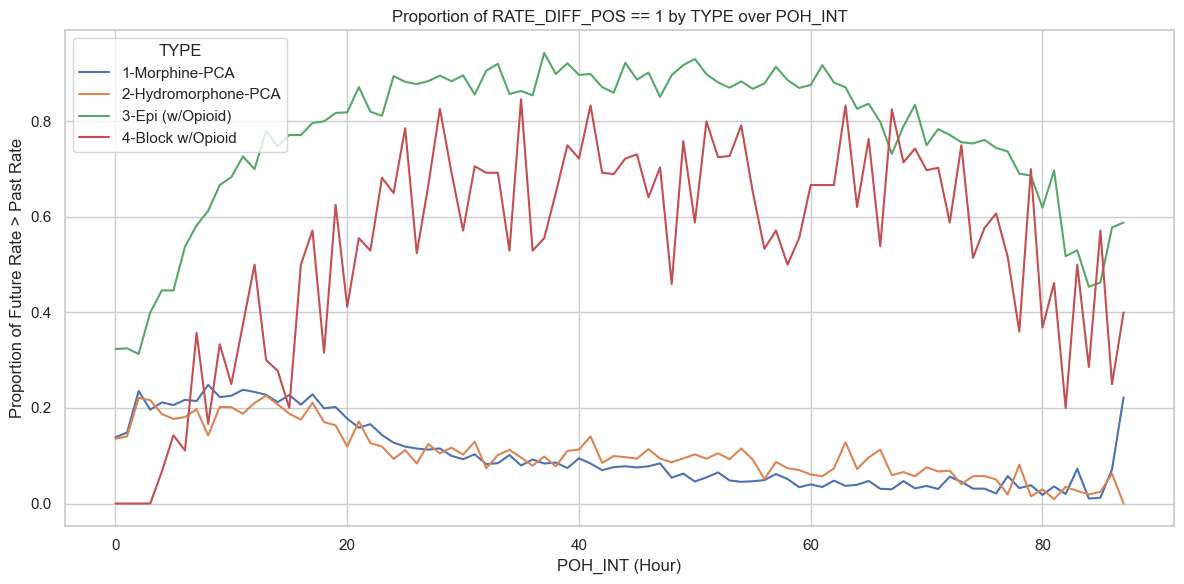

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by TYPE and POH_INT, calculate mean (proportion of 1s)
rate_df = df.groupby(['TYPE', 'POH_INT'])['RATE_DIFF_POS'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=rate_df, x='POH_INT', y='RATE_DIFF_POS', hue='TYPE')
plt.title('Proportion of RATE_DIFF_POS == 1 by TYPE over POH_INT')
plt.xlabel('POH_INT (Hour)')
plt.ylabel('Proportion of Future Rate > Past Rate')
plt.grid(True)
plt.tight_layout()
plt.show()


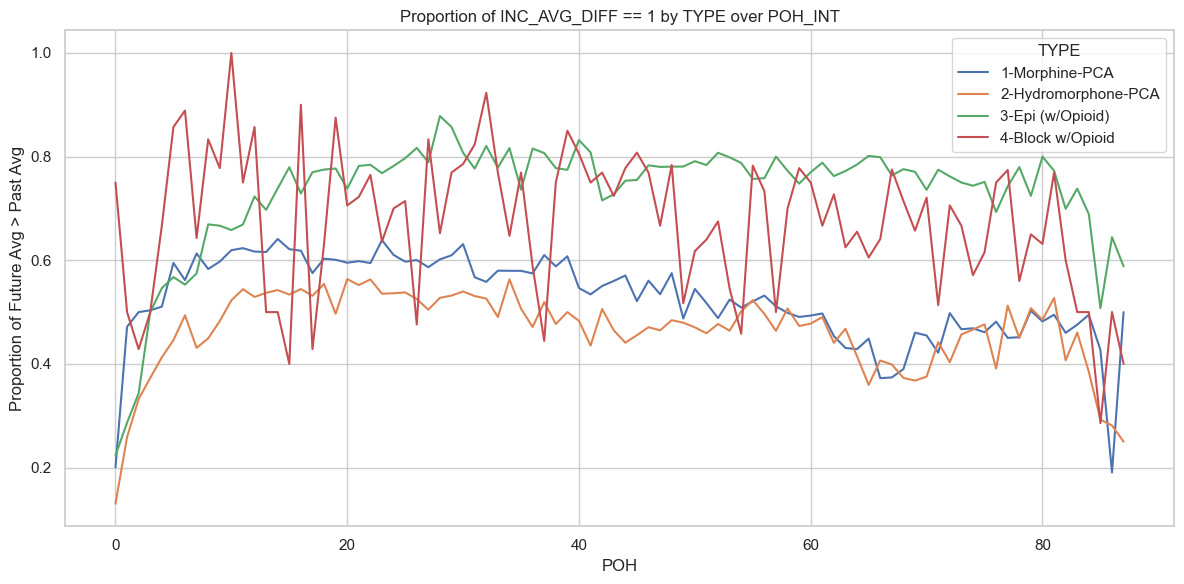

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by TYPE and POH_INT, calculate mean (proportion of 1s)
rate_df = df.groupby(['TYPE', 'POH_INT'])['INC_AVG_DIFF'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=rate_df, x='POH_INT', y='INC_AVG_DIFF', hue='TYPE')
plt.title('Proportion of INC_AVG_DIFF == 1 by TYPE over POH_INT')
plt.xlabel('POH')
plt.ylabel('Proportion of Future Avg > Past Avg')
plt.grid(True)
plt.tight_layout()
plt.show()


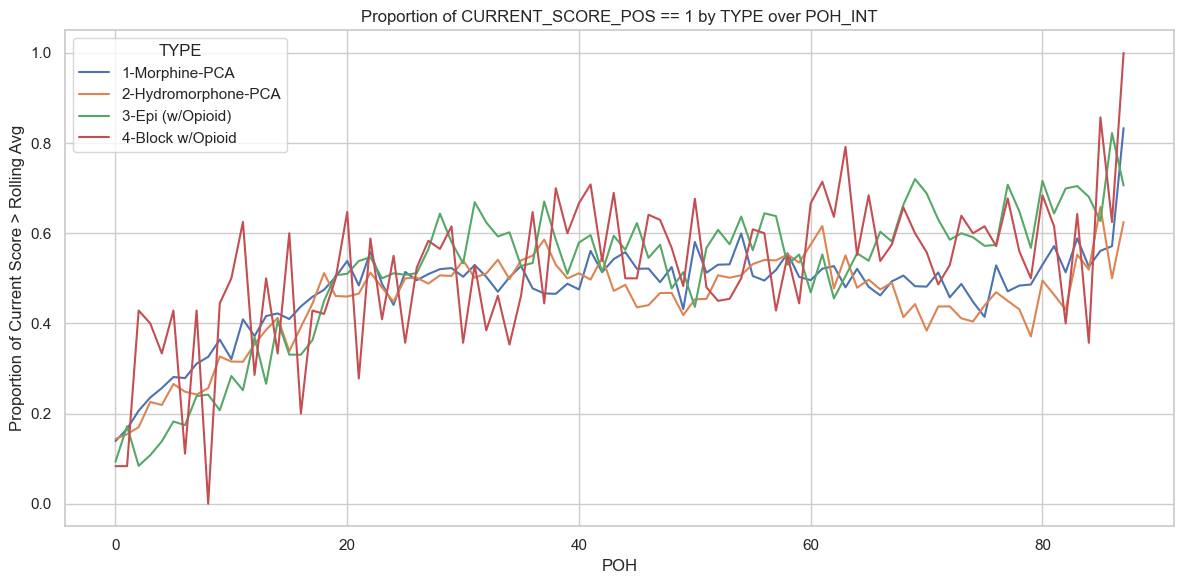

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by TYPE and POH_INT, calculate mean (proportion of 1s)
rate_df = df.groupby(['TYPE', 'POH_INT'])['CURRENT_SCORE_POS'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=rate_df, x='POH_INT', y='CURRENT_SCORE_POS', hue='TYPE')
plt.title('Proportion of CURRENT_SCORE_POS == 1 by TYPE over POH_INT')
plt.xlabel('POH')
plt.ylabel('Proportion of Current Score > Rolling Avg')
plt.grid(True)
plt.tight_layout()
plt.show()


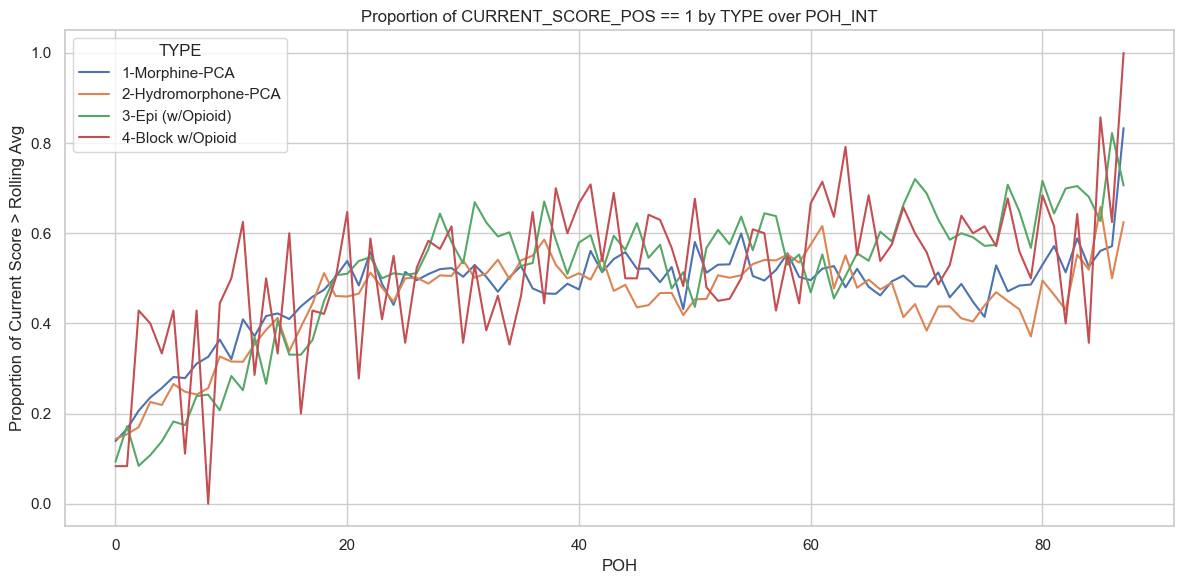

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by TYPE and POH_INT, calculate mean (proportion of 1s)
rate_df = df.groupby(['TYPE', 'POH_INT'])['CURRENT_SCORE_POS'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=rate_df, x='POH_INT', y='CURRENT_SCORE_POS', hue='TYPE')
plt.title('Proportion of CURRENT_SCORE_POS == 1 by TYPE over POH_INT')
plt.xlabel('POH')
plt.ylabel('Proportion of Current Score > Rolling Avg')
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75562 entries, 0 to 75561
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EID                         75562 non-null  int64  
 1   POH                         75562 non-null  float64
 2   COVERAGE RATIO              75562 non-null  float64
 3   ROLLING AVG SCORE           75562 non-null  float64
 4   FUTURE AVG                  75562 non-null  float64
 5   ROLL_FUT_AVG_DIFF           75562 non-null  float64
 6   CURRENT SCORE_VS_ROLL_DIFF  75562 non-null  float64
 7   RUNNING RATE2               75562 non-null  float64
 8   FUTURE RATE3                75562 non-null  float64
 9   RATE DIFF4                  75562 non-null  float64
 10  INC_AVG_DIFF                75562 non-null  int64  
 11  CURRENT_SCORE_POS           75562 non-null  int64  
 12  RATE_DIFF_POS               75562 non-null  int64  
 13  GROUP                       755

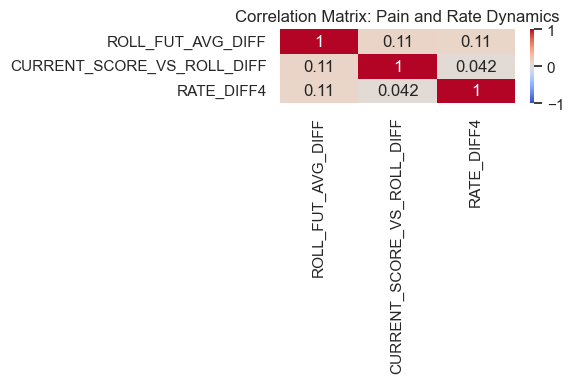

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns by index
cols = df.iloc[:, [5, 6, 9]]
cols.columns = ['ROLL_FUT_AVG_DIFF', 'CURRENT_SCORE_VS_ROLL_DIFF', 'RATE_DIFF4']

# Compute correlation matrix
corr = cols.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Pain and Rate Dynamics')
plt.tight_layout()
plt.show()


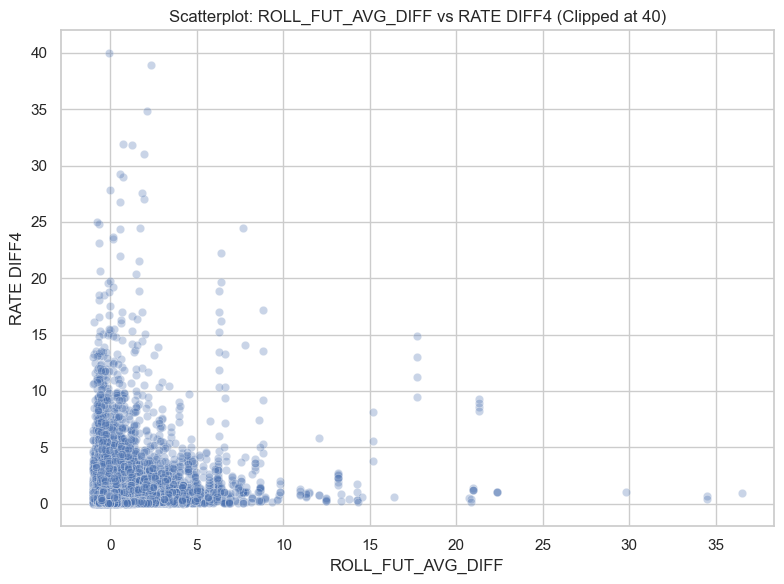

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
filtered_df = df[df.iloc[:, 10] == 1]

# Select and rename columns
x = filtered_df.iloc[:, 5]  # ROLL_FUT_AVG_DIFF
y = filtered_df.iloc[:, 9]  # RATE DIFF4


# Filter out outliers
mask = (x <= 40) & (y <= 40)
x_clipped = x[mask]
y_clipped = y[mask]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_clipped, y=x_clipped, alpha=0.3, )
plt.title('Scatterplot: ROLL_FUT_AVG_DIFF vs RATE DIFF4 (Clipped at 40)')
plt.xlabel('ROLL_FUT_AVG_DIFF')
plt.ylabel('RATE DIFF4')
plt.grid(True)
plt.tight_layout()
plt.show()


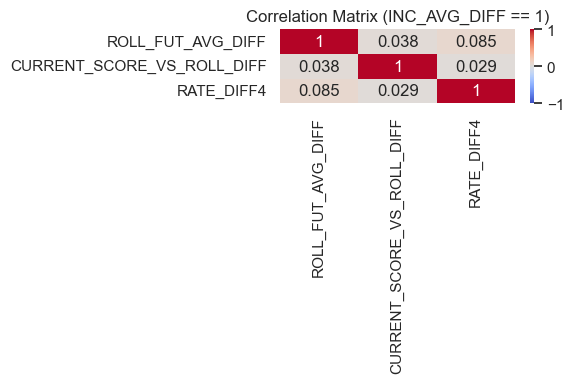

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter rows where INC_AVG_DIFF == 1
filtered_df = df[df.iloc[:, 10] == 1]

# Select relevant columns
subset = filtered_df.iloc[:, [5, 6, 9]]
subset.columns = ['ROLL_FUT_AVG_DIFF', 'CURRENT_SCORE_VS_ROLL_DIFF', 'RATE_DIFF4']

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (INC_AVG_DIFF == 1)')
plt.tight_layout()
plt.show()


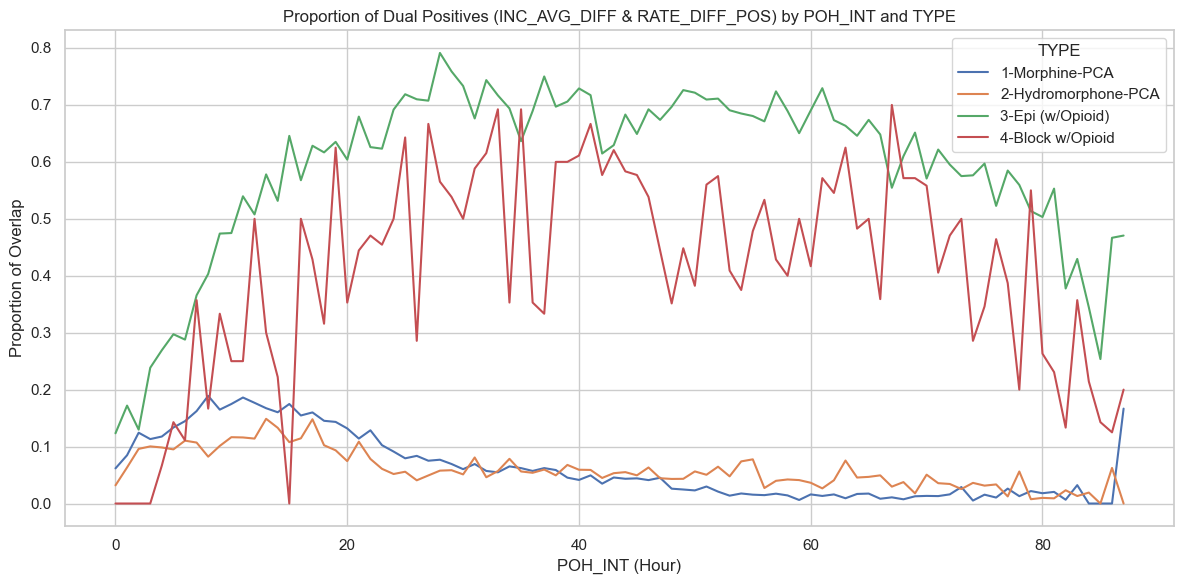

In [30]:
df['DUAL_POSITIVE'] = ((df.iloc[:, 10] == 1) & (df.iloc[:, 12] == 1)).astype(int)
dual_df = df.groupby(['POH_INT', 'TYPE'])['DUAL_POSITIVE'].mean().reset_index()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=dual_df, x='POH_INT', y='DUAL_POSITIVE', hue='TYPE')
plt.title('Proportion of Dual Positives (INC_AVG_DIFF & RATE_DIFF_POS) by POH_INT and TYPE')
plt.xlabel('POH_INT (Hour)')
plt.ylabel('Proportion of Overlap')
plt.grid(True)
plt.tight_layout()
plt.show()




In [36]:
# Ensure POH_INT exists
df['POH_INT'] = np.where(df['POH'] == 88, 87, np.floor(df['POH']).astype(int))

# Create DUAL_POSITIVE flag
df['DUAL_POSITIVE'] = ((df['INC_AVG_DIFF'] == 1) & (df['RATE_DIFF_POS'] == 1)).astype(int)

# Aggregate by patient and hour: keep max (1 if any row is 1)
agg_df1 = df.groupby(['EID', 'POH_INT'], as_index=False)['RATE_DIFF_POS'].max()


In [37]:
agg_df1 = agg_df1.merge(df[['EID', 'TYPE']].drop_duplicates(), on='EID', how='left')


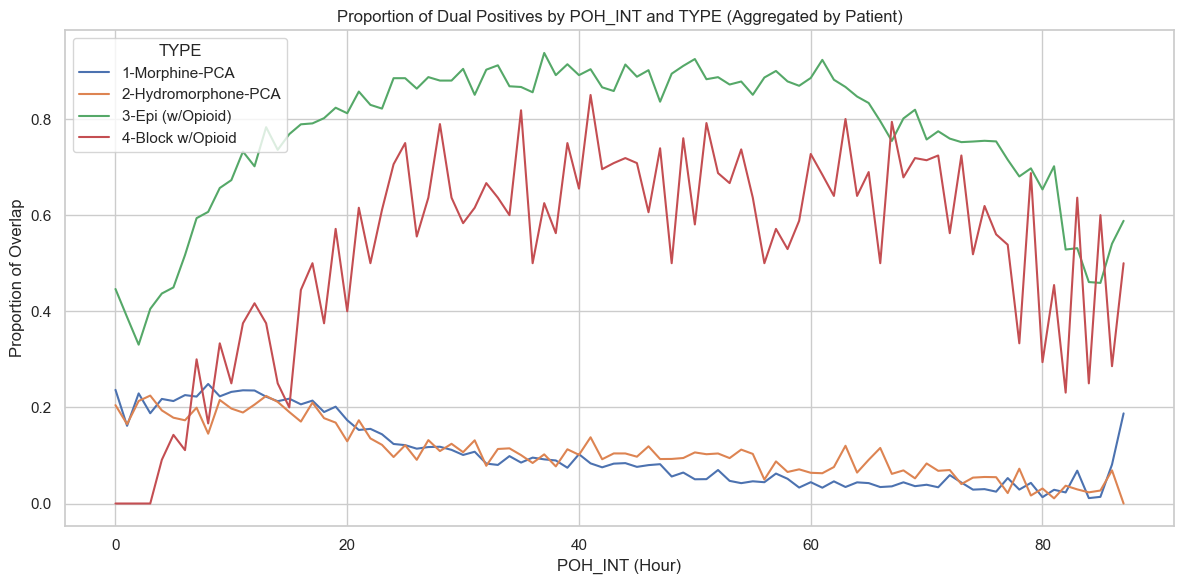

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

type_df = agg_df1.groupby(['POH_INT', 'TYPE'])['RATE_DIFF_POS'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=type_df, x='POH_INT', y='RATE_DIFF_POS', hue='TYPE')
plt.title('Proportion of Dual Positives by POH_INT and TYPE (Aggregated by Patient)')
plt.xlabel('POH_INT (Hour)')
plt.ylabel('Proportion of Overlap')
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
type_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   POH_INT        352 non-null    int32  
 1   TYPE           352 non-null    object 
 2   RATE_DIFF_POS  352 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 7.0+ KB


In [41]:
agg_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65753 entries, 0 to 65752
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   EID            65753 non-null  int64 
 1   POH_INT        65753 non-null  int32 
 2   RATE_DIFF_POS  65753 non-null  int64 
 3   TYPE           65753 non-null  object
dtypes: int32(1), int64(2), object(1)
memory usage: 1.8+ MB


In [49]:

# Batch convert ACS table-based .dat files (pipe-delimited) to .csv
import os
import pandas as pd

DATA_DIR = r"C:\Users\kryan\Downloads\1YRData.zip\data\prt01\prod\sumfile_new\output\2024\1YRData"
OUT_DIR  = os.path.join(DATA_DIR, "csv_out")
os.makedirs(OUT_DIR, exist_ok=True)

for fn in os.listdir(DATA_DIR):
    if not fn.lower().endswith(".dat"):
        continue
    in_path = os.path.join(DATA_DIR, fn)
    print(f"Reading {in_path} ...")

    # Table-based format is pipe-delimited UTF-8 (ACS documentation)
    # Use chunking for large files
    chunks = pd.read_csv(in_path, sep="|", dtype=str, encoding="utf-8", chunksize=250_000)
    df = pd.concat(chunks, ignore_index=True)

    out_path = os.path.join(OUT_DIR, fn.replace(".dat", ".csv"))
    df.to_csv(out_path, index=False)
    print(f"  -> wrote {out_path} ({len(df)} rows)")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\kryan\\Downloads\\1YRData.zip\\data'

In [50]:

# %% [code] ACS table-based .dat → .csv (works with the ZIP you uploaded to Jupyter)
import os, re, zipfile
from pathlib import Path
import pandas as pd

# --------------------
# CONFIG — adjust these if needed
# --------------------
ZIP_NAME = "1YRData.zip"  # the ZIP you uploaded to your Jupyter home
YEAR = 2024               # e.g., 2024 (for your acsdt1y2024-*.dat files)
SPAN = "1YR"              # "1YR" or "5YR"
# Optional: if you also upload Geos file later, set its filename here and turn MERGE_GEOS=True
GEOS_FILENAME = f"Geos{YEAR}{SPAN}.txt"
MERGE_GEOS = False        # set to True once you upload GeosYYYY1YR.txt

# Which tables to consolidate into a single ZCTA-wide CSV (leave empty to skip)
# Example: median household income (B19013); add others if you wish
TABLES_TO_COMBINE = ["B19013"]   # e.g., ["B19013","B17001"] — see note below about poverty rate

# --------------------
# 1) Locate and extract ZIP next to your notebook
# --------------------
home = Path(".").resolve()
zip_path = next((p for p in home.glob("*.zip") if p.name == ZIP_NAME), None)
if zip_path is None:
    raise FileNotFoundError(f"Could not find {ZIP_NAME} in {home}")

extract_dir = home / f"acs_{YEAR}_{SPAN}_extracted"
extract_dir.mkdir(exist_ok=True)

print(f"Extracting {zip_path} to {extract_dir} ...")
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

# --------------------
# 2) Find all .dat files (pipe-delimited) within the extracted tree and convert to CSV
# --------------------
csv_out_dir = extract_dir / "csv_out"
csv_out_dir.mkdir(exist_ok=True)

dat_files = list(extract_dir.rglob("*.dat"))
if not dat_files:
    raise FileNotFoundError("No .dat files found after extraction. Check ZIP content or path.")

def read_table_based_dat_to_df(dat_path: Path) -> pd.DataFrame:
    """ACS table-based .dat is pipe-delimited UTF-8; read with pandas."""
    # For very large files you could use chunksize; here we load whole file for simplicity
    return pd.read_csv(dat_path, sep="|", dtype=str, encoding="utf-8")

print(f"Converting {len(dat_files)} .dat files to CSV ...")
for dat in dat_files:
    try:
        df = read_table_based_dat_to_df(dat)
        out_csv = csv_out_dir / (dat.stem + ".csv")
        df.to_csv(out_csv, index=False)
        print(f"  ✓ {dat.name} -> {out_csv.name} ({len(df)} rows)")
    except Exception as e:
        print(f"  ✗ Failed on {dat.name}: {e}")

# --------------------
# 3) (Optional) Merge geography NAME labels if Geos file is present and MERGE_GEOS=True
# --------------------
if MERGE_GEOS:
    geos_path = next(extract_dir.glob(f"**/{GEOS_FILENAME}"), None)
    if geos_path is None:
        print(f"Geos file {GEOS_FILENAME} not found in extracted folders; skipping label merge.")
    else:
        print(f"Merging geography labels from {geos_path.name} ...")
        geos = pd.read_csv(geos_path, sep="|", dtype=str, encoding="utf-8")
        keep_cols = [c for c in geos.columns if c.upper() in {"GEOID","NAME","SUMLEVEL","LOGRECNO"}]
        geos = geos[keep_cols] if keep_cols else geos

        labeled_dir = extract_dir / "csv_labeled"
        labeled_dir.mkdir(exist_ok=True)

        for csv_file in csv_out_dir.glob("*.csv"):
            df = pd.read_csv(csv_file, dtype=str)
            if "GEOID" in df.columns and "GEOID" in geos.columns:
                df = df.merge(geos, on="GEOID", how="left")
            df.to_csv(labeled_dir / csv_file.name, index=False)
        print("  ✓ Labeled CSVs written.")

# --------------------
# 4) Filter to ZCTAs (ZIP-like geographies) and compute ZCTA5
#    ZCTAs appear with GEOID starting with '8600000US' in table-based files.
# --------------------
def filter_to_zcta(df: pd.DataFrame) -> pd.DataFrame:
    if "GEOID" not in df.columns:
        return df.copy()
    z = df[df["GEOID"].str.startswith("8600000US", na=False)].copy()
    z["ZCTA5"] = z["GEOID"].str.replace("8600000US", "", regex=False)
    return z

zcta_dir = extract_dir / "csv_zcta"
zcta_dir.mkdir(exist_ok=True)

print("Filtering converted CSVs to ZCTA rows ...")
for csv_file in csv_out_dir.glob("*.csv"):
    df = pd.read_csv(csv_file, dtype=str)
    z = filter_to_zcta(df)
    out_zcta_csv = zcta_dir / csv_file.name.replace(".csv", "_ZCTA.csv")
    z.to_csv(out_zcta_csv, index=False)
    print(f"  ✓ {csv_file.name} -> {out_zcta_csv.name} ({len(z)} ZCTA rows)")

# --------------------
# 5) (Optional) Build a single consolidated ZCTA-wide CSV for selected tables (e.g., B19013)
# --------------------
def table_id_from_filename(name: str) -> str:
    # filenames look like acsdt1y2024-b19013.dat → 'B19013'
    m = re.search(r"acsdt\dy\d{4}-(b\d{5}[a-z]?)", name, re.I)
    return m.group(1).upper() if m else ""

# By default, keep E001 (estimate) and M001 (MOE) columns for each table
cols_for_table = {
    # Median household income — E001 (estimate), M001 (MOE)
    "B19013": ["B19013_E001", "B19013_M001"],
    # Add more here as needed (ensure columns exist in your files)
    # "B17001": [...]  # Poverty status is a crosstab; deriving "rate" needs table shells to pick the right lines.
}

# Collect ZCTA subsets for requested tables and outer-merge on GEOID
to_merge = []
for zcta_csv in zcta_dir.glob("*.csv"):
    tid = table_id_from_filename(zcta_csv.name.replace("_ZCTA.csv", ".dat"))
    if tid in TABLES_TO_COMBINE:
        df = pd.read_csv(zcta_csv, dtype=str)
        keep = ["GEOID", "ZCTA5", "NAME"] if "NAME" in df.columns else ["GEOID", "ZCTA5"]
        keep += [c for c in cols_for_table.get(tid, []) if c in df.columns]
        df = df[keep].copy()
        to_merge.append(df)

if to_merge:
    print(f"Combining tables into one ZCTA-wide CSV: {TABLES_TO_COMBINE}")
    from functools import reduce
    wide = reduce(lambda left, right: pd.merge(left, right, on=["GEOID","ZCTA5"], how="outer"), to_merge)
    combined_out = extract_dir / f"ZCTA_{YEAR}_{SPAN}_{'-'.join(TABLES_TO_COMBINE)}.csv"
    wide.to_csv(combined_out, index=False)
    print(f"  ✓ wrote {combined_out} ({len(wide)} ZCTAs)")
else:
    print("No tables combined (TABLES_TO_COMBINE empty or matching files not found).")

print("\nDone.\n"
      f"- Raw CSVs:     {csv_out_dir}\n"
      f"- ZCTA CSVs:    {zcta_dir}\n"
      f"- Combined CSV: {combined_out if to_merge else 'n/a'}")


Extracting C:\Users\kryan\1YRData.zip to C:\Users\kryan\acs_2024_1YR_extracted ...
Converting 1440 .dat files to CSV ...
  ✓ acsdt1y2024-b01001.dat -> acsdt1y2024-b01001.csv (8153 rows)
  ✓ acsdt1y2024-b01001a.dat -> acsdt1y2024-b01001a.csv (8082 rows)
  ✓ acsdt1y2024-b01001b.dat -> acsdt1y2024-b01001b.csv (4156 rows)
  ✓ acsdt1y2024-b01001c.dat -> acsdt1y2024-b01001c.csv (993 rows)
  ✓ acsdt1y2024-b01001d.dat -> acsdt1y2024-b01001d.csv (3263 rows)
  ✓ acsdt1y2024-b01001e.dat -> acsdt1y2024-b01001e.csv (218 rows)
  ✓ acsdt1y2024-b01001f.dat -> acsdt1y2024-b01001f.csv (3379 rows)
  ✓ acsdt1y2024-b01001g.dat -> acsdt1y2024-b01001g.csv (6331 rows)
  ✓ acsdt1y2024-b01001h.dat -> acsdt1y2024-b01001h.csv (7871 rows)
  ✓ acsdt1y2024-b01001i.dat -> acsdt1y2024-b01001i.csv (6127 rows)
  ✓ acsdt1y2024-b01002.dat -> acsdt1y2024-b01002.csv (8155 rows)
  ✓ acsdt1y2024-b01002a.dat -> acsdt1y2024-b01002a.csv (8155 rows)
  ✓ acsdt1y2024-b01002b.dat -> acsdt1y2024-b01002b.csv (7843 rows)
  ✓ acsdt1y202

KeyError: "['GEOID', 'ZCTA5'] not in index"

In [51]:

# %% [code] Build a consolidated ZCTA CSV with median income (B19013) + poverty % (B17001)
import os, re, glob
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# CONFIG — adjust if needed
# ----------------------------
YEAR = 2024         # ACS year (e.g., 2024)
SPAN = "1YR"        # "1YR" or "5YR"
# If your files have different names, tweak the patterns below:
SHELLS_GLOB = f"*Table_Shells*.txt"        # e.g., "ACS20241YR_Table_Shells.txt"
GEOS_GLOB   = f"Geos{YEAR}{SPAN}.txt"      # e.g., "Geos20241YR.txt"

# Tables to include
TABLE_INCOME = "B19013"   # median household income
TABLE_POV    = "B17001"   # poverty status (counts)

# ----------------------------
# Helpers
# ----------------------------
def find_one(pattern: str) -> Path:
    """Find first match anywhere below current dir."""
    for p in Path(".").rglob(pattern):
        return p
    return None

def read_table_based_dat(path: Path) -> pd.DataFrame:
    """ACS table-based .dat is pipe-delimited UTF-8."""
    return pd.read_csv(path, sep="|", dtype=str, encoding="utf-8")

def filter_to_zcta(df: pd.DataFrame) -> pd.DataFrame:
    """Keep ZCTAs: GEOID starts with '8600000US'; add ZCTA5."""
    if "GEOID" not in df.columns:
        return df.copy()
    z = df[df["GEOID"].str.startswith("8600000US", na=False)].copy()
    z["ZCTA5"] = z["GEOID"].str.replace("8600000US", "", regex=False)
    return z

def try_read_shells(shells_path: Path) -> pd.DataFrame:
    """
    Read ACS Table Shells. Different years may use tab or pipe delimiters.
    We try tabs first, then pipes, then commas.
    """
    for sep in ["\t", "|", ","]:
        df = pd.read_csv(shells_path, sep=sep, dtype=str, encoding="utf-8", engine="python")
        if df.shape[1] > 1:
            return df
    # Fallback: try parsing lines of 'TABLEID_LINENUM = LABEL'
    rows = []
    with open(shells_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = re.match(r"\s*([A-Z]\d{5})_(\d{3})\s*=\s*(.+)", line.strip())
            if m:
                rows.append({"Table ID": m.group(1), "Line Number": m.group(2), "Label": m.group(3)})
    return pd.DataFrame(rows)

def normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [c.strip() for c in df.columns]
    return df

def get_poverty_lines(shells_df: pd.DataFrame, table_id: str = "B17001"):
    """
    Return:
      - den_line: '001' (Total for whom poverty status is determined), if present
      - below_lines: list of line numbers (strings like '002', '003', ...) whose Label contains 'Below poverty level'
    Works across different shell schemas by looking for columns that contain Table ID, Line Number, and Label.
    """
    shells_df = normalize_colnames(shells_df)
    # Find relevant column names (case-insensitive)
    cols = {c.lower(): c for c in shells_df.columns}
    col_tid = next((cols[k] for k in cols if "table" in k and "id" in k), None)
    col_line = next((cols[k] for k in cols if "line" in k), None)
    col_label = next((cols[k] for k in cols if "label" in k or "stub" in k), None)

    if not all([col_tid, col_line, col_label]):
        # Fallback: expect columns "Table ID", "Line Number", "Label" (added by try_read_shells fallback)
        col_tid, col_line, col_label = "Table ID", "Line Number", "Label"

    # Filter to table
    tdf = shells_df[shells_df[col_tid].str.upper() == table_id.upper()].copy()
    if tdf.empty:
        # Fallback: assume E001 is denominator and E002 is below poverty total
        return "001", ["002"]

    # Denominator line: look for label containing 'Total' and 'poverty status' OR exact line '001'
    den_candidates = tdf[tdf[col_line] == "001"]
    den_line = den_candidates[col_line].iloc[0] if not den_candidates.empty else "001"

    # Below poverty lines: case-insensitive search; exclude any 'percent' mentions
    tdf["_is_below"] = tdf[col_label].str.contains("Below poverty level", case=False, na=False)
    tdf["_is_percent"] = tdf[col_label].str.contains("Percent", case=False, na=False)
    below = tdf[(tdf["_is_below"]) & (~tdf["_is_percent"])][col_line].tolist()

    if not below:
        # Fallback to '002'
        below = ["002"]
    return den_line, sorted(set(below))

def safe_to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def sum_estimates(df: pd.DataFrame, table: str, line_nums: list) -> pd.Series:
    """
    Sum estimates across lines for a given table: sum of columns like 'B17001_E002', 'B17001_E005', ...
    """
    cols = [f"{table}_E{ln}" for ln in line_nums if f"{table}_E{ln}" in df.columns]
    return df[cols].applymap(safe_to_float).sum(axis=1, min_count=1)

def rss_moe(df: pd.DataFrame, table: str, line_nums: list) -> pd.Series:
    """
    Combine MOEs for summed components using root-sum-of-squares (ACS recommended for sums).
    """
    cols = [f"{table}_M{ln}" for ln in line_nums if f"{table}_M{ln}" in df.columns]
    return np.sqrt(df[cols].applymap(safe_to_float).pow(2).sum(axis=1, min_count=1))

def moe_ratio(num, moe_num, den, moe_den):
    """
    Approximate MOE for a ratio r = num/den using ACS guidance:
      MOE(r) ≈ sqrt( (MOE_num/den)^2 + (num * MOE_den / den^2)^2 )
    (Conservative; assumes independence.)
    """
    num = num.astype(float)
    den = den.astype(float)
    moe_num = moe_num.astype(float)
    moe_den = moe_den.astype(float)
    with np.errstate(divide='ignore', invalid='ignore'):
        term1 = (moe_num / den) ** 2
        term2 = ((num * moe_den) / (den ** 2)) ** 2
        return np.sqrt(term1 + term2)

# ----------------------------
# 1) Locate files
# ----------------------------
b17001_dat = find_one(f"acsdt*{YEAR}-b17001.dat")
b19013_dat = find_one(f"acsdt*{YEAR}-b19013.dat")
shells_path = find_one(SHELLS_GLOB)
geos_path   = find_one(GEOS_GLOB)

if not b17001_dat or not b19013_dat:
    raise FileNotFoundError("Could not find B17001 or B19013 .dat files under current directory.")
if not shells_path:
    raise FileNotFoundError("Could not find Table Shells .txt under current directory.")
if not geos_path:
    print("Geos file not found — proceeding without NAME labels (will keep GEOID & ZCTA5).")

print(f"Using:\n  B17001: {b17001_dat}\n  B19013: {b19013_dat}\n  Shells: {shells_path}\n  Geos:   {geos_path if geos_path else 'n/a'}")

# ----------------------------
# 2) Read data & filter to ZCTAs
# ----------------------------
df_pov = filter_to_zcta(read_table_based_dat(b17001_dat))
df_inc = filter_to_zcta(read_table_based_dat(b19013_dat))

# ----------------------------
# 3) Parse shells to get poverty lines
# ----------------------------
shells_df = try_read_shells(shells_path)
den_line, below_lines = get_poverty_lines(shells_df, TABLE_POV)
print(f"Poverty denominator line: {den_line}; below-poverty lines: {below_lines}")

# ----------------------------
# 4) Compute poverty metrics (counts & %), bring median income
# ----------------------------
# Numerator: sum of below-poverty estimates; MOE for sum via RSS
num_est = sum_estimates(df_pov, TABLE_POV, below_lines)
num_moe = rss_moe(df_pov, TABLE_POV, below_lines)

# Denominator: total from den_line
den_est = df_pov[f"{TABLE_POV}_E{den_line}"].astype(float)
# MOE for denominator (single line)
den_moe = df_pov.get(f"{TABLE_POV}_M{den_line}", pd.Series(index=df_pov.index)).astype(float)

# Poverty rate (%)
pct_est = (num_est / den_est) * 100.0
pct_moe = moe_ratio(num_est, num_moe, den_est, den_moe) * 100.0

# Income: median income & MOE (single line E001/M001)
inc_med = df_inc.get(f"{TABLE_INCOME}_E001", pd.Series(index=df_inc.index)).astype(float)
inc_moe = df_inc.get(f"{TABLE_INCOME}_M001", pd.Series(index=df_inc.index)).astype(float)

# ----------------------------
# 5) Assemble ZCTA-wide frame
# ----------------------------
out = pd.DataFrame({
    "GEOID": df_pov["GEOID"],
    "ZCTA5": df_pov["ZCTA5"],
    "Poverty_Count": num_est.round(0),
    "Poverty_Count_MOE": num_moe.round(0),
    "Poverty_Denominator": den_est.round(0),
    "Poverty_%": pct_est.round(2),
    "Poverty_%_MOE": pct_moe.round(2),
    "Median_Income": inc_med.round(0),
    "Median_Income_MOE": inc_moe.round(0),
})

# Add NAME from Geos (optional)
if geos_path is not None:
    geos = pd.read_csv(geos_path, sep="|", dtype=str, encoding="utf-8")
    keep_cols = [c for c in geos.columns if c.upper() in {"GEOID", "NAME", "SUMLEVEL", "LOGRECNO"}]
    geos = geos[keep_cols] if keep_cols else geos
    out = out.merge(geos[["GEOID", "NAME"]], on="GEOID", how="left")

# ----------------------------
# 6) Write consolidated CSV
# ----------------------------
out_file = Path(f"ZCTA_{YEAR}_{SPAN}_income_poverty.csv")
out.sort_values("ZCTA5", inplace=True)
out.to_csv(out_file, index=False)
print(f"\n✓ Wrote {out_file} with {len(out):,} ZCTAs\n")
print(out.head(10))



Using:
  B17001: acs_2024_1YR_extracted\data\prt01\prod\sumfile_new\output\2024\1YRData\acsdt1y2024-b17001.dat
  B19013: acs_2024_1YR_extracted\data\prt01\prod\sumfile_new\output\2024\1YRData\acsdt1y2024-b19013.dat
  Shells: ACS20241YR_Table_Shells.txt
  Geos:   Geos20241YR.txt
Poverty denominator line: 001; below-poverty lines: ['2.0']


KeyError: 'GEOID'

In [52]:

# %% [code] Robust ACS table-based build: normalize GEO_ID/GEOID, compute ZCTA poverty + income
import os, re
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# CONFIG
# ----------------------------
YEAR = 2024
SPAN = "1YR"
TABLE_INCOME = "B19013"   # median household income
TABLE_POV    = "B17001"   # poverty status (counts)

SHELLS_GLOB = f"*Table_Shells*.txt"   # e.g., "ACS20241YR_Table_Shells.txt"
GEOS_GLOB   = f"Geos{YEAR}{SPAN}.txt" # optional; merge NAME labels if present

# ----------------------------
# Helper functions
# ----------------------------
def find_one(pattern: str) -> Path | None:
    for p in Path(".").rglob(pattern):
        return p
    return None

def read_dat_pipe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="|", dtype=str, encoding="utf-8")

def normalize_geo_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure a 'GEOID' column exists; if only 'GEO_ID' exists, copy to 'GEOID'."""
    cols = {c.lower(): c for c in df.columns}
    if "geoid" in cols:
        # Already has GEOID
        pass
    elif "geo_id" in cols:
        df["GEOID"] = df[cols["geo_id"]]
    else:
        # Occasionally, table-based files include 'NAME' but omit GEO fields (rare).
        # Leave as-is; downstream will handle gracefully.
        df["GEOID"] = np.nan
    return df

def filter_to_zcta(df: pd.DataFrame) -> pd.DataFrame:
    """Keep ZCTAs using GEOID prefix '8600000US'; add ZCTA5."""
    df = normalize_geo_cols(df)
    z = df[df["GEOID"].str.startswith("8600000US", na=False)].copy()
    z["ZCTA5"] = z["GEOID"].str.replace("8600000US", "", regex=False)
    return z

def try_read_shells(shells_path: Path) -> pd.DataFrame:
    for sep in ["\t", "|", ","]:
        df = pd.read_csv(shells_path, sep=sep, dtype=str, encoding="utf-8", engine="python")
        if df.shape[1] > 1:
            return df
    # Fallback: parse lines like 'B17001_002 = Below poverty level: ...'
    rows = []
    with open(shells_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = re.match(r"\s*([A-Z]\d{5})_(\d{3})\s*=\s*(.+)", line.strip())
            if m:
                rows.append({"Table ID": m.group(1), "Line Number": m.group(2), "Label": m.group(3)})
    return pd.DataFrame(rows)

def get_poverty_lines(shells_df: pd.DataFrame, table_id: str = "B17001"):
    shells_df = shells_df.copy()
    shells_df.columns = [c.strip() for c in shells_df.columns]
    # Try to find columns by name (case-insensitive)
    def find_col(candidates):
        cols = {c.lower(): c for c in shells_df.columns}
        for key in candidates:
            if key in cols:
                return cols[key]
        return None
    col_tid  = find_col(["table id","table_id","table"])
    col_line = find_col(["line number","line","linenum"])
    col_lab  = find_col(["label","stub","description"])
    if not all([col_tid, col_line, col_lab]):
        col_tid, col_line, col_lab = "Table ID", "Line Number", "Label"
    tdf = shells_df[shells_df[col_tid].str.upper() == table_id.upper()].copy()
    if tdf.empty:
        return "001", ["002"]
    den_line = "001"  # standard total line for poverty status
    # Below poverty level lines: exclude percent rows
    tdf["_below"] = tdf[col_lab].str.contains("Below poverty level", case=False, na=False)
    tdf["_pct"]   = tdf[col_lab].str.contains("Percent", case=False, na=False)
    below = tdf[(tdf["_below"]) & (~tdf["_pct"])][col_line].tolist()
    if not below:
        below = ["002"]
    return den_line, sorted(set(below))

def safe_to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def sum_est(df: pd.DataFrame, table: str, lines: list) -> pd.Series:
    cols = [f"{table}_E{ln}" for ln in lines if f"{table}_E{ln}" in df.columns]
    return df[cols].applymap(safe_to_float).sum(axis=1, min_count=1)

def rss_moe(df: pd.DataFrame, table: str, lines: list) -> pd.Series:
    cols = [f"{table}_M{ln}" for ln in lines if f"{table}_M{ln}" in df.columns]
    return np.sqrt(df[cols].applymap(safe_to_float).pow(2).sum(axis=1, min_count=1))

def moe_ratio(num, moe_num, den, moe_den):
    num = num.astype(float); den = den.astype(float)
    moe_num = moe_num.astype(float); moe_den = moe_den.astype(float)
    with np.errstate(divide='ignore', invalid='ignore'):
        t1 = (moe_num / den) ** 2
        t2 = ((num * moe_den) / (den ** 2)) ** 2
        return np.sqrt(t1 + t2)

# ----------------------------
# Locate files
# ----------------------------
b17001_dat = find_one(f"acsdt*{YEAR}-b17001.dat")
b19013_dat = find_one(f"acsdt*{YEAR}-b19013.dat")
shells_path = find_one(SHELLS_GLOB)
geos_path   = find_one(GEOS_GLOB)

if not b17001_dat or not b19013_dat:
    raise FileNotFoundError("Could not find B17001 or B19013 .dat under current directory.")
if not shells_path:
    raise FileNotFoundError("Could not find Table Shells .txt under current directory.")

print(f"Using:\n  B17001: {b17001_dat}\n  B19013: {b19013_dat}\n  Shells: {shells_path}\n  Geos:   {geos_path if geos_path else 'n/a'}")

# ----------------------------
# Read and filter to ZCTAs (normalize GEO columns)
# ----------------------------
df_pov = read_dat_pipe(b17001_dat)
df_inc = read_dat_pipe(b19013_dat)
df_pov = filter_to_zcta(df_pov)
df_inc = filter_to_zcta(df_inc)

# ----------------------------
# Parse shells and compute poverty metrics
# ----------------------------
shells_df = try_read_shells(shells_path)
den_line, below_lines = get_poverty_lines(shells_df, TABLE_POV)
print(f"Poverty denominator line: {den_line}; below-poverty lines: {below_lines}")

num_est = sum_est(df_pov, TABLE_POV, below_lines)
num_moe = rss_moe(df_pov, TABLE_POV, below_lines)

den_est = df_pov.get(f"{TABLE_POV}_E{den_line}", pd.Series(index=df_pov.index)).apply(safe_to_float)
den_moe = df_pov.get(f"{TABLE_POV}_M{den_line}", pd.Series(index=df_pov.index)).apply(safe_to_float)

pct_est = (num_est / den_est) * 100.0
pct_moe = moe_ratio(num_est, num_moe, den_est, den_moe) * 100.0

inc_med = df_inc.get(f"{TABLE_INCOME}_E001", pd.Series(index=df_inc.index)).apply(safe_to_float)
inc_moe = df_inc.get(f"{TABLE_INCOME}_M001", pd.Series(index=df_inc.index)).apply(safe_to_float)

# ----------------------------
# Assemble output (always use normalized 'GEOID')
# ----------------------------
out = pd.DataFrame({
    "GEOID": df_pov["GEOID"],
    "ZCTA5": df_pov["ZCTA5"],
    "Poverty_Count": num_est.round(0),
    "Poverty_Count_MOE": num_moe.round(0),
    "Poverty_Denominator": den_est.round(0),
    "Poverty_%": pct_est.round(2),
    "Poverty_%_MOE": pct_moe.round(2),
    "Median_Income": inc_med.round(0),
    "Median_Income_MOE": inc_moe.round(0),
})

# Merge NAME labels if Geos file present (normalize its GEO column too)
if geos_path is not None:
    geos = pd.read_csv(geos_path, sep="|", dtype=str, encoding="utf-8")
    # Normalize geos GEO columns
    geos_cols = {c.lower(): c for c in geos.columns}
    if "geoid" in geos_cols:
        geos["GEOID"] = geos[geos_cols["geoid"]]
    elif "geo_id" in geos_cols:
        geos["GEOID"] = geos[geos_cols["geo_id"]]
    keep = [c for c in ["GEOID","NAME","SUMLEVEL","LOGRECNO"] if c in geos.columns]
    geos = geos[keep] if keep else geos
    out = out.merge(geos[["GEOID","NAME"]], on="GEOID", how="left")

# Save
out_file = Path(f"ZCTA_{YEAR}_{SPAN}_income_poverty.csv")
out.sort_values("ZCTA5", inplace=True)
out.to_csv(out_file, index=False)

print(f"\n✓ Wrote {out_file} with {len(out):,} ZCTAs")
print(out.head(8))


Using:
  B17001: acs_2024_1YR_extracted\data\prt01\prod\sumfile_new\output\2024\1YRData\acsdt1y2024-b17001.dat
  B19013: acs_2024_1YR_extracted\data\prt01\prod\sumfile_new\output\2024\1YRData\acsdt1y2024-b19013.dat
  Shells: ACS20241YR_Table_Shells.txt
  Geos:   Geos20241YR.txt
Poverty denominator line: 001; below-poverty lines: ['2.0']

✓ Wrote ZCTA_2024_1YR_income_poverty.csv with 0 ZCTAs
Empty DataFrame
Columns: [ZCTA5, Poverty_Count, Poverty_Count_MOE, Poverty_Denominator, Poverty_%, Poverty_%_MOE, Median_Income, Median_Income_MOE, GEOID, NAME]
Index: []
